In [2]:
"""Injected code to the top of each notebook to mock long running code."""

from functools import partial

import numpy as np
import pymc as pm
import pymc.testing


def mock_diverging(size):
    return np.zeros(size, dtype=int)


pm.sample = partial(
    pymc.testing.mock_sample,
    sample_stats={"diverging": mock_diverging},
)
pm.HalfFlat = pm.HalfNormal
pm.Flat = pm.Normal

(mmm_funnel_mueffect_advanced)=
# Advanced Funnel-Aware MMM: Geo-Level Mediation Through Lower-Funnel Spend

The {ref}`mmm_funnel_mueffect` notebook introduced the core idea: upper-funnel activity creates demand that shows up later in lower-funnel channels, and we can encode that mediation directly in `pymc-marketing` through a custom {class}`~pymc_marketing.mmm.additive_effect.MuEffect` carrying its own likelihood. That example kept the funnel deliberately minimal: one upper channel, one mediator, one national time series. Real applications are not that tidy. This notebook scales the same idea up to a setup that looks much more like production work.


## Executive summary

**The question.** Upper-funnel media creates demand that later converts through lower-funnel spend. When a media mix model treats that lower-funnel spend as just another channel (or leaves it out, or controls for a symptom of demand instead), what happens to its ROAS estimates?

**The setup.** A synthetic weekly geo panel with a known ground truth: two upper-funnel channels (`tv_spend`, `social_spend`), a lower-funnel mediator that is itself paid media (`lower_spend`), a branded-search series that tracks demand but causes nothing (`search_volume`), and media plans confounded with category demand through a seasonal cycle, a growth trend, and correlated noise.

**The contenders.** Six models are fit to the same data: five naive specifications (`Naive A` through `Naive C`, each mishandling the funnel in a characteristic way) and one funnel model that encodes the mediation explicitly through a custom `MuEffect`. The section **Model structures we will study** below defines each one before any code runs.

**The punchlines.**

- A bit over a third of each upper channel's true effect travels through the mediator. A model that cannot see the funnel has to put that mass somewhere, and where it lands is a property of the likelihood, not something a correlation table can tell you in advance.
- All six models fit the target almost equally well (they span less than a point of in-sample $R^2$) while their ROAS conclusions differ by tens of percent. Predictive fit does not diagnose causal bias. The [Nürnberger Versicherung case study](https://www.pymc-labs.com/blog-posts/funnel-aware-mmm), which faced this same funnel problem in production, put it well:

  > "Trust is not created by $R^2$ values. It is created when business reality matches model expectations." (Philip Herp, Nürnberger Versicherung)
- The funnel model is the only specification that combines full coverage of the true total ROAS (6 of 6 geo-channel cells) with the narrowest intervals. Every naive model fails differently: `Naive A` answers a different question (the direct effect), `Naive B` is confounded and misallocates the mediated demand pool, the two "fixed" variants repair only the channel that was materially confounded, and `Naive C` blocks part of the very effect it is trying to measure.
- A formal d-separation analysis predicts most of this before any model is fit; and the one place where the graph's ranking and the data disagree is itself instructive: a valid adjustment set says which variables you need, never how they must enter the model.

**The route.** The causal graph comes first, then the model definitions and the data-generating process, a d-separation analysis of every specification, the six fits, and the comparisons: parameter recovery, effect decompositions, ROAS with bias and coverage tables, and what the built-in decomposition can and cannot see. One built-in does follow the funnel: because the custom effect opts in through `incrementality_spec`, the ROAS totals come from the library's incrementality module, which runs the per-channel spend counterfactual down both paths.


Five things make this example "advanced":

1. **Several upper-funnel channels** feed the same latent demand pool, each with its own carryover and saturation.
2. **A geo panel**: the model is fit across regions at once, with some parameters pooled across geos and others estimated per geo.
3. **A mediator that is itself media.** Lower-funnel spend is not a passive symptom of demand; it is paid search, and it converts. It sits *on* the causal path, driven partly by the demand that upper-funnel activity creates and partly by an exogenous budget of its own.
4. **A second, purely observational proxy.** Branded search volume measures the same latent demand but causes nothing. Keeping a *cause* and an *indicator* distinct is most of the modeling problem.
5. **Confounded media plans.** Category demand and the media plans share an annual seasonal cycle, a growth trend (materially for one channel only), and a small amount of correlated noise. Every model absorbs the seasonal strand through its Fourier basis. The trend strand is just as observable, but none of the standard specifications carries it. The noise strand is observable by nobody. That three-way split, and what fixing each strand does and does not buy, is what the causal analysis below is organised around.

Two pieces of the library make this much less painful than hand-rolling everything: {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect`, which reads the effect's data straight out of the training `xarray` dataset, so we only write the part of the effect that is genuinely custom; and `pymc.dims` **xtensors**, whose named broadcasting lets a `("geo",)` parameter, a `("channel",)` parameter and a `("date", "geo", "channel")` data array combine without a single `reshape`. And before fitting anything, we interrogate the causal graph itself with `networkx`'s d-separation tools: for every adjustment-based specification we *compute*, rather than assert, whether it identifies the effect it claims to.


## The funnel structure

We model a weekly geo panel. Every model in this notebook is, at heart, a claim about which causal arrows exist between media, demand, and sales, so we start from the graph itself. The figure below is the reference point for everything that follows:


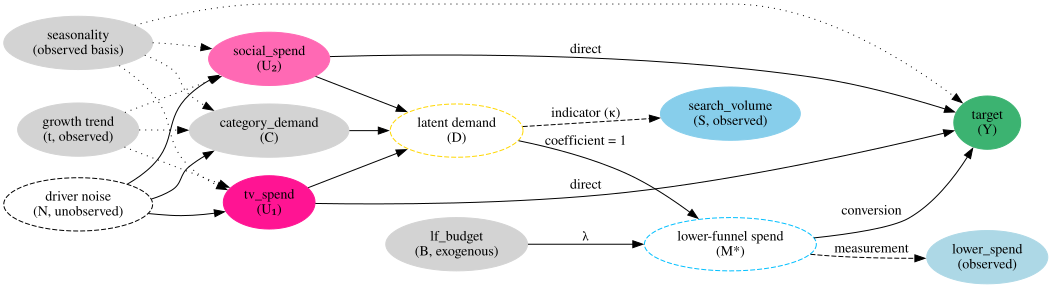

In [3]:
import graphviz as gr

# One edge list drives both this figure and the networkx analysis below, so
# the picture and the formal verdicts cannot drift apart.
DAG_NODES = {
    "season": (
        "seasonality\n(observed basis)",
        {"color": "lightgray", "style": "filled"},
    ),
    "t": (
        "growth trend\n(t, observed)",
        {"color": "lightgray", "style": "filled"},
    ),
    "N": (
        "driver noise\n(N, unobserved)",
        {"color": "black", "style": "dashed"},
    ),
    "U1": ("tv_spend\n(U₁)", {"color": "deeppink", "style": "filled"}),
    "U2": ("social_spend\n(U₂)", {"color": "hotpink", "style": "filled"}),
    "C": ("category_demand\n(C)", {"color": "lightgray", "style": "filled"}),
    "B": ("lf_budget\n(B, exogenous)", {"color": "lightgray", "style": "filled"}),
    "D": ("latent demand\n(D)", {"color": "gold", "style": "dashed"}),
    "MS": ("lower-funnel spend\n(M*)", {"color": "deepskyblue", "style": "dashed"}),
    "M": ("lower_spend\n(observed)", {"color": "lightblue", "style": "filled"}),
    "S": ("search_volume\n(S, observed)", {"color": "skyblue", "style": "filled"}),
    "Y": ("target\n(Y)", {"color": "mediumseagreen", "style": "filled"}),
}
DAG_EDGES = [
    ("season", "U1", {"style": "dotted"}),
    ("season", "U2", {"style": "dotted"}),
    ("season", "C", {"style": "dotted"}),
    ("season", "Y", {"style": "dotted"}),
    ("t", "U1", {"style": "dotted"}),
    ("t", "U2", {"style": "dotted"}),
    ("t", "C", {"style": "dotted"}),
    ("N", "U1", {}),
    ("N", "U2", {}),
    ("N", "C", {}),
    ("U1", "Y", {"label": "direct"}),
    ("U2", "Y", {"label": "direct"}),
    ("U1", "D", {}),
    ("U2", "D", {}),
    ("C", "D", {}),
    ("D", "MS", {"label": "coefficient = 1"}),
    ("B", "MS", {"label": "λ"}),
    ("MS", "M", {"label": "measurement", "style": "dashed"}),
    ("D", "S", {"label": "indicator (κ)", "style": "dashed"}),
    ("MS", "Y", {"label": "conversion"}),
]

g = gr.Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="ellipse")
for node, (label, attrs) in DAG_NODES.items():
    g.node(node, label, **attrs)
for parent, child, attrs in DAG_EDGES:
    g.edge(parent, child, **attrs)

g

```{tip}
**How to read the figure.** *Filled* nodes are observed: they appear in a dataset. A *dashed outline* marks the three quantities no dataset contains ($D$, $M^{*}$ and $N$). *Dotted* arrows are deterministic calendar components, *dashed* arrows are measurement or indicator links rather than causal ones, and *solid* arrows are ordinary structural edges.
```


The nodes, from media to target. Within every geo $g$ and week $t$:

- `tv_spend`, `social_spend` ($U_{t,g,c}$): two **upper-funnel** channels.
- `category_demand` ($C_{t,g}$): an exogenous, seasonal index of how much the whole category is in-market (think a category-level search-trend index). It drives lower-funnel demand but does **not** act on the target directly: an **exclusion restriction** on the mediator equation.
- `lf_budget` ($B_{t,g}$): an exogenous lower-funnel budget: always-on spend plus promotional pushes, set by the search team on its own calendar rather than in response to demand.
- $D_{t,g}$: **latent demand**. Never observed.
- $M^{*}_{t,g}$: **structural lower-funnel spend**, the quantity that actually buys conversions. `lower_spend` is this observed with reporting noise.
- `search_volume` ($S_{t,g}$): branded search volume, an **indicator** of $D$.
- `y` ($Y_{t,g}$): the target.


The arrows in the figure are these four equations. Upper-funnel activity and the category cycle create demand:

$$
D_{t,g} = \text{baseline}_g + \gamma_g\, C_{t,g}
          + \sum_{c} \text{sat}^{uf}\!\left(\text{adstock}^{uf}(U_{t,g,c})\right).
$$

That demand is one of two things the search team's spend responds to; the other is its own budget. Both parts are real money and both convert:

$$
M^{*}_{t,g} = D_{t,g} + \lambda_g B_{t,g},
\qquad
\texttt{lower\_spend}_{t,g} \sim
  \text{TruncatedNormal}(M^{*}_{t,g},\, \sigma^M_g,\, \text{lower}=0).
$$

Branded search, by contrast, buys nothing. It is a **pure indicator**; people search for the brand *because* they are in-market:

$$
S_{t,g} \sim \text{Normal}(\kappa\, D_{t,g},\, \sigma^S_g).
$$

Finally the target responds to lower-funnel spend, plus the direct effect of each upper channel and its own seasonality:

$$
Y_{t,g} = \text{intercept}_g
        + \sum_c \text{sat}\!\left(\text{adstock}(U_{t,g,c})\right)
        + \text{Fourier}(t)\cdot\gamma^{F}_g
        + \text{sat}^{lf}\!\left(\text{adstock}^{lf}(M^{*}_{t,g})\right)
        + \varepsilon_{t,g}.
$$

Every upper channel therefore reaches the target along **two paths**: directly, and indirectly along $U \to D \to M^{*} \to Y$.


Two details of the drawing carry real modeling weight.

**$M^{*}$ and `lower_spend` are two nodes on purpose.** What a dataset carries is the filled node, at the other end of the dashed measurement edge. The gap between the structural quantity and its noisy observation is what makes `Naive A` an approximate rather than an exact direct-effect estimator below.

**The market driver appears three times, and only two of the three are observed.** `seasonality` is the annual cycle, a deterministic function of the calendar that every model below matches with a Fourier basis. `t` is the common **growth trend** in the plans and the category index: equally deterministic, equally observable, but outside the span of an annual basis, so the shared Fourier term cannot stand in for it. `N` is the drivers' shared **noise**, the one strand that is genuinely unobserved: small, but not zero, and measured explicitly once the covariates are drawn.

Splitting the driver up is not cosmetic. The three strands have completely different statuses in the models below: the season is conditioned on by *every* specification by construction, the trend is carried only by the models that add a control for it on purpose, and $N$ can never be conditioned on by anything. Conflating them under a single "seasonality" bubble is precisely how the confounding in `Naive B` stays invisible. And, as the d-separation table will show, dropping $N$ from the picture is how a specification gets certified that should only have been certified *conditionally*. A confounder does not have to be unobservable to bite; it only has to be missing from the regression.

```{note}
$N$ is not a device invented for the picture. The covariate simulation below gives the two media plans and the category index a *shared* error term (`pm.LKJCholeskyCov`), which is equivalent, for d-separation purposes, to an unobserved common cause of all three. (A single latent is a rank-one stand-in for a general $3 \times 3$ correlation; splitting $N$ into three pairwise causes changes none of the verdicts below.) The correlation is small (we measure it once the covariates exist), but drawing it changes the d-separation verdicts, so it belongs on the graph.
```


### Why only one of the two downstream variables points at the target

This asymmetry is the heart of the example, so it is worth stating bluntly.

**Lower-funnel spend belongs in the target equation.** It is paid media. Money goes in, conversions come out, and a model that leaves it out is missing a real driver. What makes it a *mediator* rather than an ordinary channel is that its level is not chosen freely: part of it is a response to demand that upper-funnel activity created. Credit for that part belongs upstream.

**Branded search volume does not.** Nobody buys search volume; it is a symptom of being in-market. Drawing $S \to Y$ would invent a causal channel that does not exist, and, as `Naive C` below demonstrates, putting it into an MMM as if it were a channel silently blocks the very path we are trying to measure.

```{important}
The practical test is not "is this variable predictive of sales?" Both are, very. It is **"if I doubled it, would sales move?"** That question separates a spend line from a tracking metric, and no amount of model fit will answer it for you.
```

```{note}
**What anchors the latent scale.** $D$ is latent, so something has to fix its units. Here it is the coefficient on $D$ in the $M^{*}$ equation, which is pinned at exactly one: latent demand is measured *in units of the lower-funnel spend it induces*. Everything else is then relative to that: $\kappa$ is free, and $\lambda$ converts budget into the same units. Were that coefficient free too, rescaling $D$ and compensating in $\kappa$ would leave the likelihood untouched.
```

Two further structural features make this harder than the single-channel case.

**Confounded media plans.** Media plans and category demand are built around the same market rhythm, so upper-funnel spend and category demand move together. That common cause has three strands, with very different statuses relative to the models below:

- The purely **seasonal** strand is a deterministic function of the calendar, and every model below includes the matching Fourier basis, so that strand of the confounding is adjusted for by construction, however large it looks in a correlation table.
- The TV plan and the category index also share a strong common **growth trend**: observable from the calendar just as the season is, yet outside the span of a smooth annual basis, so a Fourier term cannot absorb it. Only the models that *deliberately* control for it (below, `Naive B+` through the category index and `Naive B++` through the trend itself) touch that strand.
- The third strand is the drivers' shared **noise**, which no regressor spans and no control column can reach. It is small here, but small is a measurement, not an assumption, and the d-separation verdicts turn out to depend on it.

We will measure how much confounding each strand is actually worth before fitting anything, and then watch the models separate what adjustment can repair from what it cannot: the trend-driven part of category demand is removable by adjustment, while the demand each channel creates downstream is not. Which curve collects what is decided by the likelihood's fit, not by anything a correlation table can tell you in advance.

**A shared, saturating demand pool.** Because both channels push on the *same* saturating function, their indirect effects are not additive. Turning off TV alone and turning off social alone remove *less* demand between them than turning off both at once: each channel is partly shielded by the other's contribution sitting further along the concave curve. We quantify this below.

Identification rests on **two exclusion restrictions** (two arrows deliberately missing from the graph), and they are not equally load-bearing:

- The lower-funnel budget $B$ enters the spend equation but not the search equation. This one is **genuinely identifying**: it is what lets the model tell $\lambda B$ apart from $D$ rather than lumping the two into one unidentified level. Nothing else in the model can substitute for it.
- Category demand $C$ enters the demand equation but not the target. This one is a **modelling convenience** rather than a necessity: $C$ is *observed*, so a direct $C \to Y$ path could simply be absorbed by adding $C$ as a control column. Keeping the target equation clean makes the example sharper, but no identification would be lost by relaxing it, a fact `Naive B+` below exploits.


The whole graph is replicated across geos. Which parameters are shared and which are free per geo is a modeling choice, and with roughly 130 weeks per geo it is a consequential one:

| Parameter | Dimensions | Why |
|---|---|---|
| `adstock_alpha`, `adstock_hub_input_alpha`, `saturation_lam`, `sat_hub_input_lam` | `("channel",)` | Carryover and curvature are properties of the medium, not the region; pooling them buys a lot of precision. |
| `saturation_beta`, `sat_hub_input_beta` | `("geo", "channel")` | Response *amplitude* genuinely differs by region (market size, competition). |
| `intercept`, `budget_dual_baseline`, `budget_dual_parent_coef`, `budget_dual_budget_coef`, the noise scales | `("geo",)` | Regional levels and volatility; how strongly budget converts into spend is a regional operating choice. |
| `adstock_contribution_alpha`, `sat_contribution_beta` | `("geo",)` | The conversion path from lower-funnel spend to the target: how fast paid-search clicks convert and how hard they saturate is a property of each regional market. |
| `sat_contribution_lam` | scalar | There is only **one** mediator, so unlike `sat_hub_input_lam` there is no channel axis to vary over; with a single series per geo we pool the curvature and let the per-geo amplitude carry the regional differences. |
| `budget_dual_indicator_coef` | scalar | The search index is the same instrument everywhere, so its loading is shared. |

Mixing pooled and unpooled parameters in one expression is where xtensors earn their keep: `pymc.dims` aligns operands **by dimension name**, so a `("channel",)` decay multiplies a `("date", "geo", "channel")` media array with no manual broadcasting.


## Model structures we will study

The comparisons below are organised around six model structures, so let us define them before any code runs. Every one is a geo-level MMM with the same adstock/saturation families, the same priors, the same Fourier seasonal basis, and the same sampler settings. The two upper-funnel channels are always present. The models differ in exactly one thing: **what else they condition on, and how.**

| Model | Beyond the two upper channels | How it treats the funnel | Question it can answer |
|---|---|---|---|
| `Naive A (mediator as channel)` | adds `lower_spend` as a third **channel** | conditions on the mediator, which blocks the indirect path | approximately the **direct** effect of the upper channels |
| `Naive B (mediator omitted)` | nothing | ignores the mediator entirely | targets the **total** effect, but a backdoor through the shared market driver stays open |
| `Naive B+ (demand as control)` | adds `category_demand` as a **control column** | still ignores the mediator, but blocks that backdoor through the observed demand index | the **total** effect: formally valid |
| `Naive B++ (trend as control)` | adds the growth trend `t` as a **control column** | blocks only the trend strand of the backdoor; the drivers' shared noise stays open | the **total** effect: valid only conditionally |
| `Naive C (indicator as channel)` | adds `search_volume` as a third **channel** | conditions on a *symptom* of demand, partially blocking the indirect path | neither effect cleanly |
| `Funnel` | the `BudgetDualIndicatorEffect`: `lower_spend` and `search_volume` as extra likelihoods, `category_demand` and `lf_budget` as inputs | models the mediation explicitly | **direct, indirect and total**, separately |

These are the labels every table and figure below prints, verbatim, and the prose uses the full form whenever a model is (re)introduced, so a name never has to be held in memory across sections. The short forms `Naive A`, `Naive B`, `Naive B+`, `Naive B++` and `Naive C` are used only as shorthand inside a discussion that has already named the model in full. The d-separation section below *computes* the causal verdicts sketched in the last column, and the fitting section then tests them against the known ground truth.


## Prepare Notebook

In [4]:
import itertools

import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import xarray as xr
from pydantic import InstanceOf
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect, IncrementalitySpec
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

/Users/benjamv/.cache/uv/archive-v0/vH0Axw9o92ktIii3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
seed: int = sum(map(ord, "geo funnel model"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## Configuration

In [6]:
n_dates = 130
l_max = 8
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]

date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)
coords = {"date": date_range, "geo": geos}

## The `BudgetDualIndicatorEffect` component

A {class}`~pymc_marketing.mmm.additive_effect.MuEffect` adds an arbitrary term to the target mean through a three-method protocol: `create_data` registers the data the effect needs, `create_effect` builds and returns the term, and `set_data` refreshes the data at prediction time. Because `create_effect` runs *inside* the model context, it can declare **its own observed likelihoods**, which is what turns "add a term to `mu`" into "fit extra structural equations jointly".

{class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect` removes most of that boilerplate, and both this notebook and {ref}`mmm_funnel_mueffect` build on it: it takes a list of `data_vars` naming variables in the training dataset and implements `create_data` and `set_data` for us, registering each one with the dimensions it already carries in the dataset, which is also what makes the effect work out of sample.

What is new here is one level up. The `MediaTransformation` helper does for the adstock/saturation pairs what `DataVarMuEffect` does for the data: where the basic notebook's effect carries four loose transforms (`hub_adstock`, `hub_saturation`, `contribution_adstock`, `contribution_saturation` in {ref}`mmm_funnel_mueffect`), this one holds **two** transformation objects: each pair ordered by a single `adstock_first` flag, with every component's priors carrying their own dimensions, which matters more here, because every prior in the geo panel needs dimensions attached to it.

One more method matters for the ROAS section later. Because the effect reads `mmm.channel_data_scaled`, a spend counterfactual reaches the target *through* it as well as through `channel_contribution`; returning an {class}`~pymc_marketing.mmm.additive_effect.IncrementalitySpec` from `incrementality_spec` declares exactly that, and without it the incrementality module refuses to run rather than quietly report the direct path as if it were the total. Where {ref}`mmm_funnel_mueffect` returns the empty spec and lets the mediator's extra reach be *measured* off the fitted graph, here we *declare* it: the mediator chains a second adstock behind the model's own, its `l_max` is exactly how much further a spend change can travel, and the yearly evaluation windows below are sized by that declaration.

What remains in `create_effect` is exactly the part that *is* the funnel:

```{note}
The intro notebook's `MeasuredMediatorEffect` and this notebook's `BudgetDualIndicatorEffect` share no class name because they implement **different DAGs** (one measurement on the hub vs budget-linked spend plus two indicators). Class names describe topology; "funnel" describes the use case.
```


In [7]:
class BudgetDualIndicatorEffect(DataVarMuEffect):
    """Unobserved mediator (D), budget-linked structural spend, two indicators, mediated mu contribution."""

    hub_input_transform: InstanceOf[MediaTransformation]
    contribution_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize effect configuration."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "hub_input_transform": self.hub_input_transform.to_dict(),
            "contribution_transform": self.contribution_transform.to_dict(),
        }

    def incrementality_spec(self) -> IncrementalitySpec:
        """Opt in to incrementality, declaring the second adstock's reach.

        A spend counterfactual moves this contribution because it reads
        ``mmm.channel_data_scaled``; opting in tells the incrementality module
        to include that movement in the increment. The mediator chains a
        second adstock behind the model's own, so a change in spend can still
        move this contribution up to ``contribution_transform.adstock.l_max`` weeks
        beyond the base ``l_max``; declaring it sizes the evaluation windows
        for the yearly breakdown below.
        """
        return IncrementalitySpec(
            additional_carryover_lags=self.contribution_transform.adstock.l_max
        )

    def create_effect(self, mmm):
        """Build the budget-linked dual-indicator subgraph from the geo funnel DAG."""
        model = mmm.model
        parents_into_hub = self.hub_input_transform(
            mmm.channel_data_scaled, dim="date"
        ).sum(dim="channel")
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        parent_coef = pmd.HalfNormal(
            f"{self.prefix}_parent_coef", sigma=1.0, dims=("geo",)
        )
        hub = pmd.Deterministic(
            f"{self.prefix}_hub",
            baseline + parent_coef * model["category_demand"] + parents_into_hub,
        )
        budget_coef = pmd.HalfNormal(
            f"{self.prefix}_budget_coef", sigma=0.5, dims=("geo",)
        )
        spend = pmd.Deterministic(
            f"{self.prefix}_spend",
            hub + budget_coef * model["lf_budget"],
        )
        pmd.TruncatedNormal(
            f"{self.prefix}_spend_measurement",
            mu=spend,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_spend_measurement_sigma", sigma=1.0, dims=("geo",)
            ),
            lower=0.0,
            observed=model["lower_spend"],
        )
        indicator_coef = pmd.HalfNormal(f"{self.prefix}_indicator_coef", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_hub_indicator",
            mu=indicator_coef * hub,
            sigma=pmd.HalfNormal(
                f"{self.prefix}_hub_indicator_sigma", sigma=1.0, dims=("geo",)
            ),
            observed=model["search_volume"],
        )
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.contribution_transform(spend, dim="date"),
        )

The factory below wires up the two transformations and, crucially, sets the **dimensions of each prior** according to the pooling table above. `GeometricAdstock` and `LogisticSaturation` accept a `priors` dictionary, so `alpha` and `lam` get `dims="channel"` (pooled across geos) while `beta` gets `dims=("geo", "channel")`. Unique `prefix` values keep these parameters from colliding with the base `MMM`'s own direct-path transforms.

In [8]:
def make_budget_dual_indicator_effect() -> BudgetDualIndicatorEffect:
    """Construct the budget-dual-indicator effect with uniquely-prefixed transformations."""
    return BudgetDualIndicatorEffect(
        data_vars=["lower_spend", "search_volume", "category_demand", "lf_budget"],
        prefix="budget_dual",
        hub_input_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_hub_input",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_hub_input",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims="channel"),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
                },
            ),
            adstock_first=True,
            dims=("geo", "channel"),
        ),
        contribution_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_contribution",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="geo")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_contribution",
                priors={
                    "lam": Prior("Gamma", mu=1.5, sigma=0.5),
                    "beta": Prior("HalfNormal", sigma=1.0, dims="geo"),
                },
            ),
            adstock_first=True,
            dims=("geo",),
        ),
    )

### A note on data plumbing

`DataVarMuEffect` looks its variables up in `mmm.xarray_dataset`, the dataset the `MMM` stores when the model is built. That has a practical consequence worth stating plainly, because it is easy to trip over:

> **A `pandas.DataFrame` will silently drop your funnel columns.** When `X` is a DataFrame, the conversion keeps only the channel and control columns; anything else disappears. To make extra variables visible to the effect, build the model from an `xarray.Dataset`, where every data variable survives.

There is a second wrinkle. `MMM.fit` records a `fit_data` group by converting `X` back to a flat frame indexed on `(date, *dims)`, and that step cannot handle a `Dataset` with any data variable whose dimensions go beyond the model's `dims`: here the media variable's `channel` dimension, which makes the index non-unique. (A `Dataset` of purely `(date, geo)` variables would convert.) So we **build** with the `Dataset` (which is what populates the model) and **fit** with the equivalent long DataFrame (which is only used for bookkeeping, since `fit` does not rebuild an already-built model). The model itself is entirely determined by the `Dataset`. One consequence to know: because `fit_data` is recorded from the long frame, it does not carry the funnel columns, so a `save` / `build_from_idata` round-trip would not reconstruct this model.


## Data generating process

As in {ref}`mmm_data_generator`, we build a model, clamp every parameter to a known value with the [`do`](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model.transform.conditioning.do.html) operator, and forward-sample. The generative model **is** the funnel MMM, so one forward pass produces the target and both demand proxies at once.


### Exogenous covariates

Three of the drivers (two media plans and the category demand index) share a common annual seasonal component, and two of them share a strong growth trend. The **amplitudes and trends encode the story**: the TV plan is built around the category cycle (amplitude 0.80, against category demand's 0.70) *and* rides the same growth trend the category does (1.20, against the category's 1.00), a growth-stage category whose flagship channel scales up with it. Social runs a much milder cycle (0.40) and is nearly flat in trend (0.15): it co-moves with category demand on the seasonal axis only. So the two channels are confounded with demand through *different* strands of the shared driver, by construction rather than by the luck of a draw.

The noise around those shared means is drawn from an LKJ prior with `eta=50` and scales concentrated around 0.3. The concentration keeps the noise close to *independent* across drivers, which is what pins the **raw** plan/demand correlations to the deterministic means rather than to the draw. It pins the *residual* correlations much more weakly: at `eta=50` and $d = 3$ the LKJ marginal correlation sd is $1/\sqrt{2\eta + 2} \approx 0.10$, so a residual correlation of that order is a lottery across seeds. What is robust is the **ranking** rather than the level: TV's residual is carried by a trend loading of 1.20 against social's 0.15, and those are set in the configuration above rather than drawn, which is all the causal argument below needs. We measure the realized draw regardless, because two paragraphs of that argument turn on how big the noise strand is. A `softplus` keeps everything non-negative. Regions are then scaled by a size multiplier.


In [9]:
t = np.arange(n_dates) / n_dates
week_of_year = date_range.isocalendar().week.to_numpy() / 52.0
season = np.sin(2 * np.pi * week_of_year)

drivers = ["tv_spend", "social_spend", "category_demand"]
geo_size = np.array([1.0, 0.7, 0.45])

level = np.array([0.10, 0.05, 0.30])
trend = np.array([1.20, 0.15, 1.00])
seasonal_amplitude = np.array([0.80, 0.40, 0.70])

cov_coords = {"date": date_range, "geo": geos, "driver": drivers}
with pm.Model(coords=cov_coords) as covariates_model:
    L, _, _ = pm.LKJCholeskyCov(
        "L", n=3, eta=50, sd_dist=pm.Gamma.dist(mu=0.30, sigma=0.05)
    )
    mu_cov = (
        level + trend * t[:, None, None] + seasonal_amplitude * season[:, None, None]
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "geo", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "geo", "driver"))

In [10]:
x_data = pm.draw(covariates_model.x, draws=1, random_seed=rng) * geo_size[None, :, None]

media_raw = x_data[..., :2]
category_demand = x_data[..., 2] / x_data[..., 2].max()

The lower-funnel budget is generated differently on purpose. It is **not** seasonal and it does not follow the media plans: a low always-on level with occasional promotional pushes on the search team's own calendar. That shape is what makes it useful: the pushes are exogenous shocks to lower-funnel spend, and they are what let the model separate the budget-driven part of that spend from the demand-driven part.

In [11]:
promo = rng.binomial(n=1, p=0.35, size=(n_dates, len(geos)))
magnitude = rng.gamma(shape=2.0, scale=0.30, size=(n_dates, len(geos)))
lf_budget = geo_size[None, :] * (0.12 + promo * magnitude)

budget_stats = pd.DataFrame(
    {
        "mean": lf_budget.mean(axis=0),
        "sd": lf_budget.std(axis=0),
        "sd/mean": lf_budget.std(axis=0) / lf_budget.mean(axis=0),
    },
    index=pd.Index(geos, name="geo"),
)
budget_stats.style.format({"mean": "{:.3f}", "sd": "{:.3f}", "sd/mean": "{:.2f}"})

,mean,sd,sd/mean
geo,,,
north,0.329,0.350,1.07
south,0.249,0.283,1.14
west,0.133,0.138,1.04


The variation matters: a budget that sat flat at its always-on level would carry no information, and $\lambda$ would be absorbed into the demand baseline. Here the standard deviation runs 4% to 14% above the mean.

The other thing to check is that the budget really is exogenous. A promotional calendar that happened to follow the category cycle would be a second confounder rather than a source of clean variation:


In [12]:
driver_names = ["tv_spend", "social_spend", "category_demand", "lf_budget"]
corr_frames = {}
for gi, geo in enumerate(geos):
    stacked = np.column_stack(
        [
            media_raw[:, gi, 0],
            media_raw[:, gi, 1],
            category_demand[:, gi],
            lf_budget[:, gi],
        ]
    )
    corr_frames[geo] = pd.DataFrame(
        np.corrcoef(stacked, rowvar=False), index=driver_names, columns=driver_names
    )

corr_table = pd.concat(corr_frames, names=["geo", "driver"])
max_budget_corr = (
    corr_table["lf_budget"].drop(index="lf_budget", level="driver").abs().max()
)
corr_table.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format(
    "{:+.2f}"
).set_caption(
    f"Raw driver correlations; max |corr| involving lf_budget: {max_budget_corr:.3f}"
)

`lf_budget` is essentially uncorrelated with everything else (every pairing below 0.14), while **TV tracks category demand far more closely than social does** (0.83-0.86 against 0.41-0.53), exactly as the amplitudes and trends were configured. A natural guess is that whatever bias the naive models incur will land on TV, the channel that moves with demand. Hold that thought: the result is more instructive than the guess. But a raw correlation conflates the two strands of the shared driver: the seasonal strand, which every model below adjusts for by construction, and the trend strand, which only two of them will. The next table takes the raw numbers apart.

### How much of that co-movement can the models already absorb?

The raw correlations above conflate two very different strands of the confounding. The **seasonal** strand is a deterministic function of the calendar, and every model below carries the matching Fourier basis: whatever part of the co-movement lives in that subspace is adjusted for by construction, however large it looks in the raw table. The **trend** strand is just as observable but lies outside the span of an annual basis, and only the models that deliberately control for it touch it.

Partialling makes the split quantitative. The residual correlation after projecting out the Fourier basis is the co-movement the seasonal adjustment *cannot* absorb (the part with the power to bias the models below), and the residual after also projecting out $t$ is what would remain for a model that carries a trend control:


In [13]:
doy_frac = date_range.dayofyear.to_numpy() / 365.25
fourier_basis = np.column_stack(
    [f(2 * np.pi * k * doy_frac) for k in (1, 2) for f in (np.sin, np.cos)]
)


def partial_out(v: np.ndarray, controls: np.ndarray) -> np.ndarray:
    """Residual of ``v`` after an OLS projection on ``[1, controls]``."""
    design = np.column_stack([np.ones(len(v)), controls])
    return v - design @ np.linalg.lstsq(design, v, rcond=None)[0]


# The drivers' cycle and the models' basis are different functions of the
# calendar (isoweek/52 against dayofyear/365.25), so their overlap is a
# measurement, not an identity.
season_residual = partial_out(season, fourier_basis)
season_r2 = 1 - season_residual.var() / season.var()

residual_rows = []
for gi, geo in enumerate(geos):
    demand_g = category_demand[:, gi]
    for ci, ch in enumerate(channels):
        spend_g = media_raw[:, gi, ci]
        basis_t = np.column_stack([fourier_basis, t])
        residual_rows.append(
            {
                "geo": geo,
                "channel": ch,
                "raw": np.corrcoef(spend_g, demand_g)[0, 1],
                "after Fourier basis": np.corrcoef(
                    partial_out(spend_g, fourier_basis),
                    partial_out(demand_g, fourier_basis),
                )[0, 1],
                "after Fourier basis + t": np.corrcoef(
                    partial_out(spend_g, basis_t), partial_out(demand_g, basis_t)
                )[0, 1],
            }
        )

residual_corr = pd.DataFrame(residual_rows).set_index(["geo", "channel"])
residual_corr.style.format("{:+.3f}").set_caption(
    "Plan/demand correlations after partialling; "
    f"R² of the drivers' seasonal cycle on the model's Fourier basis: {season_r2:.4f}"
)

The split could hardly be cleaner. **TV's co-movement with category demand survives the seasonal projection** (+0.63 to +0.67): the TV plan rides the same growth trend as the category, and no annual basis can absorb a trend. **Social's residual co-movement is already at noise level** (|r| at or below 0.12): its raw correlation with demand was almost entirely seasonal, and the seasonal adjustment eats it. Adding $t$ to the projection removes what remains of TV's (to |r| at or below 0.05): the surviving confounding is trend-shaped, and in this linear diagnostic a trend control is enough to close it.

Social's column moves as well, from -0.05/+0.12/+0.05 to -0.21/-0.03/-0.12, and it is tempting to read that as a trend control over-correcting a channel that did not need one. It is not. Those negative residuals are already in the draw, as the next cell measures directly; all this column says about social is that its co-movement with demand is small in every projection.

Keep both halves in hand for the model comparison. Both channels do have a backdoor through the shared trend ($t \to U_2$ is in the DGP with a loading of 0.15, and the d-separation table below will say so for social exactly as plainly as for TV), but only TV's is **numerically material** (+0.63 to +0.67 against $|r| \le 0.12$). So when a naive model's social estimate goes badly wrong below, confounding will not be the reason. D-separation is binary and this measurement is not, and that gap is where the rest of the notebook lives.

```{note}
The `season` node in the DAG stands for two near-collinear functions rather than one variable: the drivers cycle on $\sin(2\pi \cdot \text{isoweek}/52)$ while every model carries a two-mode Fourier basis in `dayofyear/365.25`. The $R^2$ in the table caption above is what makes "adjusted for by construction" true in practice: comfortably, but by measurement rather than by definition.
```


### One more strand: the drivers' own correlated noise

The residual columns above are not purely structural. The three drivers share a covariance matrix, not just a mean: `pm.LKJCholeskyCov` gives them a **common error component**, and whatever correlation that draw happens to have survives *every* projection, because it lives in the span of no regressor at all. In graph terms that component is a latent common cause of the two plans and the category index (it enters the DAG above as $N$), so its size is worth knowing rather than assuming. Since `softplus` is invertible, the noise that produced the drawn series is exactly recoverable, which makes this a measurement:


In [14]:
# softplus is invertible, so the noise behind the drawn drivers is exactly
# recoverable.
driver_noise = np.log(np.expm1(x_data / geo_size[None, :, None])) - mu_cov

noise_rows = [
    {
        "geo": geo,
        "tv/category": np.corrcoef(driver_noise[:, gi, 0], driver_noise[:, gi, 2])[
            0, 1
        ],
        "social/category": np.corrcoef(driver_noise[:, gi, 1], driver_noise[:, gi, 2])[
            0, 1
        ],
        "tv/social": np.corrcoef(driver_noise[:, gi, 0], driver_noise[:, gi, 1])[0, 1],
    }
    for gi, geo in enumerate(geos)
]

# One LKJ draw is shared by all three geos, so pooling the residuals estimates the
# draw's own correlation; the per-geo rows are what the residual table above sees.
pooled_noise = np.concatenate([driver_noise[:, gi, :] for gi in range(len(geos))])
pooled_corr = np.corrcoef(pooled_noise, rowvar=False)
noise_rows.append(
    {
        "geo": "pooled",
        "tv/category": pooled_corr[0, 2],
        "social/category": pooled_corr[1, 2],
        "tv/social": pooled_corr[0, 1],
    }
)
pd.DataFrame(noise_rows).set_index("geo").style.format("{:+.3f}")

,tv/category,social/category,tv/social
geo,,,
north,+0.025,-0.180,-0.130
south,-0.036,-0.070,-0.091
west,+0.009,-0.136,-0.075
pooled,+0.007,-0.126,-0.095


The floor for reading these numbers has two parts: the prior's own scatter (the marginal correlation sd of an LKJ($\eta$) prior on a $d \times d$ matrix is $1/\sqrt{2\eta + d - 1}$, which collapses to $1/\sqrt{2\eta + 2}$ only because $d = 3$ here) and the sampling error of a correlation measured on 130 weeks, about $1/\sqrt{n - 1}$ near zero. The two add in quadrature; the pooled row is measured on three times the data, so its sampling component, and with it its floor, is smaller.

Read each row against its own floor, and read the three per-geo rows as one draw seen three times rather than as three independent draws: they share the single correlation matrix drawn above, which is why the pooled row is the summary the argument leans on.


In [15]:
prior_corr_sd = 1 / np.sqrt(2 * 50 + len(drivers) - 1)
sampling_se = 1 / np.sqrt(n_dates - 1)
pooled_se = 1 / np.sqrt(n_dates * len(geos) - 1)

pd.DataFrame(
    {
        "per-geo row": [
            prior_corr_sd,
            sampling_se,
            np.hypot(prior_corr_sd, sampling_se),
        ],
        "pooled row": [prior_corr_sd, pooled_se, np.hypot(prior_corr_sd, pooled_se)],
    },
    index=["LKJ prior correlation sd (eta=50, d=3)", "sampling se", "combined floor"],
).style.format("{:.3f}")

,per-geo row,pooled row
"LKJ prior correlation sd (eta=50, d=3)",0.099,0.099
sampling se,0.088,0.051
combined floor,0.132,0.111


Two readings, and the notebook uses both.

**The noise correlation is small but not zero, and nothing observed spans it.** This is the one strand of the shared driver that no control column can reach, which is why the DAG above carries an unobserved $N$ pointing at all three drivers, and why one of the two "valid" adjustment sets below turns out to be valid only under an assumption about *this* number.

**It also explains the sign of social's residual column.** Social's noise correlation with category demand is -0.18/-0.07/-0.14 by geo: the same signs and roughly the same magnitudes as social's post-Fourier-plus-$t$ residuals (-0.21/-0.03/-0.12). Once the deterministic means are projected out, what remains *is* the draw's noise, so those negatives are a property of this draw and not something the conditioning set did to social.

The printed floors set the scale for reading any of it, but a floor built from prior scatter plus sampling error answers one question, and the table quietly asks two.

- *Is the number real in this dataset?* That is measurement error alone: conditional on the draw, a per-geo row carries a sampling se of about 0.09 on 130 weeks and the pooled row about 0.05 on 390, so pooled social's -0.13 sits about two and a half standard errors from zero: a precisely measured, genuinely nonzero latent strand in the one dataset every model below is fit to.
- *Would another seed reproduce it?* For that question the prior's scatter (about 0.10) joins in (it is not measurement error but the size of correlation the prior hands out), giving the combined floors of 0.13 and 0.11. A number sitting at 1.1 times its floor could land anywhere in that range on a redraw, sign included.

The notebook uses each reading where it belongs: the model comparison below treats -0.13 as real *here* (and pointing the wrong way to explain anything social does), while `Naive B++`'s validity assumption is sized against the predictive floor, because that verdict is one a reader carries to data with a different draw. Nothing in this table clears both bars as decisively as TV's +0.63 to +0.67 residual co-movement does.


### Ground-truth parameters

Every structural parameter gets an explicit true value, with the shape implied by its dimensions. Rather than trusting our memory of which parameter is pooled, we build the model first and read the dimensions off it.


In [16]:
true = {
    # target equation: direct paths and seasonality
    "intercept_contribution": np.array([0.35, 0.28, 0.22]),
    "adstock_alpha": np.array([0.55, 0.30]),
    "saturation_lam": np.array([3.0, 4.0]),
    "saturation_beta": np.array([[0.55, 0.35], [0.45, 0.30], [0.35, 0.25]]),
    "gamma_fourier": np.array(
        [
            [0.05, 0.03, 0.02, -0.02],
            [0.04, 0.02, 0.02, -0.01],
            [0.03, 0.02, 0.01, -0.01],
        ]
    ),
    "y_sigma": np.array([0.04, 0.04, 0.04]),
    # mediator equation: upper spend + category demand -> latent demand
    "budget_dual_baseline": np.array([0.20, 0.16, 0.12]),
    "budget_dual_parent_coef": np.array([0.35, 0.30, 0.25]),
    "adstock_hub_input_alpha": np.array([0.60, 0.35]),
    "sat_hub_input_lam": np.array([2.5, 3.0]),
    "sat_hub_input_beta": np.array([[0.85, 0.55], [0.70, 0.45], [0.55, 0.35]]),
    # lower-funnel spend equation and its observation
    "budget_dual_budget_coef": np.array([0.50, 0.45, 0.40]),
    "budget_dual_spend_measurement_sigma": np.array([0.05, 0.05, 0.05]),
    # branded-search indicator
    "budget_dual_indicator_coef": np.array(0.8),
    "budget_dual_hub_indicator_sigma": np.array([0.05, 0.05, 0.05]),
    # conversion path: lower-funnel spend -> target
    "adstock_contribution_alpha": np.array([0.35, 0.30, 0.25]),
    "sat_contribution_lam": np.array(1.5),
    "sat_contribution_beta": np.array([1.05, 0.90, 0.72]),
}

### Model configuration

The same priors are used for the generative model and for the models we fit, so we define them once. Note the `scaling` block: `dims=()` means "take the maximum over the date dimension only", giving one scale per geo (and per channel), which is the usual choice for a geo panel where regions differ in size.


In [17]:
SCALING = {
    "channel": {"method": "max", "dims": ()},
    "target": {"method": "max", "dims": ()},
}

MODEL_CONFIG = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.2, dims="geo"),
    "gamma_fourier": Prior("Normal", mu=0, sigma=0.1, dims=("geo", "fourier_mode")),
    "likelihood": Prior(
        "Normal",
        sigma=Prior("HalfNormal", sigma=0.5, dims="geo"),
        dims=("date", "geo"),
    ),
}


def make_mmm(channel_columns: list[str], **kwargs) -> MMM:
    """Build the base MMM shared by the generative and fitted models."""
    return MMM(
        date_column="date",
        target_column="y",
        channel_columns=channel_columns,
        dims=("geo",),
        scaling=SCALING,
        adstock=GeometricAdstock(
            l_max=l_max,
            priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
        ),
        saturation=LogisticSaturation(
            priors={
                "lam": Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
                "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
            }
        ),
        yearly_seasonality=2,
        model_config=MODEL_CONFIG,
        **kwargs,
    )


def make_dataset(media, lower_spend, search_volume, cat_demand, budget) -> xr.Dataset:
    """Assemble the xarray Dataset the funnel model is built from.

    The media variable must be named ``media`` (not ``channel``: with the explicit
    ``channel`` coordinate below, xarray rejects a data variable of the same name
    outright: ``ValueError``, found in both data_vars and coords) and carry a
    ``channel`` dimension. Every variable named
    in the effect's ``data_vars`` must appear here, or ``build_model`` raises xarray's own ``KeyError``
    ("No variable named ..."); plain indexing, no MMM-level validation.
    """
    return xr.Dataset(
        {
            "media": xr.DataArray(media, dims=("date", "geo", "channel")),
            "lower_spend": xr.DataArray(lower_spend, dims=("date", "geo")),
            "search_volume": xr.DataArray(search_volume, dims=("date", "geo")),
            "category_demand": xr.DataArray(cat_demand, dims=("date", "geo")),
            "lf_budget": xr.DataArray(budget, dims=("date", "geo")),
        },
        coords={**coords, "channel": channels},
    )

### Forward simulation

We build the generative model on dummy observations and a dummy target (all ones, so the target scale is one and the true parameters are on the natural scale), then clamp and sample.

```{warning}
`lower_spend` and `search_volume` are placeholders here: they are *outputs* of the forward pass. `lf_budget` is **not**: it is a genuine input to the mediator equation and must be the real series. Passing ones for it would leave $\lambda$ multiplying a constant, and the failure would be silent: sampling still succeeds, and $\lambda$'s posterior simply reverts to its prior.
```


In [18]:
ones = np.ones((n_dates, len(geos)))
ds_gen = make_dataset(media_raw, ones, ones, category_demand, lf_budget)
y_gen = xr.DataArray(ones, dims=("date", "geo"), coords=coords)

gen = make_mmm(channels)
gen.add_mu_effect(make_budget_dual_indicator_effect())
gen.build_model(X=ds_gen, y=y_gen)
gen.add_original_scale_contribution_variable(
    var=["channel_contribution", "budget_dual_effect_contribution", "y"]
)

pd.DataFrame(
    [(v, gen.model.named_vars_to_dims.get(v), true[v].shape) for v in true],
    columns=["parameter", "dims", "true value shape"],
)

,parameter,dims,true value shape
0,intercept_contribution,"(geo,)","(3,)"
1,adstock_alpha,"(channel,)","(2,)"
2,saturation_lam,"(channel,)","(2,)"
3,saturation_beta,"(geo, channel)","(3, 2)"
4,gamma_fourier,"(geo, fourier_mode)","(3, 4)"
5,y_sigma,"(geo,)","(3,)"
6,budget_dual_baseline,"(geo,)","(3,)"
7,budget_dual_parent_coef,"(geo,)","(3,)"
8,adstock_hub_input_alpha,"(channel,)","(2,)"
9,sat_hub_input_lam,"(channel,)","(2,)"


{meth}`~pymc_marketing.model_builder.ModelBuilder.table` complements that view with a summary table of the whole model, every variable with its dimensions and prior in one place:

In [19]:
gen.table()

                             Variable  Expression                             Dimensions                           
───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                      channel_scale =  Data                                   geo[3] × channel[2]                  
                       target_scale =  Data                                   geo[3]                               
                       channel_data =  Data                                   date[130] × geo[3] × channel[2]      
                        target_data =  Data                                   date[130] × geo[3]                   
                        lower_spend =  Data                                   date[130] × geo[3]                   
                      search_volume =  Data                                   date[130] × geo[3]                   
                    category_demand =  Data                                   date[130] × geo[3]                   
                          lf_budget =  Data                                   date[130] × geo[3]                   
                          dayofyear =  Data                                   date[130]                            
                                                                                                                   
             intercept_contribution ~  Normal(0.2, 0.2)                       geo[3]                               
                      adstock_alpha ~  Beta(2, 3)                             channel[2]                           
                     saturation_lam ~  Gamma(<constant>, <constant>)          channel[2]                           
                    saturation_beta ~  HalfNormal(0, 1)                       geo[3] × channel[2]                  
                      gamma_fourier ~  Normal(0, 0.1)                         geo[3] × fourier_mode[4]             
            adstock_hub_input_alpha ~  Beta(2, 3)                             channel[2]                           
                  sat_hub_input_lam ~  Gamma(<constant>, <constant>)          channel[2]                           
                 sat_hub_input_beta ~  HalfNormal(0, 1)                       geo[3] × channel[2]                  
               budget_dual_baseline ~  HalfNormal(0, 1)                       geo[3]                               
            budget_dual_parent_coef ~  HalfNormal(0, 1)                       geo[3]                               
            budget_dual_budget_coef ~  HalfNormal(0, 0.5)                     geo[3]                               
  budget_dual_spend_measurement_sigma  HalfNormal(0, 1)                       geo[3]                               
                                    ~                                                                              
         budget_dual_indicator_coef ~  HalfNormal(0, 1)                                                            
    budget_dual_hub_indicator_sigma ~  HalfNormal(0, 1)                       geo[3]                               
         adstock_contribution_alpha ~  Beta(2, 3)                             geo[3]                               
               sat_contribution_lam ~  Gamma(<constant>, <constant>)                                               
              sat_contribution_beta ~  HalfNormal(0, 1)                       geo[3]                               
                            y_sigma ~  HalfNormal(0, 0.5)                     geo[3]                               
                                                                              Parameter count = 61                 
                                                                                                                   
               channel_contribution =  f(saturation_beta, saturation_lam,     date[130] × geo[3] × channel[2]      
                                       adstock_alpha)   

Reading the dimensions off the model before writing the intervention is a habit worth keeping: `do` checks the clamped values against each variable's *static* type (dtype, rank, and any statically known length), and sizing a parameter purely with `dims` leaves its static length unknown. So a scalar for a `(geo,)` parameter raises, but a length-2 array for the three geos passes `do` silently, and the mistake surfaces only at the first predictive draw downstream, as a coordinate-length error two steps removed from the line that caused it. The pooling choices above mean those shapes are not all obvious, which is exactly when a late, displaced error is hardest to trace back.

The model graph makes the **three** likelihoods explicit: the target and the two demand proxies are all children of the same set of latent parameters.


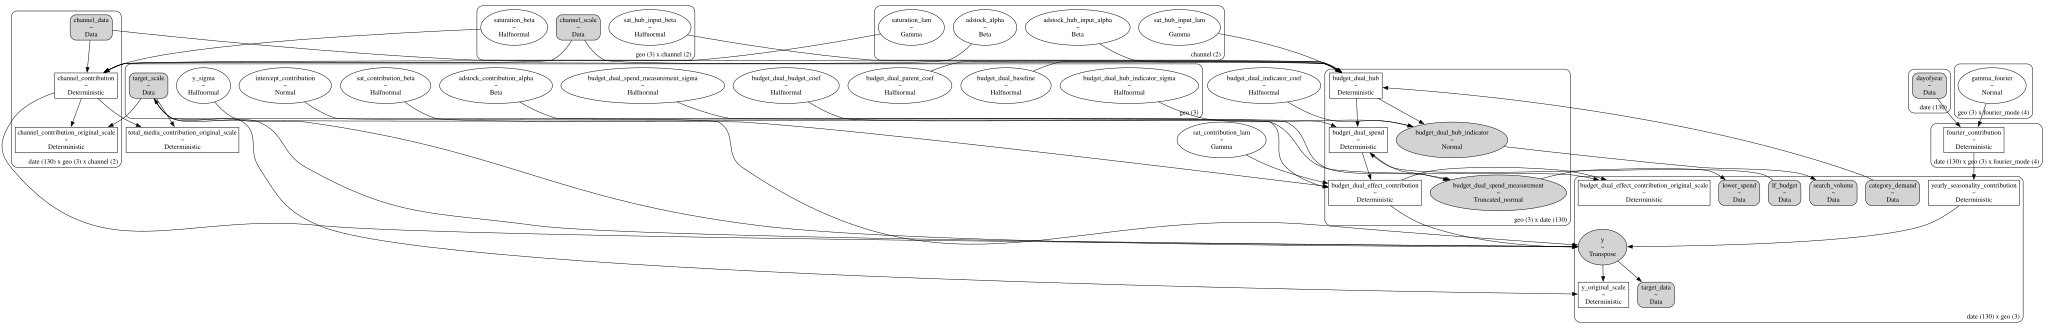

In [20]:
pm.model_to_graphviz(gen.model)

In [21]:
gen.model = do(gen.model, true)

var_names = [
    "y_original_scale",
    "channel_contribution_original_scale",
    "budget_dual_effect_contribution_original_scale",
    "budget_dual_hub",
    "budget_dual_spend",
]
pp_names = ["budget_dual_spend_measurement", "budget_dual_hub_indicator"]

with gen.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1, var_names=var_names + pp_names, random_seed=rng
    )

prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior["y_original_scale"].transpose("date", "geo").to_numpy()
demand_true = prior["budget_dual_hub"].transpose("date", "geo").to_numpy()
lf_spend_true = prior["budget_dual_spend"].transpose("date", "geo").to_numpy()
lower_spend_obs = (
    prior_pp["budget_dual_spend_measurement"].transpose("date", "geo").to_numpy()
)
search_obs = prior_pp["budget_dual_hub_indicator"].transpose("date", "geo").to_numpy()
direct_true = (
    prior["channel_contribution_original_scale"]
    .transpose("date", "geo", "channel")
    .to_numpy()
)
indirect_raw = (
    prior["budget_dual_effect_contribution_original_scale"]
    .transpose("date", "geo")
    .to_numpy()
)

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [budget_dual_hub_indicator, budget_dual_spend_measurement, y]


### The true causal decomposition

The raw `budget_dual_effect_contribution` includes the demand that comes from the baseline and the category index, which upper-funnel spend never created. To isolate each channel's **causal** indirect contribution we re-run the clamped generative model with that channel's spend set to zero and subtract. Running the same counterfactual with *both* channels off lets us measure the non-additivity.

This is the standard mixed-regime construction of mediation analysis: an expectation in which the treatment takes one value in the outcome equation and another in the mediator equation. [Mediation Analysis and (In)Direct Effects with PyMC](https://juanitorduz.github.io/mediation/) writes those as $E_{t, t', t''}$ and evaluates them by intervening on the generative model, which is what the cell below does, with the division of labour `pymc` suggests: `do` above clamped the *parameters* to their true values, and `pm.set_data` here swaps the *inputs*. The two "regimes" are a channel's observed spend and zero spend.


In [22]:
def forward_with_zeroed(channel_mask) -> dict[str, np.ndarray]:
    """Mediated contribution and structural LF spend with masked channels zeroed."""
    media_cf = media_raw.copy()
    media_cf[..., channel_mask] = 0.0
    with gen.model:
        pm.set_data({"channel_data": media_cf})
        idata_cf = pm.sample_prior_predictive(
            draws=1,
            var_names=[
                "budget_dual_effect_contribution_original_scale",
                "budget_dual_spend",
            ],
            random_seed=rng,
        )
    draw = idata_cf["prior"].sel(chain=0, draw=0)
    return {
        var: draw[var].transpose("date", "geo").to_numpy()
        for var in [
            "budget_dual_effect_contribution_original_scale",
            "budget_dual_spend",
        ]
    }


cf_gen = {
    "tv_spend": forward_with_zeroed(np.array([True, False])),
    "social_spend": forward_with_zeroed(np.array([False, True])),
    "both": forward_with_zeroed(np.array([True, True])),
}

indirect_true = np.stack(
    [
        indirect_raw - cf_gen[ch]["budget_dual_effect_contribution_original_scale"]
        for ch in channels
    ],
    axis=-1,
)
indirect_both = (
    indirect_raw - cf_gen["both"]["budget_dual_effect_contribution_original_scale"]
)

# The same counterfactual also prices each channel's *induced* lower-funnel spend:
# the structural spend M* with the channel on, minus M* with it off. Because the
# coefficient on D in the M* equation is exactly one, a unit of induced demand is a
# unit of incremental lower-funnel spend; we will need this when defining ROAS.
induced_spend_true = np.stack(
    [lf_spend_true - cf_gen[ch]["budget_dual_spend"] for ch in channels], axis=-1
)

# Restore the generative model's media data.
with gen.model:
    pm.set_data({"channel_data": media_raw})

total_true = direct_true + indirect_true

Sampling: []


Sampling: []


Sampling: []


```{note}
Unlike the single-channel example, we keep the **full** date range rather than dropping the first `l_max` weeks. The generative model and the fitted models apply the same zero-padded adstock, so the early weeks are not an artifact. Dropping them would actually *introduce* one: the fitted model would be asked to explain weeks whose carryover history had been deleted.
```


In [23]:
data = xr.Dataset(
    {
        "tv_spend": (("date", "geo"), media_raw[..., 0]),
        "social_spend": (("date", "geo"), media_raw[..., 1]),
        "category_demand": (("date", "geo"), category_demand),
        "lf_budget": (("date", "geo"), lf_budget),
        "lower_spend": (("date", "geo"), lower_spend_obs),
        "search_volume": (("date", "geo"), search_obs),
        "y": (("date", "geo"), y_obs),
        "demand_true": (("date", "geo"), demand_true),
        "lf_spend_true": (("date", "geo"), lf_spend_true),
        "direct_true": (("date", "geo", "channel"), direct_true),
        "indirect_true": (("date", "geo", "channel"), indirect_true),
        "total_true": (("date", "geo", "channel"), total_true),
        "induced_spend_true": (("date", "geo", "channel"), induced_spend_true),
    },
    coords={**coords, "channel": channels},
)

shares = (
    data["indirect_true"].mean("date") / data["total_true"].mean("date")
).to_dataframe(name="indirect share")
shares["indirect share"] = shares["indirect share"].map("{:.1%}".format)
shares

indirect share
geo   channel                    
north tv_spend              34.9%
      social_spend          35.4%
south tv_spend              37.7%
      social_spend          36.1%
west  tv_spend              37.2%
      social_spend          33.7%

Between 33.7% and 37.7% (a bit over a third) of every upper-funnel channel's effect travels through the mediator. Now the non-additivity:

In [24]:
sum_of_singles = float(data["indirect_true"].sum("channel").mean())
joint = float(indirect_both.mean())

pd.DataFrame(
    {
        "sum of single-channel indirect effects": [sum_of_singles],
        "indirect effect of switching both off": [joint],
        "shortfall vs additive": [1 - sum_of_singles / joint],
    },
    index=["mean per week"],
).style.format(
    {
        "sum of single-channel indirect effects": "{:.3f}",
        "indirect effect of switching both off": "{:.3f}",
        "shortfall vs additive": "{:.1%}",
    }
)

,sum of single-channel indirect effects,indirect effect of switching both off,shortfall vs additive
mean per week,0.282,0.326,13.3%


Because the two channels share one saturating demand pool, per-channel indirect effects computed one at a time **understate** their joint effect by about 13%. This is not a bug: with a concave response there is no unique way to split a joint effect into per-channel pieces, and leave-one-out attribution is one convention among several. It is worth stating explicitly whenever these numbers inform a budget conversation.

The mediation literature names the leftover rather than rounding it away. [Mediation Analysis and (In)Direct Effects with PyMC](https://juanitorduz.github.io/mediation/) decomposes a total effect with two mediators as $\text{TE} = \text{DE} + \text{IIE}_1 + \text{IIE}_2 + \text{INT} + \text{DEP}$, where the interaction and dependence terms are precisely the mass the individual indirect effects do not sum to. The axis is different here (our shortfall comes from two *treatments* pushing on one shared mediator, not from one treatment reaching the outcome through two mediators), but the lesson carries over: the gap is a term with a name, and which convention you report is a choice you owe your reader.


### Exploratory visualization

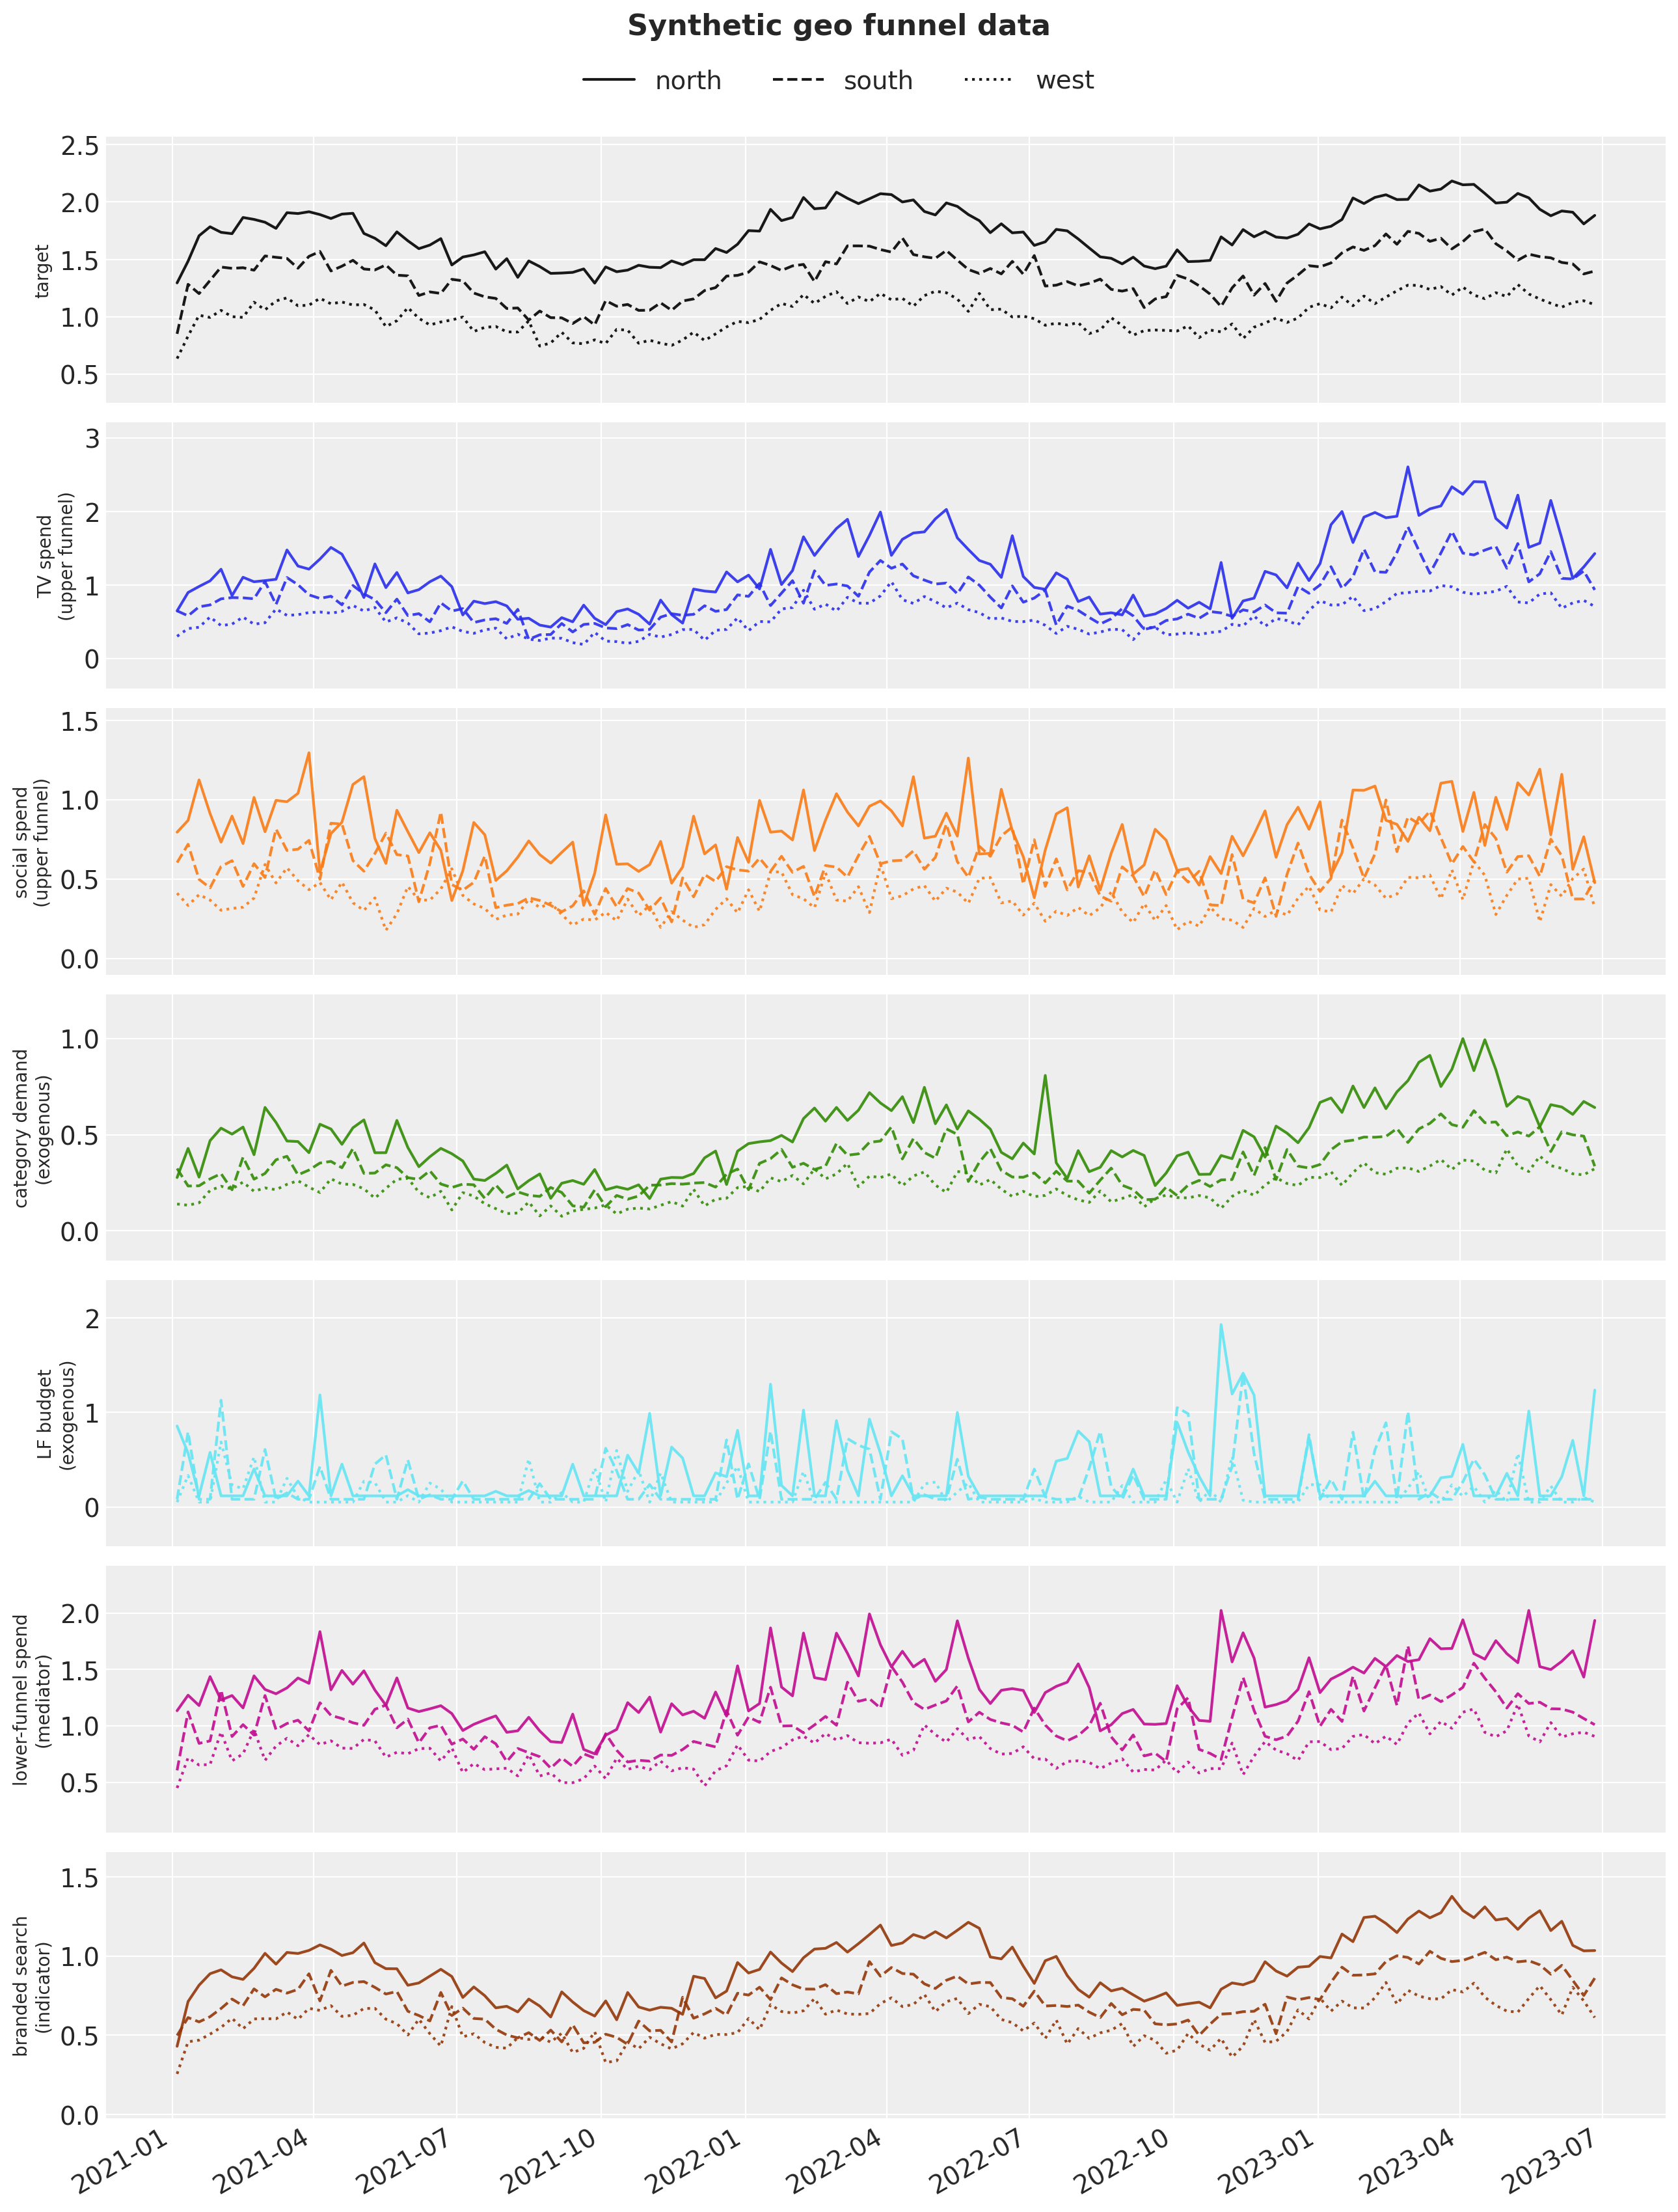

In [25]:
series = [
    ("y", "target", "black"),
    ("tv_spend", "TV spend\n(upper funnel)", "C0"),
    ("social_spend", "social spend\n(upper funnel)", "C1"),
    ("category_demand", "category demand\n(exogenous)", "C2"),
    ("lf_budget", "LF budget\n(exogenous)", "C5"),
    ("lower_spend", "lower-funnel spend\n(mediator)", "C3"),
    ("search_volume", "branded search\n(indicator)", "C4"),
]

fig, axes = plt.subplots(nrows=len(series), ncols=1, figsize=(13, 17), sharex=True)
for ax, (name, label, color) in zip(axes, series, strict=True):
    for geo, style in zip(geos, ["-", "--", ":"], strict=True):
        ax.plot(
            date_range,
            data[name].sel(geo=geo),
            linestyle=style,
            color=color,
            label=geo,
            alpha=0.9,
        )
    ax.set_ylabel(label, fontsize=10)
    ax.margins(y=0.25)
handles, geo_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, geo_labels, loc="upper center", bbox_to_anchor=(0.5, 0.982), ncols=3
)
fig.suptitle("Synthetic geo funnel data", fontsize=16, fontweight="bold", y=0.997)
fig.autofmt_xdate()
fig.set_layout_engine("tight", rect=(0, 0, 1, 0.972))

Zooming in on the latent layer shows how the pieces relate. Lower-funnel spend sits *above* latent demand by the budget-driven wedge $\lambda_g B_{t,g}$, and the reported series tracks that structural quantity up to reporting noise. Branded search follows demand itself, scaled by $\kappa$.

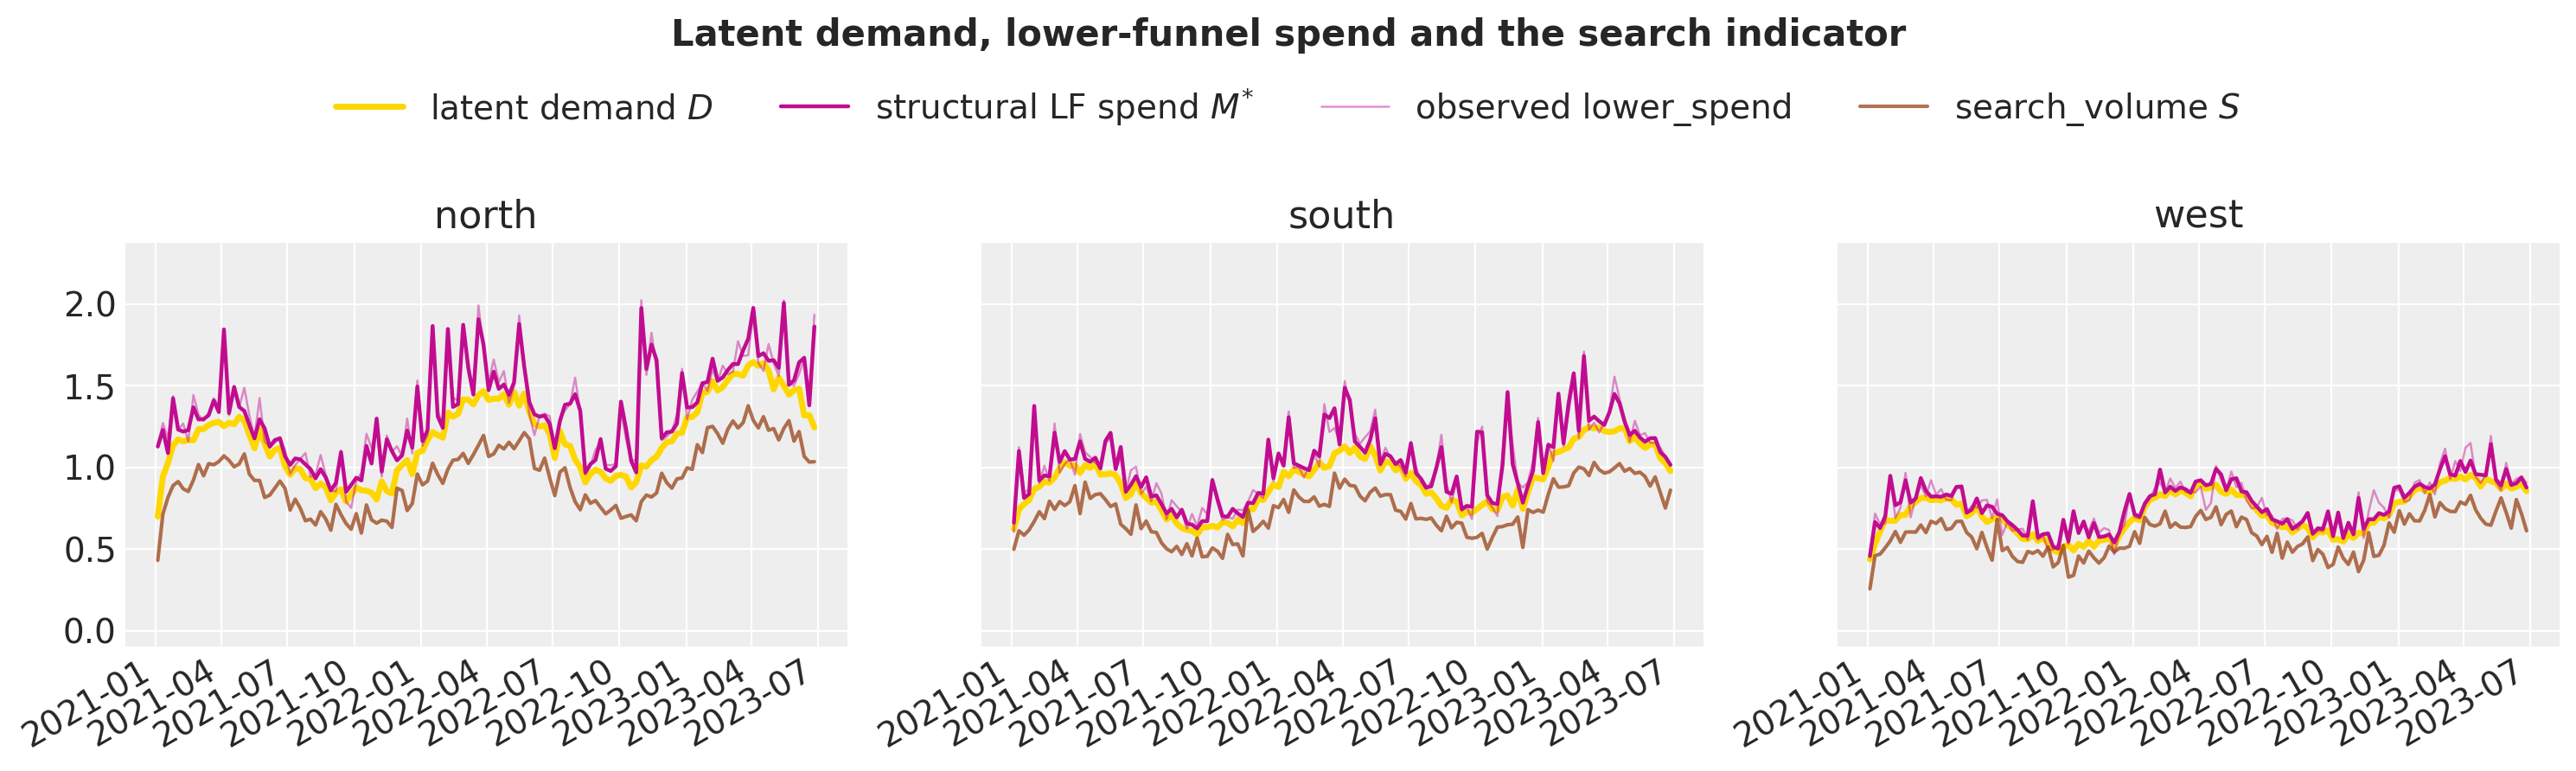

In [26]:
fig, axes = plt.subplots(ncols=len(geos), figsize=(15, 4.5), sharey=True)
for ax, geo in zip(axes, geos, strict=True):
    ax.plot(
        date_range,
        data["demand_true"].sel(geo=geo),
        color="gold",
        lw=2.5,
        label="latent demand $D$",
    )
    ax.plot(
        date_range,
        data["lf_spend_true"].sel(geo=geo),
        color="C3",
        lw=1.6,
        label="structural LF spend $M^{*}$",
    )
    ax.plot(
        date_range,
        data["lower_spend"].sel(geo=geo),
        color="C3",
        alpha=0.45,
        lw=0.9,
        label="observed lower_spend",
    )
    ax.plot(
        date_range,
        data["search_volume"].sel(geo=geo),
        color="C4",
        alpha=0.7,
        label="search_volume $S$",
    )
    ax.set_title(geo)
    ax.margins(y=0.2)
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    "Latent demand, lower-funnel spend and the search indicator",
    fontsize=15,
    fontweight="bold",
)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=4)
fig.autofmt_xdate()
fig.set_layout_engine("tight", rect=(0, 0, 1, 0.86))

## What the graph already says

Before fitting anything, the DAG itself can be interrogated. Each model below is, causally speaking, just a **conditioning set**: the variables it regresses the target on. Pearl's backdoor criterion says a set $Z$ identifies the *total* effect of a treatment on $Y$ exactly when (i) $Z$ contains no descendant of the treatment, and (ii) $Z$ d-separates treatment from target in the graph with the treatment's outgoing edges removed. Both conditions are mechanical graph checks, and [networkx](https://networkx.org/documentation/stable/reference/algorithms/d_separation.html) ships them, so instead of asserting who is biased and why, we can compute it.

```{seealso}
New to backdoor paths and d-separation? Pearl, Glymour and Jewell, [*Causal Inference in Statistics: A Primer*](http://bayes.cs.ucla.edu/PRIMER/) (Wiley, 2016) is the standard gentle introduction to both, and *The Book of Why* (Pearl and Mackenzie, 2018) covers the ideas without the formalism. For how these checks drive model specification in PyMC-Marketing, see the [causal identification](mmm_causal_identification.ipynb) and [causal reasoning and discovery](mmm_causal_reasoning_and_discovery.ipynb) notebooks.
```

One simplification is worth naming before anything is read off the graph: it is a **single time slice**. Both adstocks put $U_{t-k} \to D_t$ and $M^{*}_{t-k} \to Y_t$ in the data-generating process, and `season` and `t` are per-date, so each node here stands for a whole series rather than one week's value. That is the right reading for an MMM, whose control columns condition on the entire series rather than on row $t$, but it is a choice the drawing does not show, and a genuinely lagged confounder would need a graph that does.

The same edge list that drew the figure builds the graph:


In [27]:
G = nx.DiGraph([(parent, child) for parent, child, _ in DAG_EDGES])
treatment, outcome = "U1", "Y"

descendants = nx.descendants(G, treatment)

# Backdoor surgery: remove the treatment's outgoing edges.
G_do = G.copy()
G_do.remove_edges_from(list(G.out_edges(treatment)))

# What each model conditions on when estimating tv_spend's effect. Every model
# includes the other channel and the Fourier basis (= the `season` node); they
# differ only in what else they add.
conditioning_sets = {
    "Naive A (mediator as channel)": {"U2", "season", "M"},
    "Naive B (mediator omitted)": {"U2", "season"},
    "Naive B+ (demand as control)": {"U2", "season", "C"},
    "Naive B++ (trend as control)": {"U2", "season", "t"},
    "Naive C (indicator as channel)": {"U2", "season", "S"},
    "(hypothetical: condition on M*)": {"U2", "season", "MS"},
}

rows = {}
for label, Z in conditioning_sets.items():
    forbidden = sorted(Z & descendants)
    blocks = nx.is_d_separator(G_do, {treatment}, {outcome}, Z)
    rows[label] = {
        "conditions on": ", ".join(sorted(Z)),
        "descendant of U₁ in Z": ", ".join(forbidden) or "none",
        "blocks all backdoors": blocks,
        "valid for total effect": blocks and not forbidden,
    }

# The verdicts are symmetric in the treatment: re-run every check with U2 as
# treatment (its conditioning sets swap in the *other* channel, U1).
G_do_u2 = G.copy()
G_do_u2.remove_edges_from(list(G.out_edges("U2")))
descendants_u2 = nx.descendants(G, "U2")
for label, Z in conditioning_sets.items():
    Z_u2 = {("U1" if z == "U2" else z) for z in Z}
    blocks_u2 = nx.is_d_separator(G_do_u2, {"U2"}, {outcome}, Z_u2)
    valid_u2 = blocks_u2 and not (Z_u2 & descendants_u2)
    if (
        blocks_u2 != rows[label]["blocks all backdoors"]
        or valid_u2 != rows[label]["valid for total effect"]
    ):
        raise ValueError(f"verdict differs with U2 as treatment: {label}")

pd.DataFrame(rows).T.style.set_caption(
    f"Backdoor verdicts for treatment {treatment}; "
    f"descendants({treatment}) = {{{', '.join(sorted(descendants))}}}; "
    "every verdict also holds with U2 as the treatment (checked)"
)

,conditions on,descendant of U₁ in Z,blocks all backdoors,valid for total effect
Naive A (mediator as channel),"M, U2, season",M,False,False
Naive B (mediator omitted),"U2, season",none,False,False
Naive B+ (demand as control),"C, U2, season",none,True,True
Naive B++ (trend as control),"U2, season, t",none,False,False
Naive C (indicator as channel),"S, U2, season",S,False,False
(hypothetical: condition on M*),"MS, U2, season",MS,True,False


A verdict is a boolean, and a boolean cannot say *how* a set fails or what it leaves behind. Counting the backdoor paths each conditioning set leaves open can. `networkx` has no built-in that lists open backdoor paths, so a short helper walks each path and applies the d-separation blocking rules, and every count it produces is cross-checked against `nx.is_d_separator`, so the hand-rolled logic cannot drift from the library's verdicts.

```{tip}
Conditioning on a **collider** *opens* paths that something else must close again. The last row below (`Naive B+` *without* its Fourier basis) shows the effect at `C`: it is the seasonal basis that does the closing there.
```


In [28]:
backdoor_paths = list(nx.all_simple_paths(G_do.to_undirected(), treatment, outcome))


def open_paths(Z):
    """Backdoor paths that conditioning set ``Z`` leaves open."""
    left_open = []
    for path in backdoor_paths:
        blocked = False
        for before, node, after in zip(path, path[1:], path[2:], strict=False):
            if G_do.has_edge(before, node) and G_do.has_edge(after, node):
                # A collider blocks unless it, or a descendant, is in Z.
                blocked = not ({node} | nx.descendants(G_do, node)) & Z
            else:
                blocked = node in Z
            if blocked:
                break
        if not blocked:
            left_open.append(path)
    return left_open


def render(path):
    """``U1 <- N -> C -> D -> MS -> Y``: arrows point the way the graph does."""
    out = [path[0]]
    for before, node in itertools.pairwise(path):
        out += ["->" if G_do.has_edge(before, node) else "<-", node]
    return " ".join(out)


adjustment_sets = {
    "the seasonal basis alone": {"season"},
    "Naive B": {"U2", "season"},
    "Naive B+": {"U2", "season", "C"},
    "Naive B++": {"U2", "season", "t"},
    "Naive B+ without the Fourier basis": {"U2", "C"},
}

# Certify the helper against the library: a set leaves zero paths open exactly
# when `is_d_separator` says it blocks them all.
for Z in adjustment_sets.values():
    if (len(open_paths(Z)) == 0) != nx.is_d_separator(G_do, {treatment}, {outcome}, Z):
        raise ValueError(f"open_paths disagrees with is_d_separator for {sorted(Z)}")

pd.DataFrame(
    {
        "conditioning set": {
            label: "{" + ", ".join(sorted(Z)) + "}"
            for label, Z in adjustment_sets.items()
        },
        "open backdoor paths": {
            label: len(open_paths(Z)) for label, Z in adjustment_sets.items()
        },
    }
).style.set_caption(
    f"Of {len(backdoor_paths)} backdoor paths from {treatment} to {outcome}"
)

,conditioning set,open backdoor paths
the seasonal basis alone,{season},6
Naive B,"{U2, season}",4
Naive B+,"{C, U2, season}",0
Naive B++,"{U2, season, t}",1
Naive B+ without the Fourier basis,"{C, U2}",9


In [29]:
pd.DataFrame(
    [
        {"conditioning set": label, "open path": render(path)}
        for label, Z in adjustment_sets.items()
        if 1 <= len(open_paths(Z)) <= 4
        for path in open_paths(Z)
    ]
).set_index("conditioning set")

,open path
conditioning set,
Naive B,U1 <- t -> U2 <- N -> C -> D -> MS -> Y
Naive B,U1 <- t -> C -> D -> MS -> Y
Naive B,U1 <- N -> U2 <- t -> C -> D -> MS -> Y
Naive B,U1 <- N -> C -> D -> MS -> Y
Naive B++,U1 <- N -> C -> D -> MS -> Y


Reading the verdicts off the table:

- **Naive B fails condition (ii).** With only the other channel and the seasonal basis conditioned, the backdoor $U_1 \leftarrow t \to C \to D \to M^{*} \to Y$ stays open, and so does its twin through the drivers' shared noise, $U_1 \leftarrow N \to C \to D \to M^{*} \to Y$. Note what this is *not*: omitting the mediator is the **correct** move for a total effect. That is what makes it a total effect. The graph-level defect is the open backdoor through the shared driver, whose trend strand is the co-movement the residual-correlation table showed surviving the seasonal adjustment on the TV side.
- **Naive B+ is valid; Naive B++ is not.** Both fork nodes, $t$ and $N$, sit upstream of *both* the treatment and $C$, and $C$ sits on both paths downstream of them, so conditioning on the observed category index blocks the trend strand **and** the noise strand at once. Conditioning on $t$ blocks only the strand it names: the noise path stays open, and $N$ is unobservable, so `Naive B++` cannot close it by adding a column. Neither variable is a descendant of the treatment, so what separates them is coverage, not condition (i).
- **The path count above says the same thing more concretely.** Of the 43 backdoor paths, `Naive B` leaves four open, `Naive B++` exactly one (the noise fork, listed above), and `Naive B+` none. `Naive B`'s four have one structure: two are the forks themselves, and two are hybrids that enter on one fork and exit on the other, spliced at the other channel. `season`, $t$ and $N$ all point into $U_2$, so the other channel is a **collider** as well as a regressor: conditioning on it closes the paths that run *through* it and opens the ones that meet *at* it; the first row measures exactly that, with the seasonal basis alone leaving six paths open and adding $U_2$ leaving four. All four exit through $C \to D \to M^{*} \to Y$, which is why conditioning on $C$ closes every one of them and `Naive B+` scores valid.
- **`Naive B+`'s credential is joint with the Fourier basis.** $C$ is a collider too: `season`, $t$ and $N$ point into it exactly as they do into $U_2$, so conditioning on it *opens* every path that meets there, and it is the seasonal basis (present in every model) that closes them again. Take the basis away and the same conditioning set leaves nine paths open, as the last row shows. A reader who switches `yearly_seasonality` off does not get a slightly worse `Naive B+`; they get a specification with no credential at all.
- **Naive A and Naive C fail condition (i)**: each conditions on a descendant of the treatment (`M` via $U_1 \to D \to M^{*} \to M$; `S` via $U_1 \to D \to S$), cutting into the causal path itself. No amount of extra controls repairs that. (Descendants of $D$ also open collider paths at $D$; on this graph every such path is re-blocked at $U_2$, which both conditioning sets contain, but free-by-accident is a property of this graph, not of the move.)
- **The hypothetical last row is the interesting one**: conditioning on the *structural* $M^{*}$ would block every backdoor, yet it is still invalid for the total effect for exactly the same reason: it is a descendant, and conditioning on it is what *defines* the direct effect instead.

That last distinction can be made precise. Removing the direct edge $U_1 \to Y$ and asking whether the conditioning set separates treatment from target tests whether it isolates the direct path:


In [30]:
G_direct = G.copy()
G_direct.remove_edge(treatment, "Y")

pd.DataFrame(
    {
        "isolates the direct effect": {
            "M* (structural)": nx.is_d_separator(
                G_direct, {treatment}, {outcome}, {"U2", "season", "MS"}
            ),
            "M (noisy observation, what Naive A has)": nx.is_d_separator(
                G_direct, {treatment}, {outcome}, {"U2", "season", "M"}
            ),
        }
    }
)

,isolates the direct effect
M* (structural),True
"M (noisy observation, what Naive A has)",False


So `Naive A` is not estimating the total effect *badly*; it is (approximately) estimating the **direct** effect. Approximately, because it conditions on the noisy observation `M` rather than the structural `M*`: strict d-separation fails through the measurement noise, and the approximation is good exactly to the extent $\sigma^M$ is small. Keep this in mind for the comparisons below, where we benchmark Naive A against the quantity it actually answers for.

Finally, the graph can be asked what adjustment it would *recommend*:


In [31]:
# Sorted: a set's repr order is not stable across processes, and these outputs
# are meant to reproduce exactly.
unrestricted = sorted(nx.find_minimal_d_separator(G_do, {treatment}, {outcome}))

# `N` is deliberately absent from `observable`: no dataset carries the drivers'
# shared noise. A practitioner can only act on the restricted answer.
observable = {"U2", "season", "C", "B", "M", "S", "t"} - descendants
restricted = sorted(
    nx.find_minimal_d_separator(
        G_do,
        {treatment},
        {outcome},
        included={"U2", "season"},
        restricted=observable | {"U2", "season"},
    )
)

pd.DataFrame(
    {
        "a minimal separator": {
            "unrestricted": str(unrestricted),
            "observables only": str(restricted),
        }
    }
)

,a minimal separator
unrestricted,"['N', 'season', 't']"
observables only,"['C', 'U2', 'season']"


In [32]:
# `find_minimal_d_separator` returns *a* minimal separator, not *the* minimal
# one. On a graph this size the whole lattice is enumerable (2**10 subsets),
# so count them all with `nx.is_minimal_d_separator` instead of over-reading
# one answer.
def minimal_separators(candidates):
    """Every minimal d-separator of (treatment, outcome) drawn from ``candidates``."""
    return sorted(
        [
            sorted(Z)
            for size in range(len(candidates) + 1)
            for Z in itertools.combinations(sorted(candidates), size)
            if nx.is_minimal_d_separator(G_do, {treatment}, {outcome}, set(Z))
        ],
        key=lambda Z: (len(Z), Z),
    )


pd.DataFrame(
    [
        {"restriction": "unrestricted", "minimal separator": str(Z)}
        for Z in minimal_separators(set(G) - {treatment, outcome})
    ]
    + [
        {"restriction": "observables only", "minimal separator": str(Z)}
        for Z in minimal_separators(observable | {"U2", "season"})
    ]
).set_index("restriction")

,minimal separator
restriction,
unrestricted,"['C', 'U2', 'season']"
unrestricted,"['D', 'U2', 'season']"
unrestricted,"['MS', 'U2', 'season']"
unrestricted,"['N', 'season', 't']"
observables only,"['C', 'U2', 'season']"


Unrestricted, *one* minimal separator the graph names is the season, the trend and $N$, which no dataset contains. Read that as a tie-break rather than an obstacle: the enumeration finds **four** minimal separators, and $\{C, U_2, \text{season}\}$ is one of them, exactly as small. `find_minimal_d_separator` returns whichever branch it walks into, so the latent variable in its answer is not the graph refusing to be adjusted. Minimality is not the only filter, though: the other two, $\{D, U_2, \text{season}\}$ and $\{M^{*}, U_2, \text{season}\}$, are ruled out a second time over by condition (i): both $D$ and $M^{*}$ are descendants of the treatment, as the verdict table's caption records. Unobservable, or a descendant, or the one usable alternative: that is the whole lattice.

Restricted to observed, non-descendant variables (and told that the other channel and the seasonal basis are already in every model), the answer is $\{C, U_2, \text{season}\}$, and now the enumeration says it is the **only** minimal one, with $U_2$ load-bearing: the same $U_2$ whose collider opens two paths in the count above. Load-bearing and collider-opening at once is not a contradiction; it is why a separation test and a path count answer different questions. **The graph nominates `Naive B+`'s specification**, and it drops $t$ altogether, because conditioning on the observed category index blocks the trend strand and the noise strand in one move.

```{note}
With `networkx` unpinned, the one output in this section a library upgrade could legitimately change is the *order* in which the open-path listing and the `find_minimal_d_separator` branch are returned; every count and every verdict is immune.
```

`Naive B++` is the cheaper specification (a column computed from the calendar, no extra data series), but it is valid only *conditionally*: it closes the trend fork and leaves the noise fork open, so reading it as a valid total-effect estimator is an assumption about the size of the driver-noise correlation we measured above ($|r| \le 0.18$ per geo against a floor of 0.13, and $\le 0.13$ pooled against 0.11). That is the honest status of most trend controls in practice, and it is worth stating as an assumption rather than a verdict. Both models are fit below, so the graph's ranking can be checked against the truth rather than taken on faith, and the empirical result is not the one the ranking suggests, which is the point of checking. The six verdicts in the table also hold with `U2` as the treatment: recomputed cell by cell in the loop that built it, not assumed; the direct-effect and separator checks are stated for `U1` only.

One model is deliberately missing from this analysis: the **funnel model** is not identified by an adjustment set at all. It identifies by specifying the full structural system, and that buys correctness exactly insofar as the demand equation is correctly specified (including $C$'s role in it) and nothing unobserved confounds $M^{*} \to Y$. The backdoor machinery cannot certify those assumptions; the parameter-recovery and proxy-predictive checks later in the notebook are their empirical substitute.

One more thing the graph makes testable. The exclusion restriction "the budget enters lower-funnel spend but not branded search" implies $B \perp S$ *marginally*: their only connecting path runs through the collider at $M^{*}$, which stays blocked as long as nothing downstream of it is conditioned on:


In [33]:
pd.DataFrame(
    {
        "B ⊥ S given Z": {
            "Z = {}": nx.is_d_separator(G, {"B"}, {"S"}, set()),
            "Z = {Y}": nx.is_d_separator(G, {"B"}, {"S"}, {"Y"}),
            "Z = {M}": nx.is_d_separator(G, {"B"}, {"S"}, {"M"}),
        }
    }
)

,B ⊥ S given Z
Z = {},True
Z = {Y},False
Z = {M},False


In [34]:
pd.DataFrame(
    {
        "corr(lf_budget, search_volume)": {
            geo: np.corrcoef(lf_budget[:, gi], search_obs[:, gi])[0, 1]
            for gi, geo in enumerate(geos)
        }
    }
).style.format("{:+.3f}")

,"corr(lf_budget, search_volume)"
north,-0.070
south,+0.046
west,-0.101


Two of the three per-geo correlations sit at zero, as the graph says they should. `west`'s -0.218 does not: it runs about two and a half times the sampling standard error quoted above, the kind of tail a marginal-independence check throws up now and again on 130 weeks. The restriction is exact in the DGP, so this is a statement about the draw rather than about the graph, and $\lambda$ is still cleanly recovered below. It is worth printing rather than hiding: on real data this is exactly the ambiguity you would have to resolve. (Per geo matters: pooled across regions both series scale with market size, a common cause of every exogenous series that deliberately has no node, because the whole graph is replicated per geo and every model conditions on `geo` by construction; and dropping that conditioning manufactures a spurious positive correlation. Conditioning on anything downstream of $M^{*}$, including the target, likewise *opens* the collider, so this check only works on the raw per-geo series.) If real data failed this check *systematically*, the exclusion restriction, and with it the identification of $\lambda$, would be suspect before a single model was fit.

```{note}
For production use, {class}`~pymc_marketing.mmm.causal.CausalGraphModel` packages related machinery: give `MMM` a DAG string and it derives an adjustment set via [dowhy](https://github.com/microsoft/dowhy), whose `CausalModel` it wraps. It is coarser than what we did here: `get_unique_adjustment_nodes` takes the *union* of every node lying on any backdoor path, minus treatment and outcome, with no d-separation test, no minimality, and no descendant or collider distinction. We ran the checks with raw `networkx` so that reasoning stays visible.
```


## Fitting the models

We now fit the six model structures defined at the top of the notebook, all on the same synthetic data. The five naive models differ from one another only in which observed series they condition on, so differences among *them* are structural.

The funnel model additionally observes more than any of them: two extra likelihood series (`lower_spend`, `search_volume`) and two extra inputs (`category_demand`, `lf_budget`). Where it has an advantage, that advantage comes from structure *and* information together, a distinction worth keeping in mind when reading the comparisons.


In [35]:
frame = (
    data[
        [
            "tv_spend",
            "social_spend",
            "lower_spend",
            "search_volume",
            "category_demand",
            "y",
        ]
    ]
    .to_dataframe()
    .reset_index()
)

X_upper = frame[["date", "geo", *channels]]
X_with_mediator = frame[["date", "geo", *channels, "lower_spend"]]
X_with_search = frame[["date", "geo", *channels, "search_volume"]]
X_with_control = frame[["date", "geo", *channels, "category_demand"]]
# The growth trend as a control regressor: observable from the calendar alone.
frame["t"] = frame["date"].map(dict(zip(date_range, t, strict=True)))
X_with_trend = frame[["date", "geo", *channels, "t"]]
y = frame["y"]

sample_kwargs = dict(chains=4, tune=1_000, draws=1_000, target_accept=0.95)
sampler_config = {"nuts_sampler": "nutpie"}

### `Naive A (mediator as channel)`: the mediator as an ordinary channel

This is what most production MMMs do when they have upper- and lower-funnel spend in the same table: list them side by side. It is not an unreasonable model: in this DAG lower-funnel spend really does drive the target, so the coefficient it estimates is a real thing. But as the d-separation table showed, conditioning on the mediator **blocks the indirect path**: the upper channels are credited with at most their direct effect, and the lower-funnel channel keeps the credit for demand they created. `Naive A (mediator as channel)` is not a broken model so much as a model that silently answers a different question (the *direct* effect), and we will benchmark it against that quantity as well as against the total.


In [36]:
naive_a = make_mmm([*channels, "lower_spend"], sampler_config=sampler_config)
naive_a.build_model(X_with_mediator, y)
naive_a.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_a.fit(X_with_mediator, y, random_seed=rng, **sample_kwargs)
naive_a.sample_posterior_predictive(X_with_mediator, random_seed=rng);

Sampling: [adstock_alpha, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y_sigma]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

### `Naive B (mediator omitted)`

Here the two upper channels are the only media. Causally this is the **right estimand**: not conditioning on the mediator is exactly what makes a total effect a total effect. `Naive B (mediator omitted)` has two distinct problems, and they will land on different channels. The first is the one the graph isolated: the open backdoor through the shared growth trend, which the residual-correlation table showed is material for TV and absent for social. The second the graph is silent about: with the mediator omitted, each response curve also has to absorb the demand its channel creates downstream, mediated through a saturating pool the model does not represent. Where each part lands, we will let the results say.


In [37]:
naive_b = make_mmm(channels, sampler_config=sampler_config)
naive_b.build_model(X_upper, y)
naive_b.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_b.fit(X_upper, y, random_seed=rng, **sample_kwargs)
naive_b.sample_posterior_predictive(X_upper, random_seed=rng);

Sampling: [adstock_alpha, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y_sigma]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

### `Naive B+ (demand as control)`: mediator omitted, category demand as a control

This is the adjustment the d-separation analysis nominated: block the remaining backdoors with the observed category index, which sits downstream of *both* forks in the shared driver. `MMM` takes it as an ordinary **control column** (a linear term with a per-geo coefficient, no adstock or saturation), which is one argument and no new machinery:


In [38]:
naive_bplus = make_mmm(
    channels, control_columns=["category_demand"], sampler_config=sampler_config
)
naive_bplus.build_model(X_with_control, y)
naive_bplus.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_bplus.fit(X_with_control, y, random_seed=rng, **sample_kwargs)
naive_bplus.sample_posterior_predictive(X_with_control, random_seed=rng);

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y_sigma]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Two things to note before seeing results. First, on the graph this is a **formally valid total-effect estimator** at the cost of one extra column: if all you need is total ROAS per upper channel, specifications like this are the honest baseline the funnel model has to beat. Second, its control is a linear stand-in for a path that is truly nonlinear ($C$ enters through the demand equation and then a saturating conversion), so some residual bias is possible even though the graph verdict is clean: d-separation is about *which* variables suffice, not about functional form. Keep that caveat in mind: it returns with force below.

### `Naive B++ (trend as control)`: mediator omitted, the trend as a control

The second candidate is the cheapest specification available here: no extra data series at all, since the regressor is a function of the calendar, just one more control column with a per-geo coefficient. On the graph it is valid only under the extra assumption that the drivers' shared noise is negligible, which is the kind of assumption trend controls usually rest on and which we sized above rather than waved at. The same functional-form caveat applies as for `Naive B+ (demand as control)`: the trend reaches the target through softplus-rectified plans and a saturating conversion, and a linear term stands in for all of it.


In [39]:
naive_bpp = make_mmm(channels, control_columns=["t"], sampler_config=sampler_config)
naive_bpp.build_model(X_with_trend, y)
naive_bpp.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_bpp.fit(X_with_trend, y, random_seed=rng, **sample_kwargs)
naive_bpp.sample_posterior_predictive(X_with_trend, random_seed=rng);

Sampling: [adstock_alpha, gamma_control, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y_sigma]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

### `Naive C (indicator as channel)`: the indicator as a channel

Branded search volume is the most tempting variable in the whole dataset. It correlates beautifully with sales, it is free, and it arrives weekly. So it ends up in the channel list.

It causes nothing. Because it is a **descendant of latent demand**, conditioning on it blocks $U \to D \to M^{*} \to Y$ just as surely as conditioning on the mediator itself would: textbook post-treatment conditioning, on a variable that has no causal role at all.


In [40]:
naive_c = make_mmm([*channels, "search_volume"], sampler_config=sampler_config)
naive_c.build_model(X_with_search, y)
naive_c.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_c.fit(X_with_search, y, random_seed=rng, **sample_kwargs)
naive_c.sample_posterior_predictive(X_with_search, random_seed=rng);

Sampling: [adstock_alpha, gamma_fourier, intercept_contribution, saturation_beta, saturation_lam, y_sigma]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: [y]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

### The funnel model

The funnel model has the two upper channels (their direct effects) plus the `BudgetDualIndicatorEffect`, which reads the mediator data from the `Dataset` and fits the target and both proxies jointly. Note the plumbing discussed earlier: we build from the `Dataset` and fit with the long frame.


In [41]:
ds_fit = make_dataset(
    media_raw, lower_spend_obs, search_obs, category_demand, lf_budget
)
y_fit = xr.DataArray(y_obs, dims=("date", "geo"), coords=coords)

funnel = make_mmm(channels, sampler_config=sampler_config)
funnel.add_mu_effect(make_budget_dual_indicator_effect())
funnel.build_model(X=ds_fit, y=y_fit)
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "budget_dual_effect_contribution", "y"]
)
funnel.fit(X=X_upper, y=y, random_seed=rng, **sample_kwargs)
funnel.sample_posterior_predictive(X_upper, random_seed=rng);

Sampling: [adstock_alpha, adstock_contribution_alpha, adstock_hub_input_alpha, budget_dual_baseline, budget_dual_budget_coef, budget_dual_hub_indicator_sigma, budget_dual_indicator_coef, budget_dual_parent_coef, budget_dual_spend_measurement_sigma, gamma_fourier, intercept_contribution, sat_contribution_beta, sat_contribution_lam, sat_hub_input_beta, sat_hub_input_lam, saturation_beta, saturation_lam, y_sigma]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [budget_dual_hub_indicator, budget_dual_spend_measurement, y]


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

### Diagnostics

In [42]:
models = {
    "Naive A": naive_a,
    "Naive B": naive_b,
    "Naive B+": naive_bplus,
    "Naive B++": naive_bpp,
    "Naive C": naive_c,
    "Funnel": funnel,
}

# Scalar parameters only: summarising the date x geo deterministics would
# dominate this cell's runtime.
scalar_params = [
    "intercept_contribution",
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_fourier",
    "gamma_control",
    "y_sigma",
    "budget_dual_baseline",
    "budget_dual_parent_coef",
    "budget_dual_budget_coef",
    "budget_dual_indicator_coef",
    "budget_dual_spend_measurement_sigma",
    "budget_dual_hub_indicator_sigma",
    "adstock_hub_input_alpha",
    "sat_hub_input_lam",
    "sat_hub_input_beta",
    "adstock_contribution_alpha",
    "sat_contribution_lam",
    "sat_contribution_beta",
]

sampler_diagnostics = {}
for label, model in models.items():
    present = [v for v in scalar_params if v in model.idata.posterior]
    sampler_diagnostics[label] = {
        "divergences": int(model.idata["sample_stats"]["diverging"].sum()),
        "max r-hat": float(az.summary(model.idata, var_names=present)["r_hat"].max()),
    }

pd.DataFrame(sampler_diagnostics).T.style.format({"max r-hat": "{:.3f}"})

,divergences,max r-hat
Naive A,0.000000,1.000
Naive B,0.000000,1.000
Naive B+,0.000000,1.000
Naive B++,0.000000,1.000
Naive C,0.000000,1.000
Funnel,0.000000,1.000


### Posterior predictive checks

The funnel model has **three** observed quantities. All of them should be well recovered.


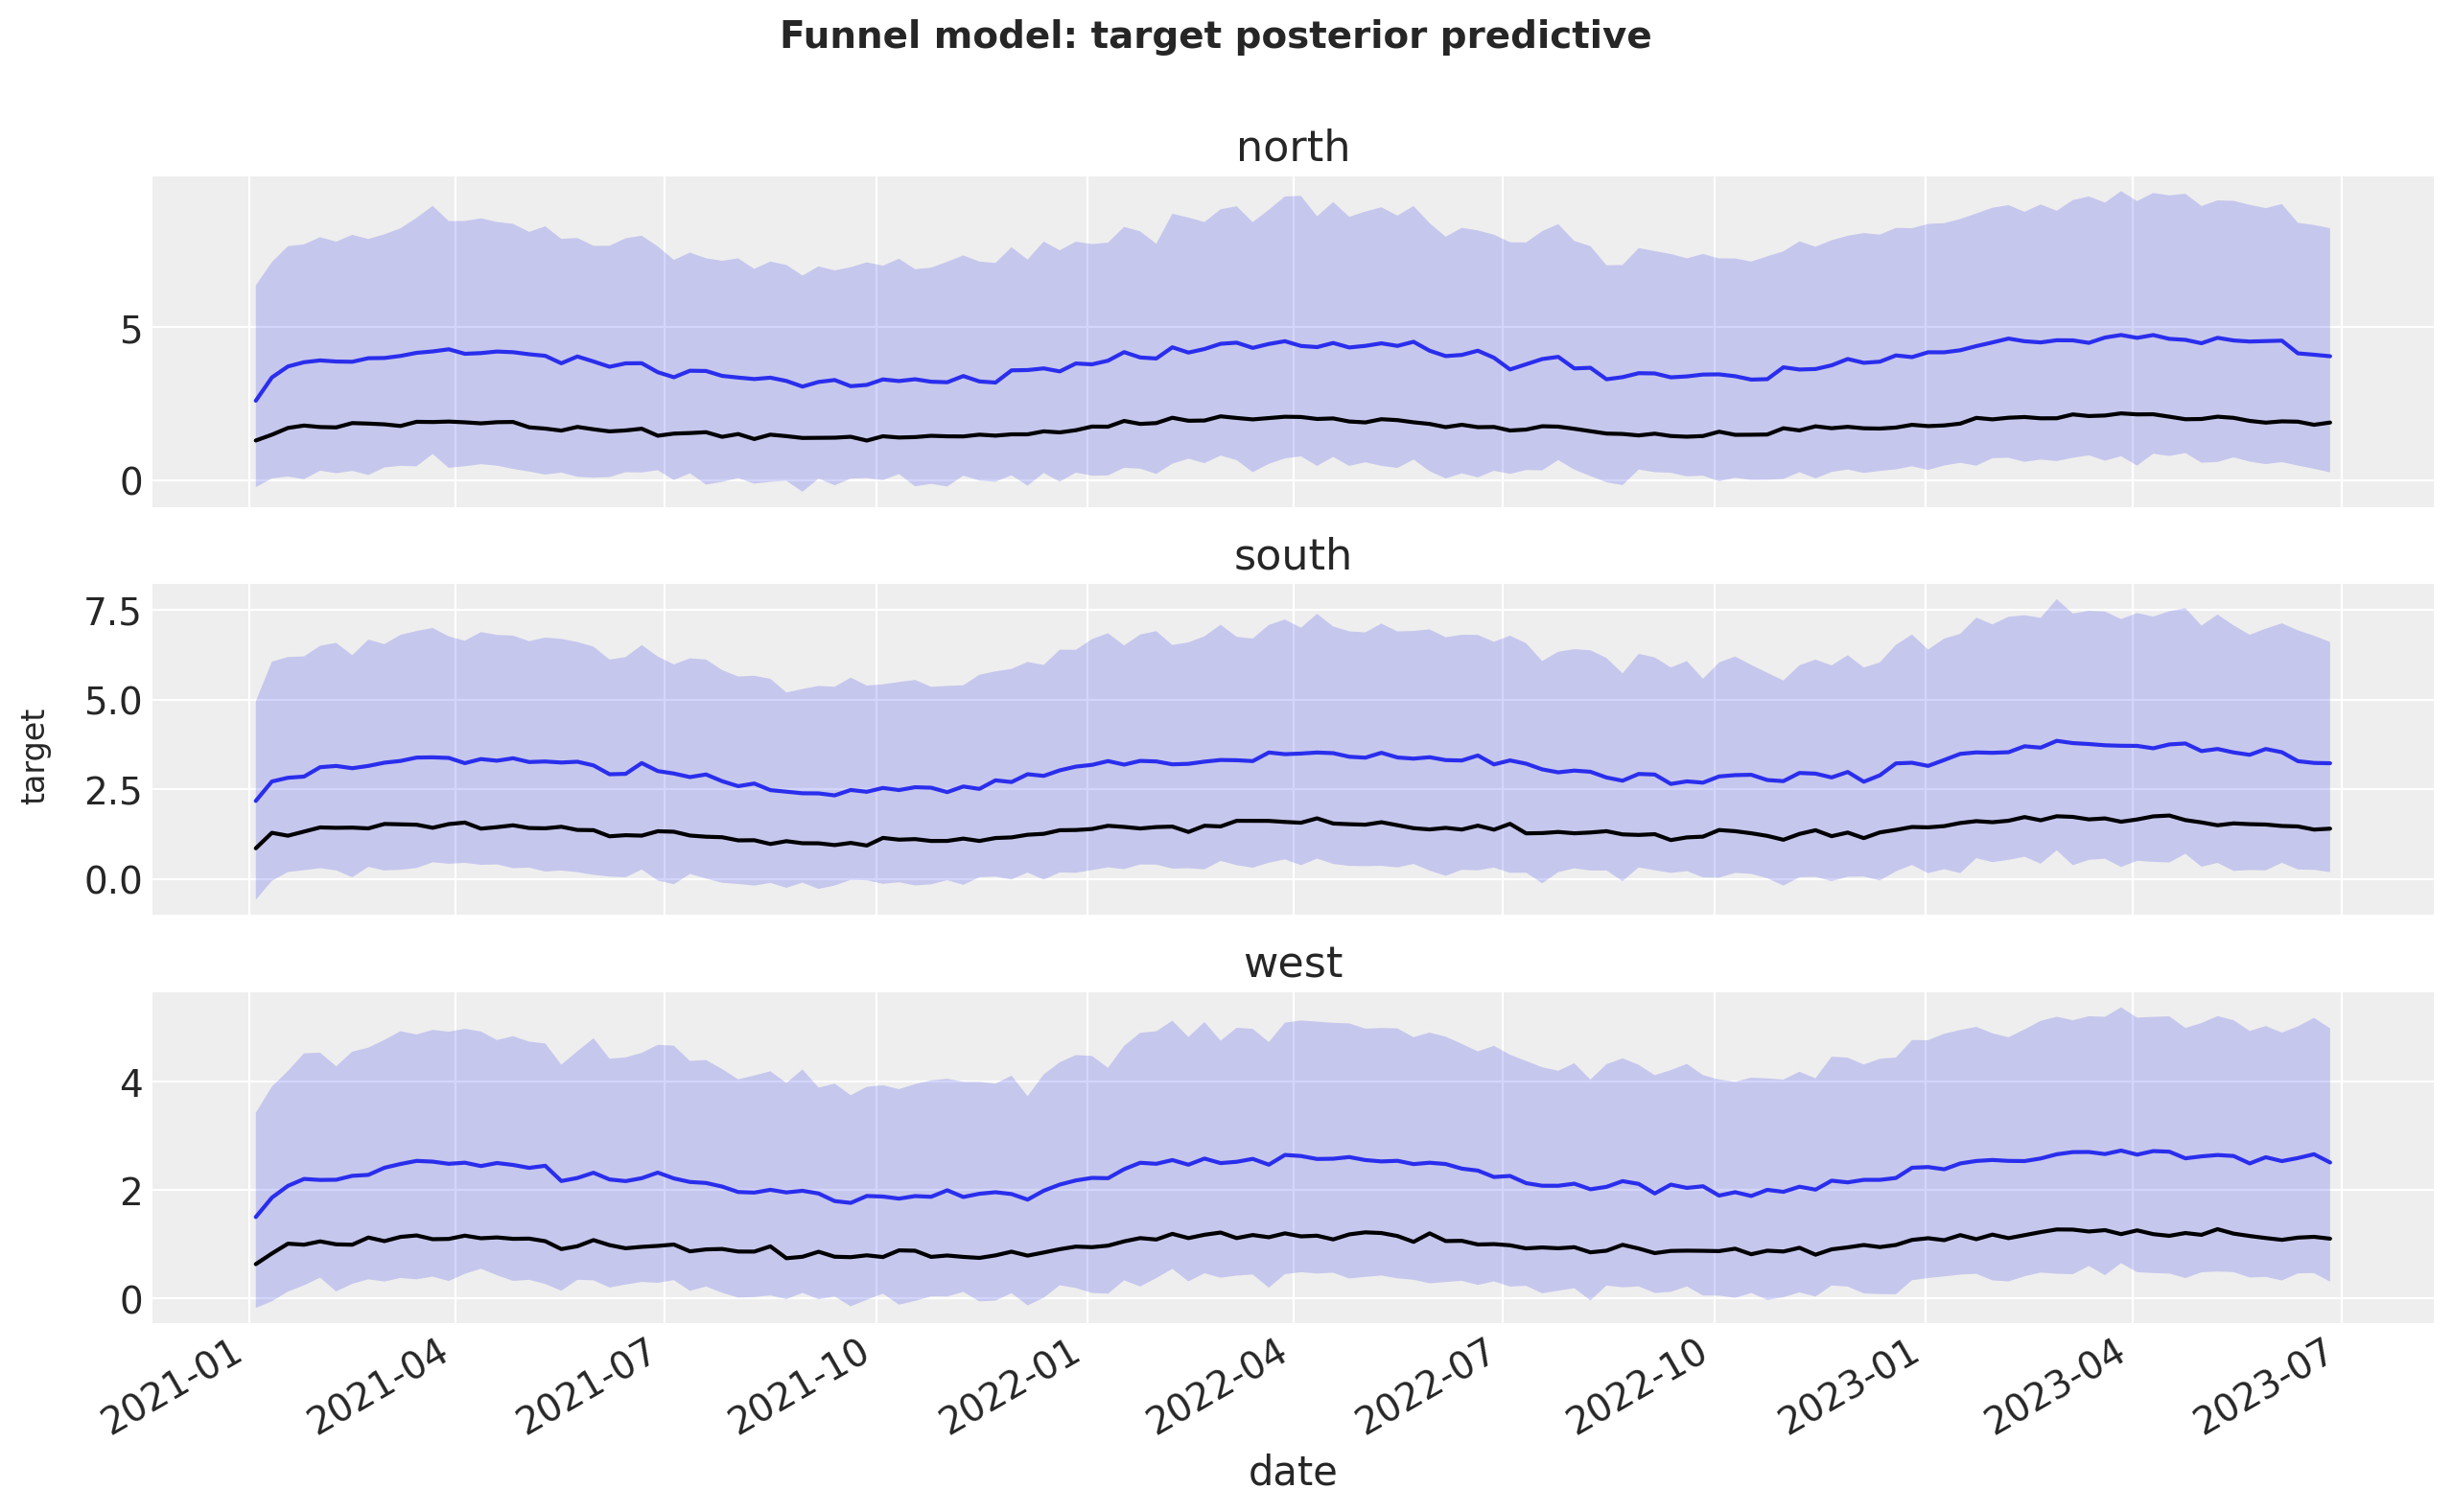

In [43]:
funnel.plot_suite = "new"

pc = funnel.plot.diagnostics.posterior_predictive(
    hdi_prob=0.94, return_as_pc=True, figsize=(13, 8)
)
fig = pc.viz["figure"].item()

for i, geo in enumerate(geos):
    ax = pc.viz["plot"].sel(geo=geo).item()
    ax.set_xlabel("date" if i == len(geos) - 1 else "")
    ax.set_ylabel("")
    ax.set_title(geo)

fig.supylabel("target")
fig.suptitle(
    "Funnel model: target posterior predictive", fontsize=14, fontweight="bold"
)
fig.autofmt_xdate()
fig.set_layout_engine("tight", rect=(0.01, 0, 1, 0.97))

The other two are the effect's own likelihoods. There is no built-in for these: `diagnostics.posterior_predictive` targets the model's `y` variable specifically, so a custom likelihood declared inside a `MuEffect` has to be plotted by hand.

Those panels quote a posterior HDI, as does nearly every figure from here on, so a small helper for the interval bounds comes first:


In [44]:
def hdi_bounds(da, prob: float = 0.94):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")

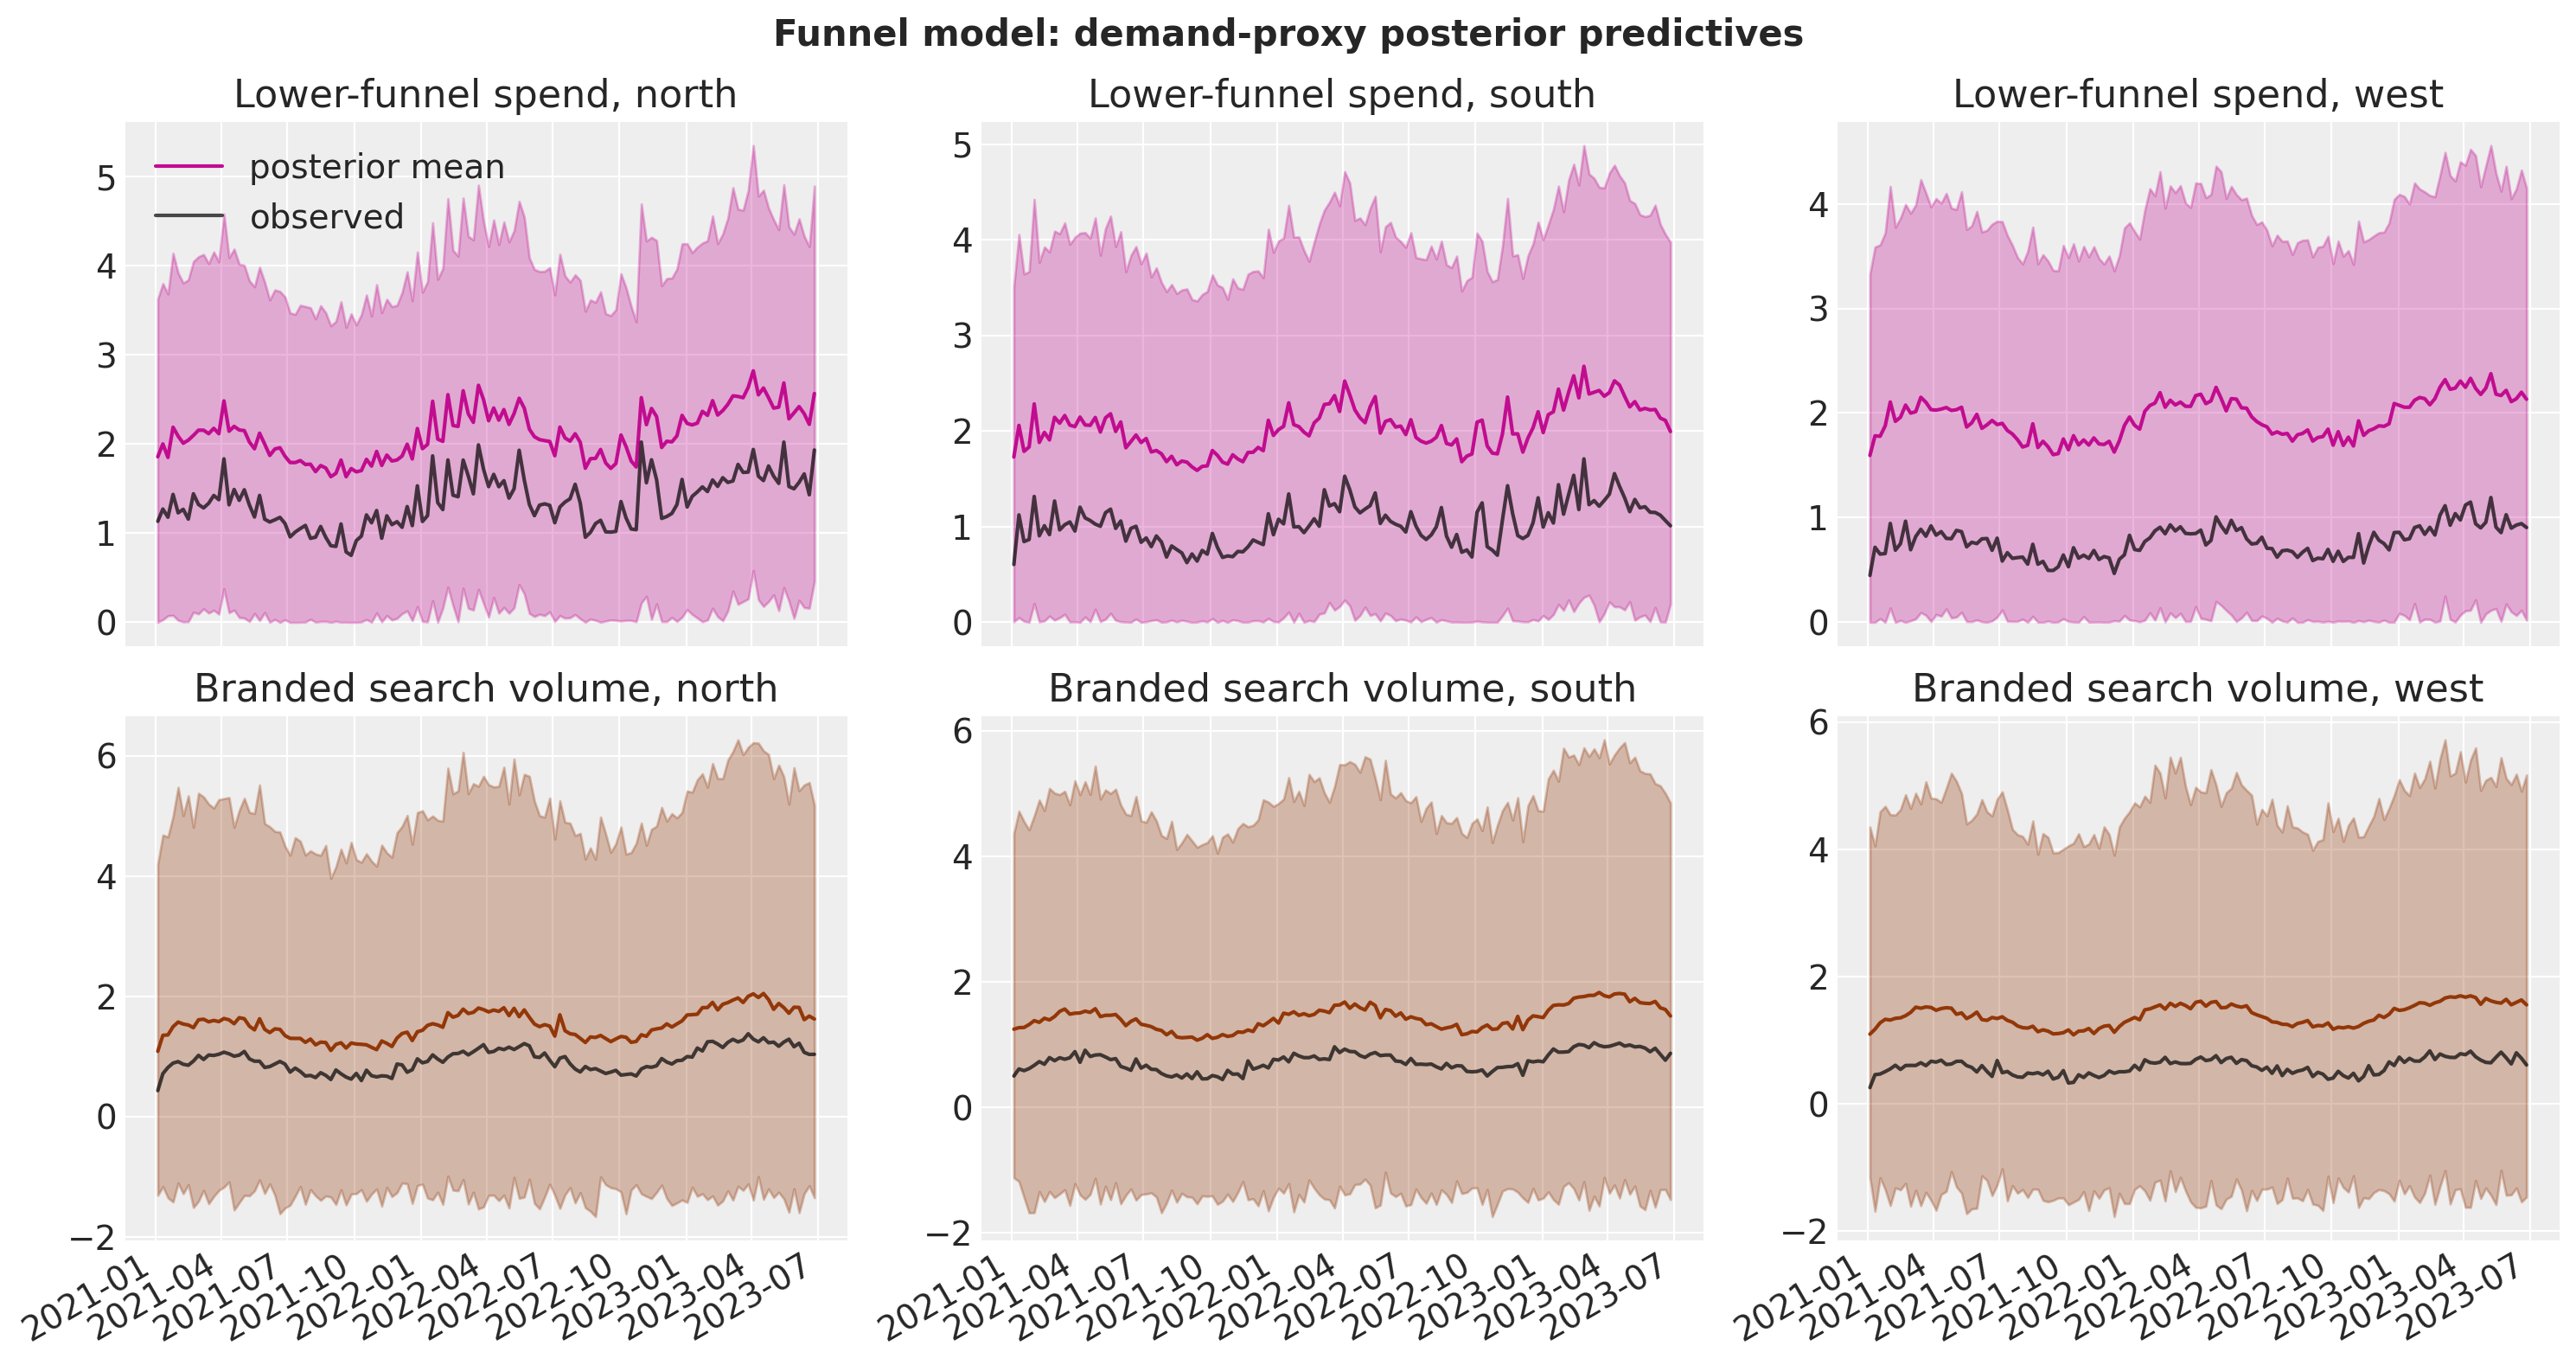

In [45]:
proxies = [
    ("budget_dual_spend_measurement", "lower_spend", "Lower-funnel spend", "C3"),
    ("budget_dual_hub_indicator", "search_volume", "Branded search volume", "C4"),
]

fig, axes = plt.subplots(
    nrows=len(proxies), ncols=len(geos), figsize=(15, 8), sharex=True
)
for row, (var, observed, title, color) in enumerate(proxies):
    pp = funnel.idata.posterior_predictive[var]
    lo, hi = hdi_bounds(pp)
    mean = pp.mean(dim=["chain", "draw"])
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        ax.fill_between(
            date_range, lo.sel(geo=geo), hi.sel(geo=geo), alpha=0.3, color=color
        )
        ax.plot(date_range, mean.sel(geo=geo), color=color, label="posterior mean")
        ax.plot(
            date_range,
            data[observed].sel(geo=geo),
            color="black",
            alpha=0.7,
            label="observed",
        )
        ax.set(title=f"{title}, {geo}")
axes[0, 0].legend(loc="upper left")
fig.suptitle(
    "Funnel model: demand-proxy posterior predictives",
    fontsize=15,
    fontweight="bold",
)
fig.autofmt_xdate()
fig.set_layout_engine("tight")

## Parameter recovery

```{important}
**Where this lands.** The funnel model recovers the ground truth, but the direct and demand paths are only weakly identified *apart*: in all six channel-geo cells the two amplitudes miss in opposite directions. That seesaw is a property of two paths originating at the same spend, not six independent misses, and the total effects further down survive it. `west` is the hardest geo, by construction.
```

Because we generated the data we can check the funnel model against the truth. One subtlety carries over from the basic notebook and gets slightly more involved here: the `MMM` fits on an internally scaled target, so every parameter that acts on the **scale of the target mean** (the intercept, the two saturation amplitudes and the Fourier coefficients) must be multiplied by `target_scale` before comparing with the ground truth. With `dims=()` scaling that factor is **per geo**, and `xarray` applies it by label for us. Parameters acting on the *inputs* (adstock decays, saturation curvatures) or on the *mediator* scale (everything in the demand equation) are scale-free and compare directly.


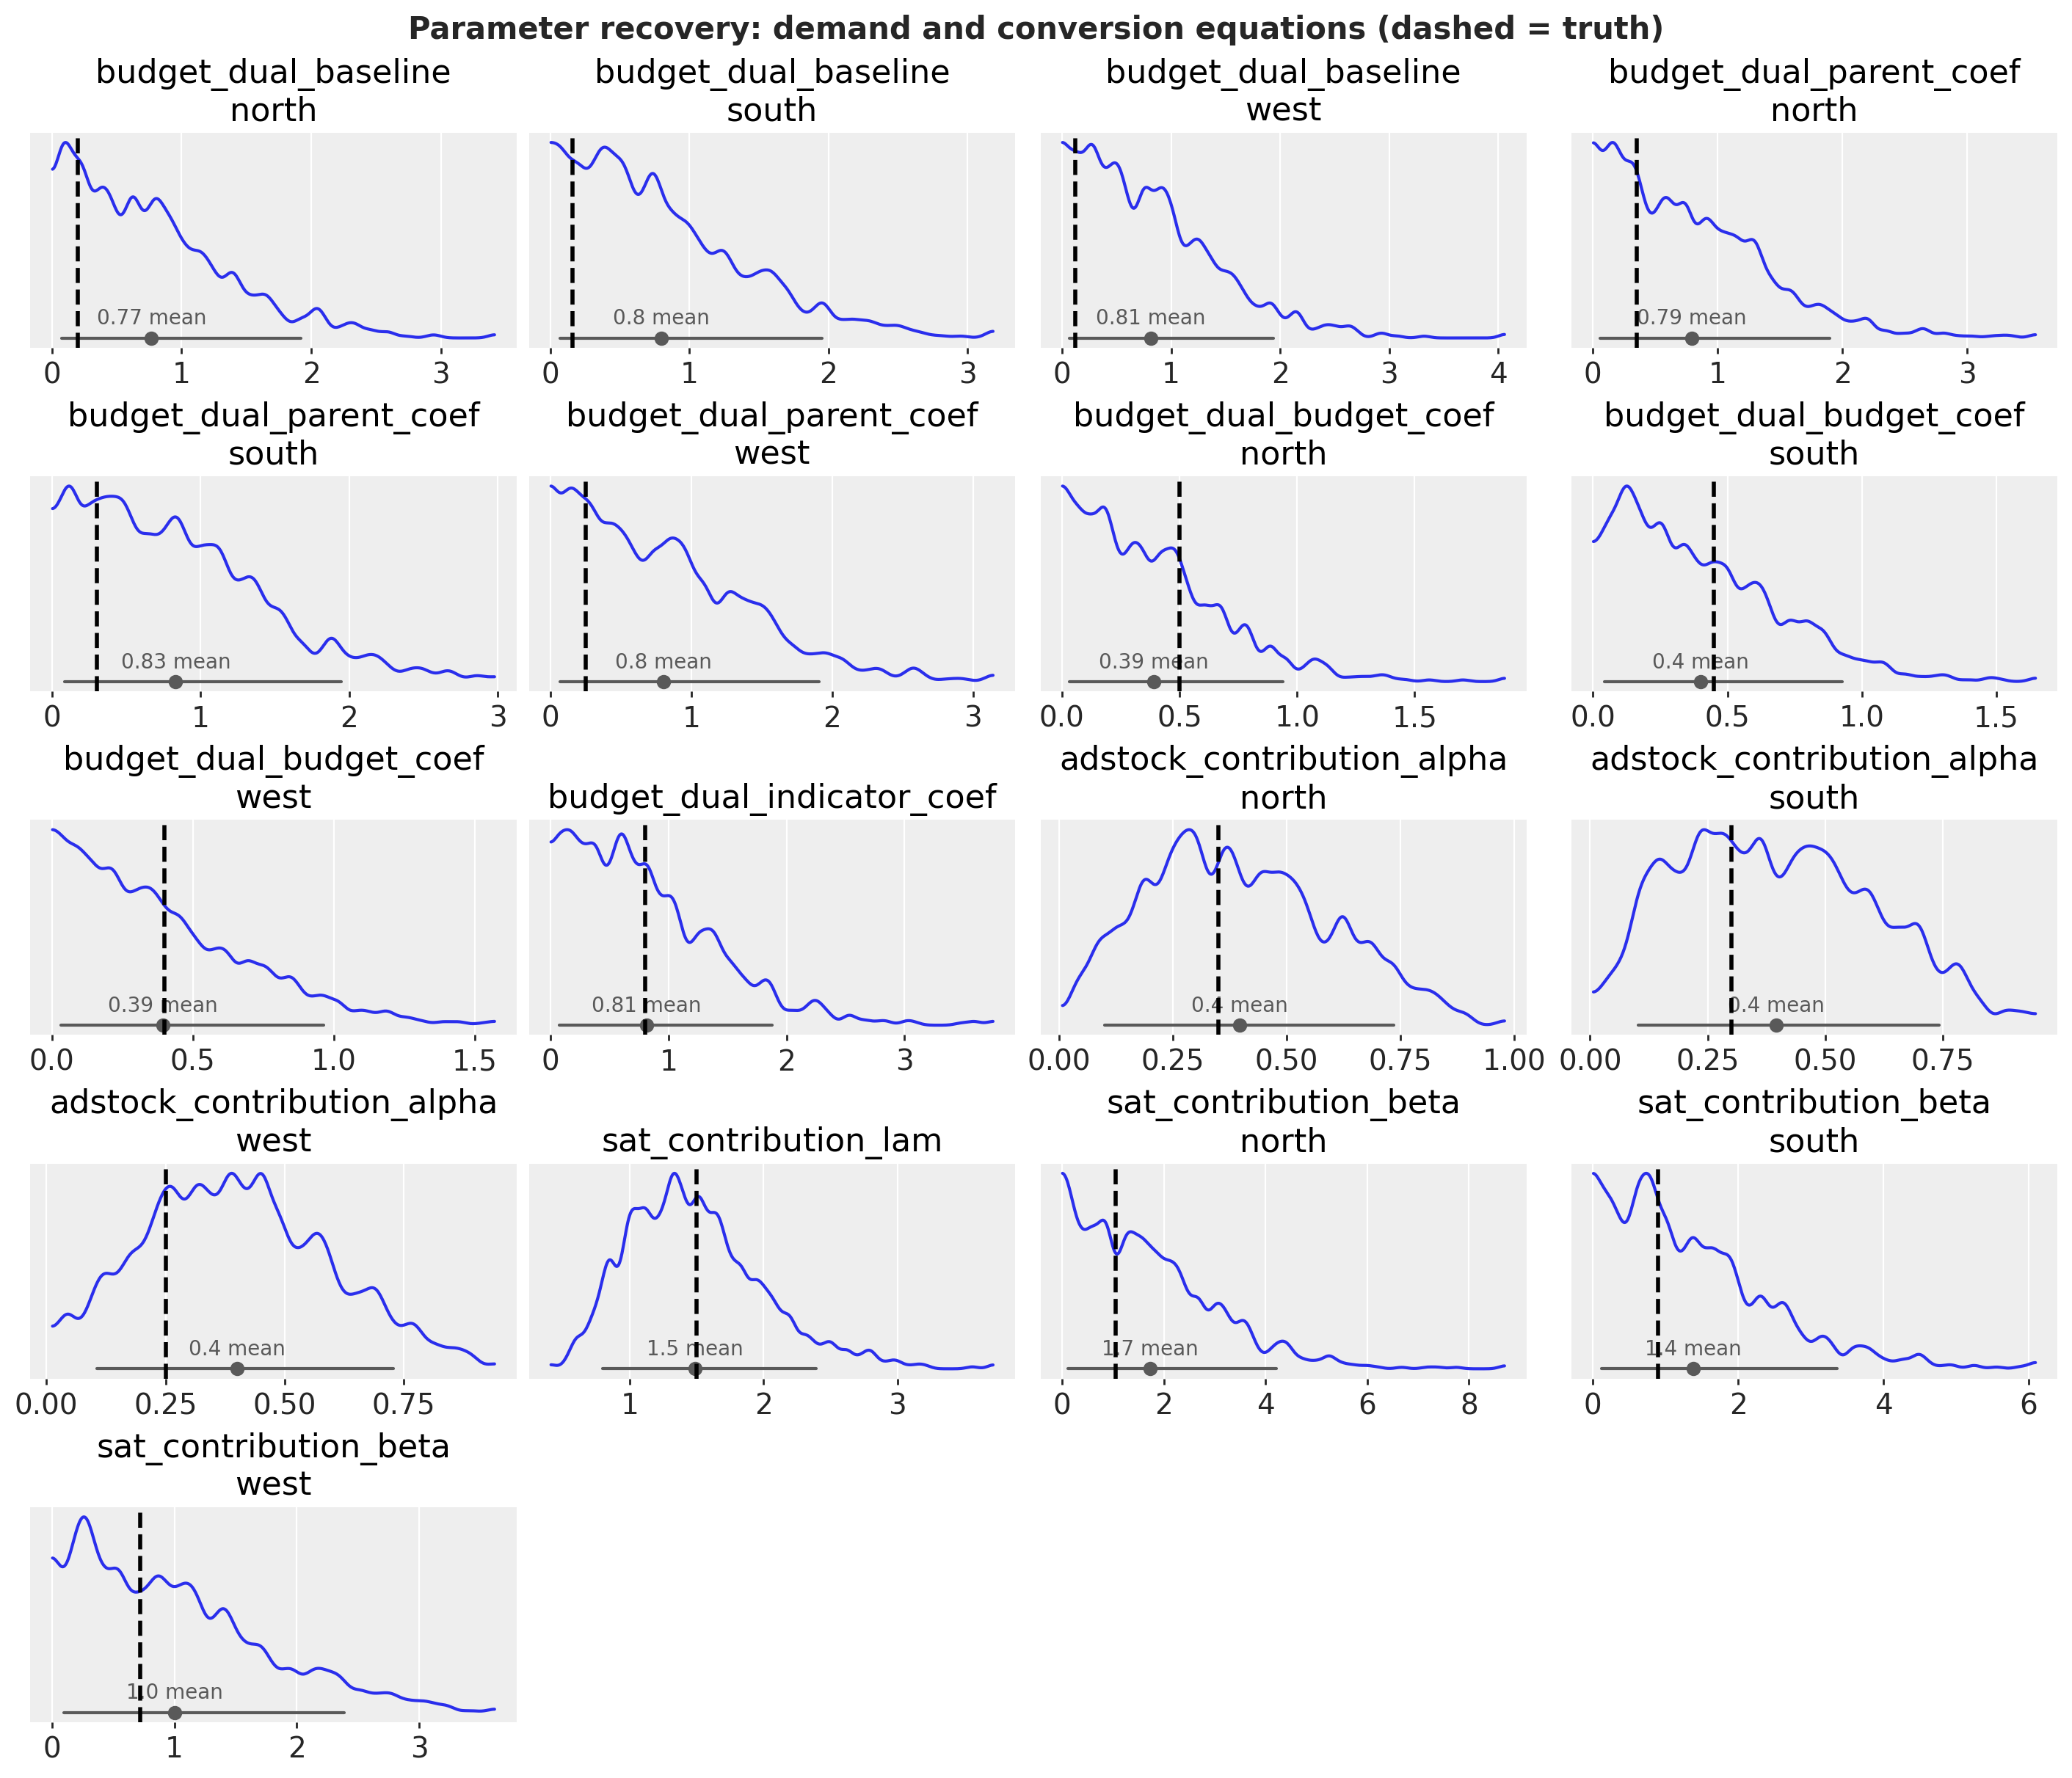

In [46]:
target_scale = funnel.idata.constant_data["target_scale"]
mu_scale_vars = {
    "intercept_contribution",
    "saturation_beta",
    "sat_contribution_beta",
    "gamma_fourier",
}

posterior_on_true_scale = xr.Dataset(
    {
        var: (draws * target_scale if var in mu_scale_vars else draws)
        for var, draws in funnel.idata.posterior.data_vars.items()
    }
)
recovery_idata = xr.DataTree.from_dict(
    {"posterior": xr.DataTree(posterior_on_true_scale)}
)


def truth_dataset(var_names: list[str]) -> xr.Dataset:
    """Ground truth for ``var_names`` as a Dataset matching the posterior's dims."""
    labels = {"geo": geos, "channel": channels}
    out = {}
    for var in var_names:
        dims = funnel.model.named_vars_to_dims.get(var) or ()
        out[var] = xr.DataArray(
            true[var], dims=dims, coords={d: labels[d] for d in dims}
        )
    return xr.Dataset(out)


def recovery_plot(var_names: list[str], title: str, figsize: tuple[float, float]):
    """Posterior KDEs from the built-in plot suite, with true values overlaid."""
    pc = funnel.plot.diagnostics.posterior(
        var_names=var_names,
        idata=recovery_idata,
        return_as_pc=True,
        figure_kwargs={"figsize": figsize, "layout": "constrained"},
    )
    azp.add_lines(
        pc,
        truth_dataset(var_names),
        visuals={
            "ref_line": {
                "color": "black",
                "linestyle": "--",
                "linewidth": 2,
                # Above the axes grid: at the default zorder the white gridlines
                # are painted over the truth line wherever it lands on a grid x.
                "zorder": 3,
            }
        },
    )
    fig = pc.viz["figure"].item()
    fig.suptitle(title, fontsize=15, fontweight="bold")
    return pc


recovery_plot(
    [
        "budget_dual_baseline",
        "budget_dual_parent_coef",
        "budget_dual_budget_coef",
        "budget_dual_indicator_coef",
        "adstock_contribution_alpha",
        "sat_contribution_lam",
        "sat_contribution_beta",
    ],
    "Parameter recovery: demand and conversion equations (dashed = truth)",
    (14, 12),
);

The two loadings that carry the new structure, `budget_dual_budget_coef` and `budget_dual_indicator_coef`, are pinned down tightly, which is what we want: they decide how much of lower-funnel spend is demand-driven and how strongly branded search tracks demand. Not everything in the new block is that sharp: the recovery table below puts `adstock_contribution_alpha` in `west` at 0.152 against a true 0.250, covered but loose.

It is worth checking that $\lambda$ is genuinely *identified* rather than simply returning its prior: an unidentified parameter still produces a posterior that happily brackets the truth. Two things to look at: how much the data sharpened it relative to the prior, and whether it traded off against the demand baseline it shares a level with.


In [47]:
prior_lambda_sd = 0.5 * np.sqrt(1 - 2 / np.pi)  # sd of HalfNormal(sigma=0.5)
lambda_draws = funnel.idata.posterior["budget_dual_budget_coef"]

identification = pd.DataFrame(
    {
        "posterior mean": lambda_draws.mean(dim=["chain", "draw"]).to_series(),
        "true": pd.Series(true["budget_dual_budget_coef"], index=geos),
        "posterior sd / prior sd": (
            lambda_draws.std(dim=["chain", "draw"]) / prior_lambda_sd
        ).to_series(),
        "corr(lambda, baseline)": pd.Series(
            {
                geo: float(
                    xr.corr(
                        lambda_draws.sel(geo=geo),
                        funnel.idata.posterior["budget_dual_baseline"].sel(geo=geo),
                    )
                )
                for geo in geos
            }
        ),
    }
)
identification.style.format("{:.3f}")

,posterior mean,true,posterior sd / prior sd,"corr(lambda, baseline)"
north,0.389,0.500,0.990,-0.043
south,0.399,0.450,0.968,-0.016
west,0.392,0.400,1.012,0.062


The data shrinks $\lambda$ to a small fraction of its prior width, and its correlation with the demand baseline is close to zero. That is the exclusion restriction doing its job: the budget enters lower-funnel spend but not branded search, so the search equation pins the baseline while the budget's promotional spikes pin $\lambda$. Had we generated a flat, always-on budget instead, these two would have been hopelessly confounded and no amount of sampling would have helped.

Now the media parameters:


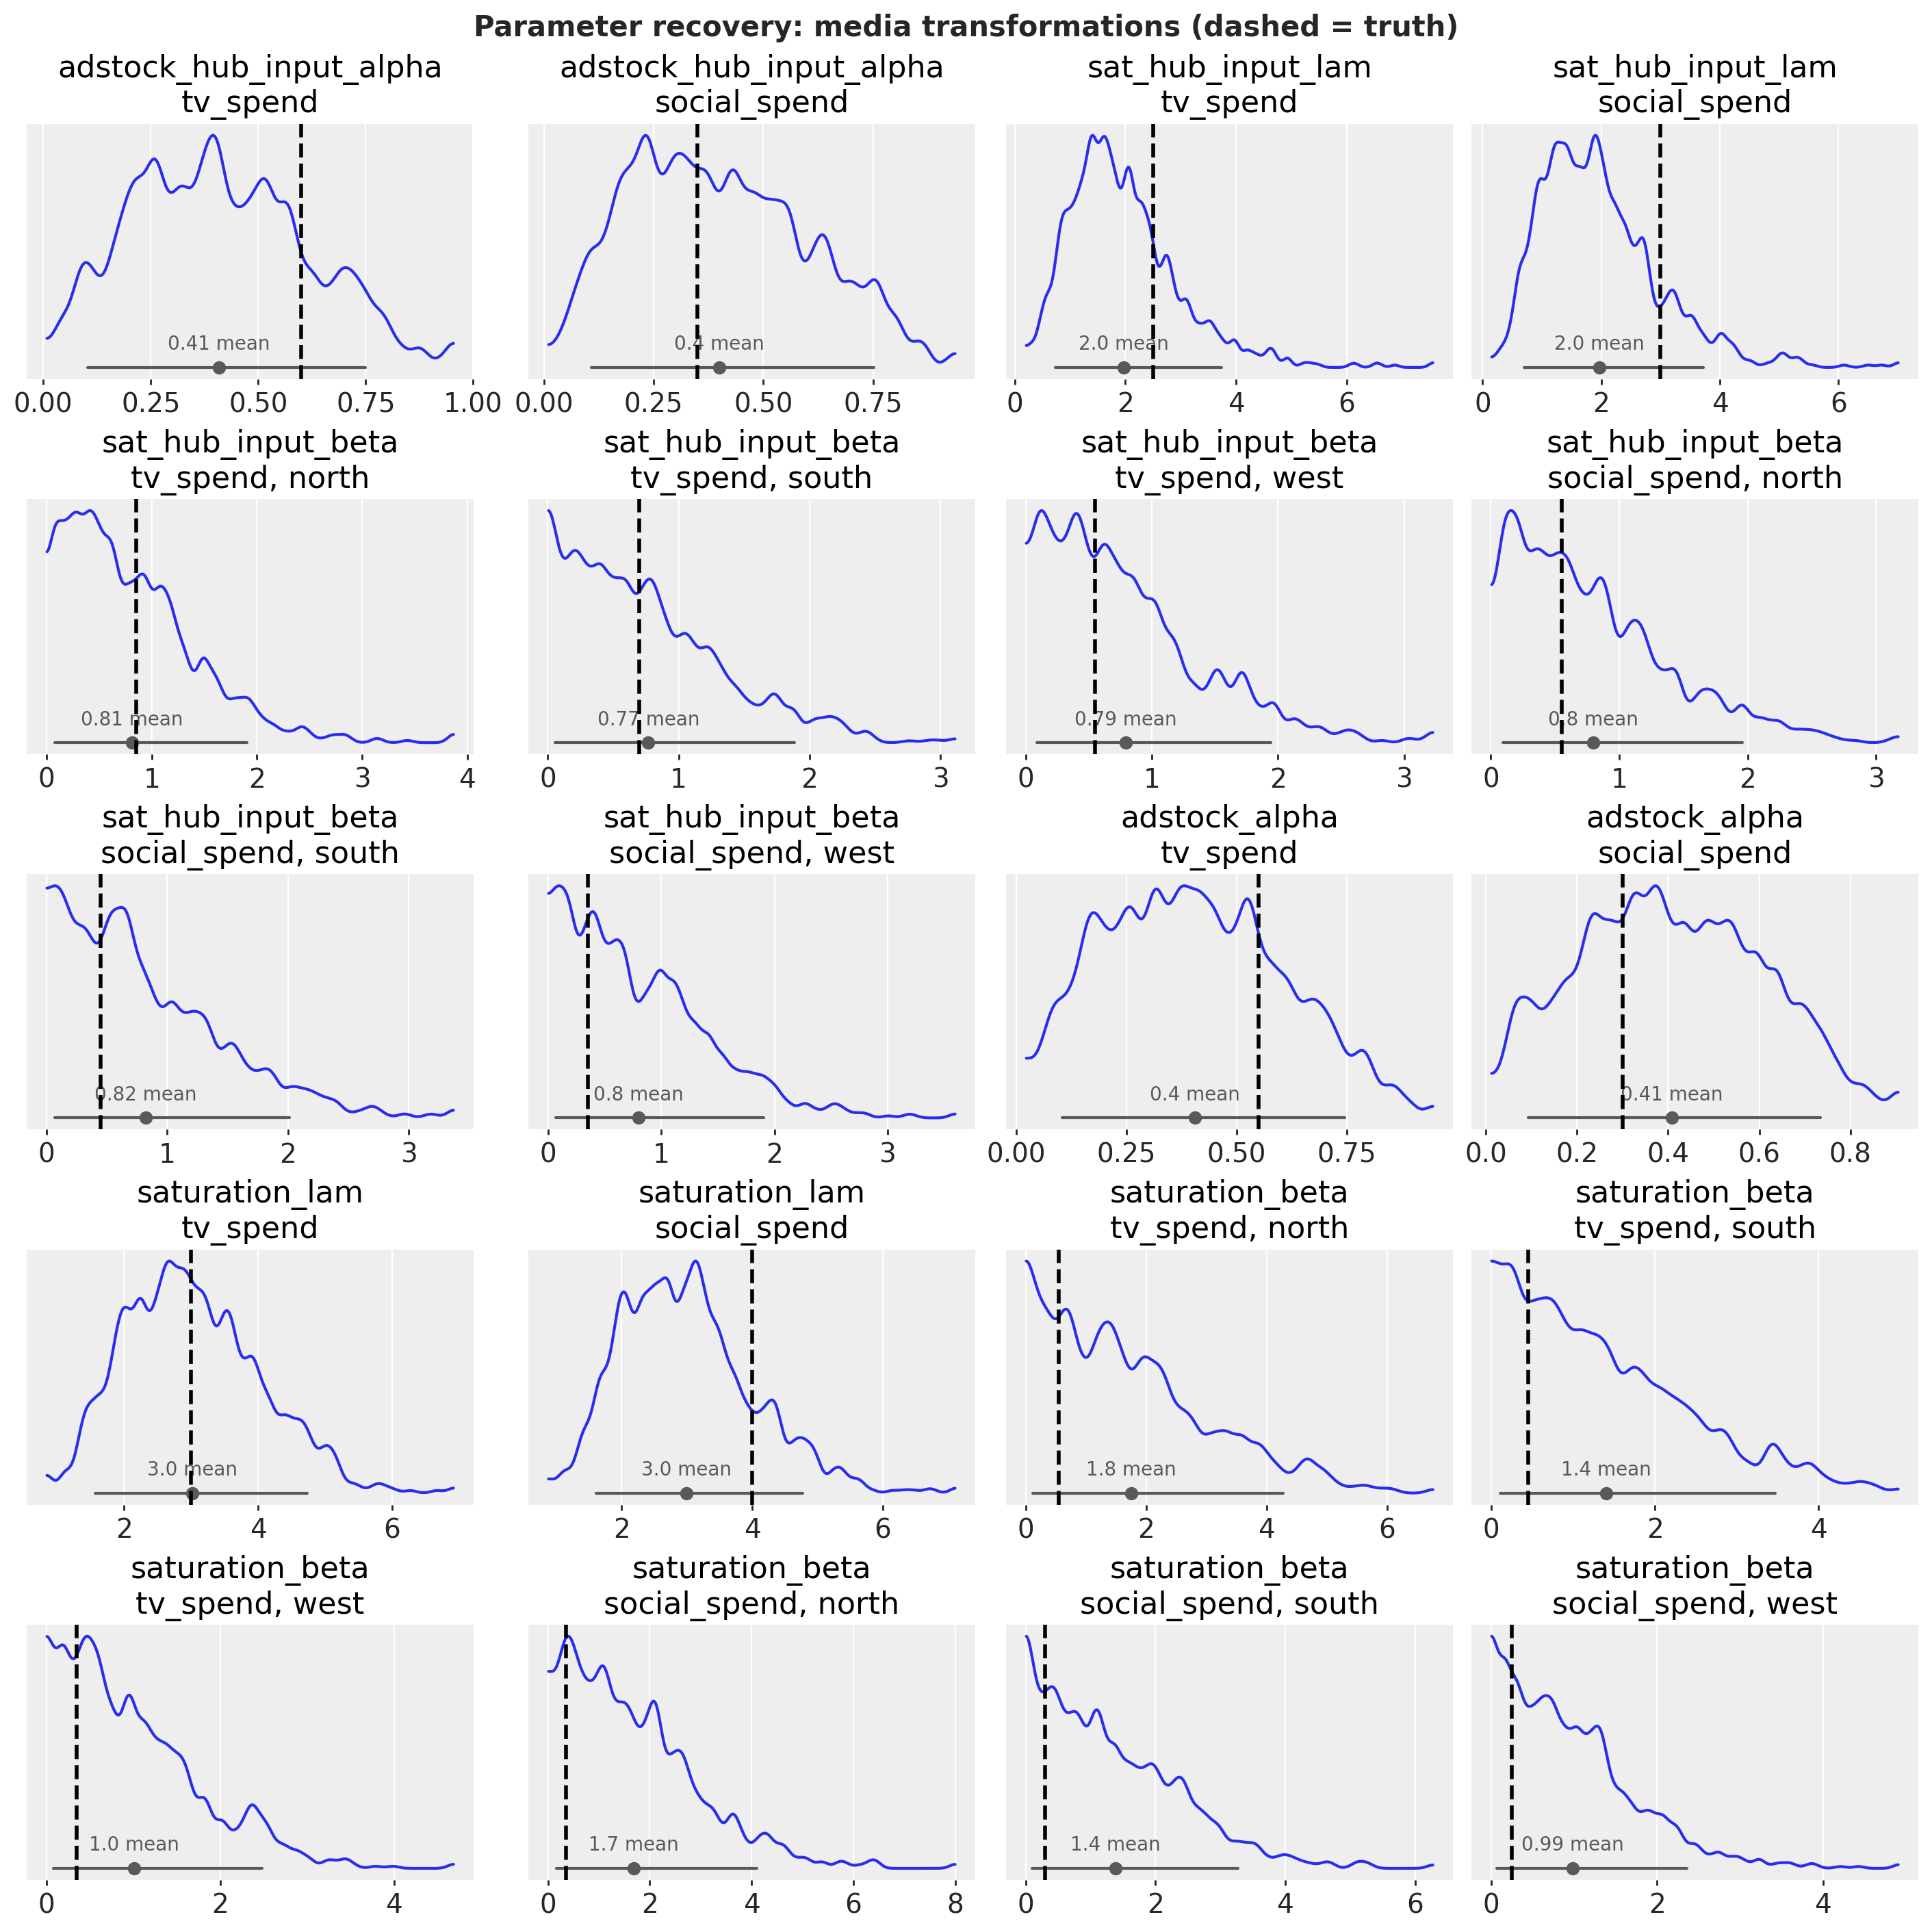

In [48]:
recovery_plot(
    [
        "adstock_hub_input_alpha",
        "sat_hub_input_lam",
        "sat_hub_input_beta",
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    "Parameter recovery: media transformations (dashed = truth)",
    (14, 14),
);

Thirty-seven KDE panels across two figures are good for shapes and bad for checking claims, so here is the same information as numbers (posterior mean, 94% HDI, truth, and whether the interval covers it) for every one of them:

In [49]:
recovery_vars = [
    "budget_dual_baseline",
    "budget_dual_parent_coef",
    "budget_dual_budget_coef",
    "budget_dual_indicator_coef",
    "adstock_contribution_alpha",
    "sat_contribution_lam",
    "sat_contribution_beta",
    "adstock_hub_input_alpha",
    "sat_hub_input_lam",
    "sat_hub_input_beta",
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
]

records = []
for var in recovery_vars:
    draws = posterior_on_true_scale[var]
    truth_da = truth_dataset([var])[var]
    lo, hi = hdi_bounds(draws)
    mean = draws.mean(dim=["chain", "draw"])
    if truth_da.ndim == 0:
        cells = [((), float(truth_da))]
    else:
        cells = [
            (idx, float(truth_da.sel(dict(zip(truth_da.dims, idx, strict=True)))))
            for idx in pd.MultiIndex.from_product(
                [truth_da[d].values for d in truth_da.dims]
            )
        ]
    for idx, truth_value in cells:
        sel = dict(zip(truth_da.dims, idx, strict=True))
        lo_v, hi_v = float(lo.sel(sel)), float(hi.sel(sel))
        records.append(
            {
                "parameter": var,
                "cell": ", ".join(map(str, idx)) or "none",
                "mean": float(mean.sel(sel)),
                "hdi 3%": lo_v,
                "hdi 97%": hi_v,
                "true": truth_value,
                "covered": lo_v <= truth_value <= hi_v,
            }
        )

recovery_table = pd.DataFrame(records).set_index(["parameter", "cell"])
n_covered = int(recovery_table["covered"].sum())
rel_err = (recovery_table["mean"] - recovery_table["true"]).abs() / recovery_table[
    "true"
].abs()
geo_errors = ", ".join(
    f"{_geo} {rel_err[recovery_table.index.get_level_values('cell').str.contains(_geo)].mean():.1%}"
    for _geo in geos
)
recovery_table.style.set_caption(
    f"Recovery: covered {n_covered}/{len(recovery_table)} parameter cells; "
    f"mean relative |error| by geo: {geo_errors}"
).format(
    {"mean": "{:.3f}", "hdi 3%": "{:.3f}", "hdi 97%": "{:.3f}", "true": "{:.3f}"}
).map(
    lambda v: (
        f"background-color: {'#c8e6c9' if v else '#ffcdd2'}"
        if isinstance(v, (bool, np.bool_))
        else ""
    )
)

The direct-path parameters are looser than the funnel-side ones (compare the interval widths in the table above), and for a reason worth naming: both the direct and the indirect path originate at the same upper-funnel spend, so how much of the response belongs to each is only weakly identified parameter by parameter. The trade-offs are not directionless, though. Two patterns are worth carrying forward.

**Channel: the two amplitudes trade off, cell by cell.** The weak identification has a signature, and it is not a tilt in one direction. In **all six** channel-geo cells the demand-path amplitude (`sat_hub_input_beta`) and the direct-path one (`saturation_beta`) miss in *opposite* directions. Social's `south` pair runs -1.6% on the demand path against +45.3% on the direct one; its `west` pair reverses the roles (+35.4% against -0.4%); TV does the same in every geo (`north` -11.4%/+6.9%, `south` +10.7%/-9.8%, `west` -4.4%/+19.7%). That is exactly the seesaw two paths originating at the same spend should produce: the posterior is far better determined about a channel's *total* amplitude than about how that amplitude splits between the paths, which is why the total effects below survive trade-offs this large. It also means the six cells are not six independent misses.

**Geo: `west` is hardest by construction.** The mean relative error in the table's caption climbs monotonically from `north` (13.2%) through `south` (16.8%) to `west` (21.7%). The gradient is built into the DGP: the observation noise `y_sigma` is flat at 0.04 while the target level falls away with the region. Not all of it at the same rate: the media inputs and `category_demand` carry the size multiplier itself (1.0/0.7/0.45), while the level parameters fall more gently (`intercept_contribution` 1/0.80/0.63, `saturation_beta` on TV 1/0.82/0.64). But every component points the same way, so `west` runs the worst signal-to-noise in the panel.

The three cells of 37 that escape their intervals are a separate matter, and they do not follow that gradient: all three (`budget_dual_baseline[north]`, `budget_dual_parent_coef[north]`, `budget_dual_parent_coef[west]`) sit in the demand equation's level block, the two parameters that between them decide how much demand exists before any media touches it. Keep the geo gradient in mind, though, when the bias tables below put the funnel model's weakest cells at social in `south` and `north` and TV in `west`; the first of those is its largest single miss in target units.

As in the basic notebook, what matters for a decision is the **total** effect, and that survives these trade-offs largely intact, as we see next.


## Direct, indirect, and total effect per channel

We now reconstruct each channel's estimated decomposition. The direct path is the base channel contribution. The indirect path is the mediated contribution **minus** what it would be with that channel's spend set to zero: the same counterfactual we ran on the generative model, now on the posterior.

This hand-rolled counterfactual is exactly the computation the incrementality module automates in the ROAS section below (the effect opted in through `incrementality_spec`), so building it once by hand shows what the module's number *is* -- and it additionally yields the induced lower-funnel spend $\Delta M^{*}$, which the module has no reason to report: its increment is in target units, while the induced spend is a spend series.


In [50]:
def counterfactual_indirect(channel: str) -> dict[str, xr.DataArray]:
    """Posterior mediated contribution and induced LF spend attributable to ``channel``."""
    X_zero = X_upper.copy()
    X_zero[channel] = 0.0
    cf = funnel.sample_posterior_predictive(
        X_zero,
        extend_idata=False,
        combined=False,
        var_names=[
            "budget_dual_effect_contribution_original_scale",
            "budget_dual_spend",
        ],
        random_seed=rng,
    )
    factual = funnel.idata.posterior["budget_dual_effect_contribution_original_scale"]
    counterfactual = cf["budget_dual_effect_contribution_original_scale"]
    # Guard the plumbing: when X is a DataFrame the conversion keeps only the channel
    # columns, so the effect's own data variables (including lf_budget) correctly
    # retain their training values. If that ever stopped holding, the mediated
    # contribution would not move and the indirect effect would silently read zero.
    if float(counterfactual.mean()) >= float(factual.mean()):
        raise RuntimeError(
            f"zeroing {channel} did not reduce the mediated contribution: "
            "the effect's data variables were probably overwritten"
        )
    return {
        "indirect": factual - counterfactual,
        # M* with the channel on minus M* with it off: the lower-funnel spend the
        # channel *induces*. Same units as observed lower_spend (the likelihood
        # ties them), which is what lets it enter a ROAS denominator later.
        "induced_spend": (
            funnel.idata.posterior["budget_dual_spend"] - cf["budget_dual_spend"]
        ),
    }


counterfactuals = {channel: counterfactual_indirect(channel) for channel in channels}

direct_post = funnel.idata.posterior["channel_contribution_original_scale"]
indirect_post = xr.concat(
    [counterfactuals[channel]["indirect"] for channel in channels],
    dim=pd.Index(channels, name="channel"),
)
induced_spend_post = xr.concat(
    [counterfactuals[channel]["induced_spend"] for channel in channels],
    dim=pd.Index(channels, name="channel"),
)
total_post = direct_post + indirect_post

Sampling: []


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling: []


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/.venv/lib/python3.12/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

min component: 0.03446375070322662


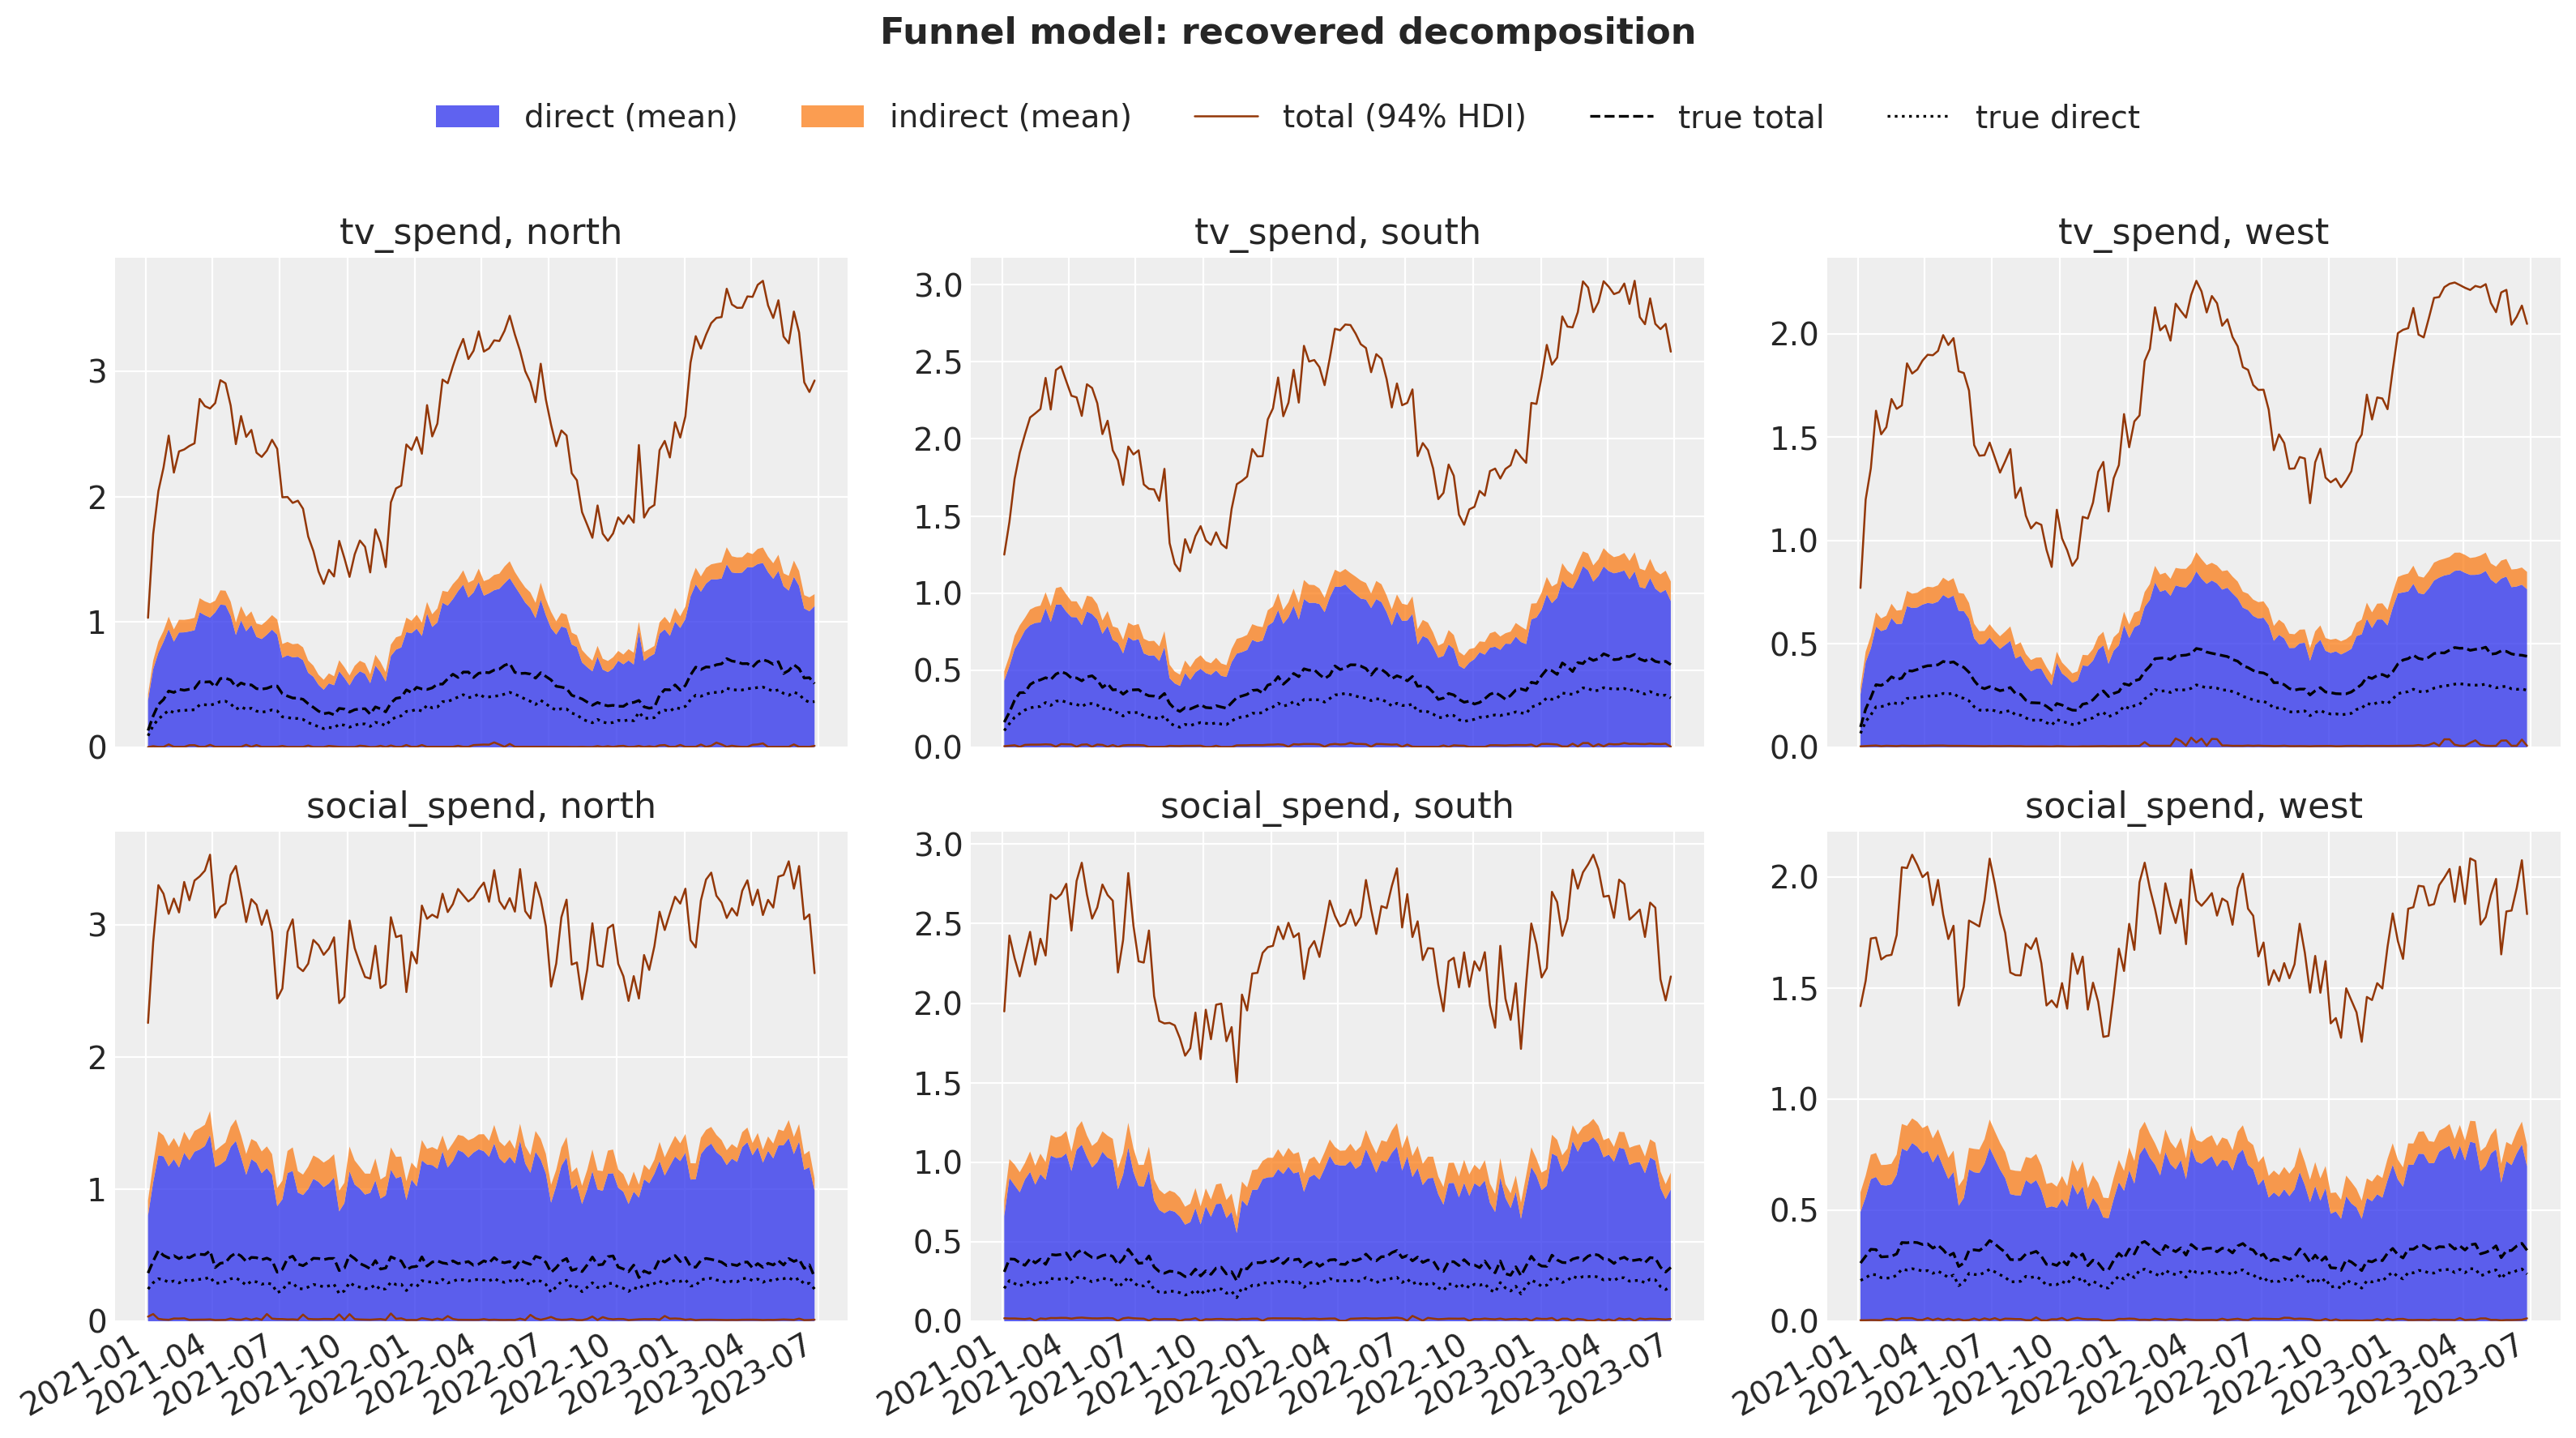

In [51]:
direct_mean = direct_post.mean(dim=["chain", "draw"])
indirect_mean = indirect_post.mean(dim=["chain", "draw"])
# `stackplot` silently draws overlapping polygons if a component is negative;
# both are non-negative here (monotone saturation, non-negative adstock), but check.
print("min component:", float(min(direct_mean.min(), indirect_mean.min())))

fig, axes = plt.subplots(
    nrows=len(channels), ncols=len(geos), figsize=(16, 9), sharex=True
)
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        ax.stackplot(
            date_range,
            direct_mean.sel(sel),
            indirect_mean.sel(sel),
            labels=["direct (mean)", "indirect (mean)"],
            colors=["C0", "C1"],
            alpha=0.75,
        )
        lo, hi = hdi_bounds(total_post.sel(sel))
        ax.plot(date_range, lo, color="C4", lw=0.9, label="total (94% HDI)")
        ax.plot(date_range, hi, color="C4", lw=0.9)
        ax.plot(
            date_range,
            data["total_true"].sel(sel),
            color="black",
            linestyle="--",
            lw=1.2,
            label="true total",
        )
        ax.plot(
            date_range,
            data["direct_true"].sel(sel),
            color="black",
            linestyle=":",
            lw=1.2,
            label="true direct",
        )
        ax.set_title(f"{channel}, {geo}")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=5)
fig.suptitle("Funnel model: recovered decomposition", fontsize=16, fontweight="bold")
fig.autofmt_xdate()
fig.set_layout_engine("tight", rect=(0, 0, 1, 0.9))

The stack edge is a posterior *mean* while the two thin lines bracket a 94% HDI of the same total (drawn as lines rather than as a filled band, which would tint the stack underneath). They are different summaries of one quantity, so the edge need not sit midway between them. The point of the figure is the split: how much of each channel's contribution travels directly versus through lower-funnel spend, against the two black reference lines.

## Head-to-head: the bias from ignoring the funnel

```{important}
**Where this lands.** Every mediator-blind model pays for the funnel it cannot see, and the bill differs by channel. `Naive B (mediator omitted)` overstates TV through the shared growth trend. `Naive B++ (trend as control)` repairs TV and misallocates onto social instead. `Naive A (mediator as channel)` is not so much wrong as answering the *direct*-effect question, so it is scored against both benchmarks below.
```

Finally we compare the six models on the quantity a budget decision actually turns on: the **total contribution of each upper-funnel channel**. For the naive models the channel contribution is already the counterfactual versus zero spend. For the funnel model we use direct plus the counterfactual indirect effect.

The rows are grouped **by estimand**, following the d-separation analysis: the models above the separator answer (or claim to answer) the total-effect question; `Naive A (mediator as channel)` sits below it with the funnel model's direct path, because the direct effect is the question it actually answers. Every bias annotation names its benchmark.

The figure is a forest plot of means and intervals against the true values, and the ROAS comparison further down wants exactly the same panel, so we write it once:


In [52]:
FOREST_COLORS = ["C2", "C4", "C5", "C6", "C8", "C3", "C0", "C1"]


def forest_panel(ax, rows, reference=None, benchmarks=None, annotate=True):
    """Draw one mean-and-HDI interval per row, with optional reference lines.

    ``rows`` maps a label to a posterior ``DataArray``. ``reference`` maps a
    benchmark name to ``(value, style)`` and is drawn as a full-height vertical
    line. ``benchmarks`` maps a row label to the benchmark its bias annotation is
    measured against (default: the first ``reference`` entry); the annotation
    names its benchmark so the same figure can mix estimands without ambiguity.
    """
    labels = list(rows)
    benchmarks = benchmarks or {}
    for i, label in enumerate(labels):
        draws = rows[label]
        lo, hi = hdi_bounds(draws)
        mean = float(draws.mean())
        color = FOREST_COLORS[i % len(FOREST_COLORS)]
        ax.plot([float(lo), float(hi)], [i, i], color=color, lw=3.5, alpha=0.65)
        ax.plot([mean], [i], "o", color=color, ms=9)
        if annotate and reference:
            key = benchmarks.get(label, next(iter(reference)))
            benchmark = reference[key][0]
            ax.annotate(
                f"{mean / benchmark - 1:+.0%} vs {key}",
                (mean, i),
                textcoords="offset points",
                xytext=(0, -15),
                ha="center",
                va="top",
                fontsize=8,
                bbox={
                    "boxstyle": "round,pad=0.15",
                    "fc": "white",
                    "ec": "none",
                    "alpha": 0.75,
                },
            )
    for name, (value, style) in (reference or {}).items():
        ax.axvline(value, label=f"true {name}", **style)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_ylim(-0.7, len(labels) - 0.3)
    ax.invert_yaxis()


TRUE_STYLE = {
    "total": {"color": "black", "linestyle": "--", "linewidth": 2},
    "direct": {"color": "gray", "linestyle": ":", "linewidth": 2},
}

In [53]:
def total_contribution(model: MMM, channel: str) -> xr.DataArray:
    """Mean-over-time total contribution of ``channel`` for a naive model."""
    return (
        model.idata.posterior["channel_contribution_original_scale"]
        .sel(channel=channel)
        .mean(dim="date")
    )


estimates = {
    "Naive B (mediator omitted)": lambda ch: total_contribution(naive_b, ch),
    "Naive B+ (demand as control)": lambda ch: total_contribution(naive_bplus, ch),
    "Naive B++ (trend as control)": lambda ch: total_contribution(naive_bpp, ch),
    "Naive C (indicator as channel)": lambda ch: total_contribution(naive_c, ch),
    "Funnel (total)": lambda ch: total_post.sel(channel=ch).mean(dim="date"),
    "Naive A (mediator as channel)": lambda ch: total_contribution(naive_a, ch),
    "Funnel (direct only)": lambda ch: direct_post.sel(channel=ch).mean(dim="date"),
}
CONTRIBUTION_BENCHMARKS = {
    "Naive A (mediator as channel)": "direct",
    "Funnel (direct only)": "direct",
}

truth_mean = data["total_true"].mean("date")
direct_truth_mean = data["direct_true"].mean("date")

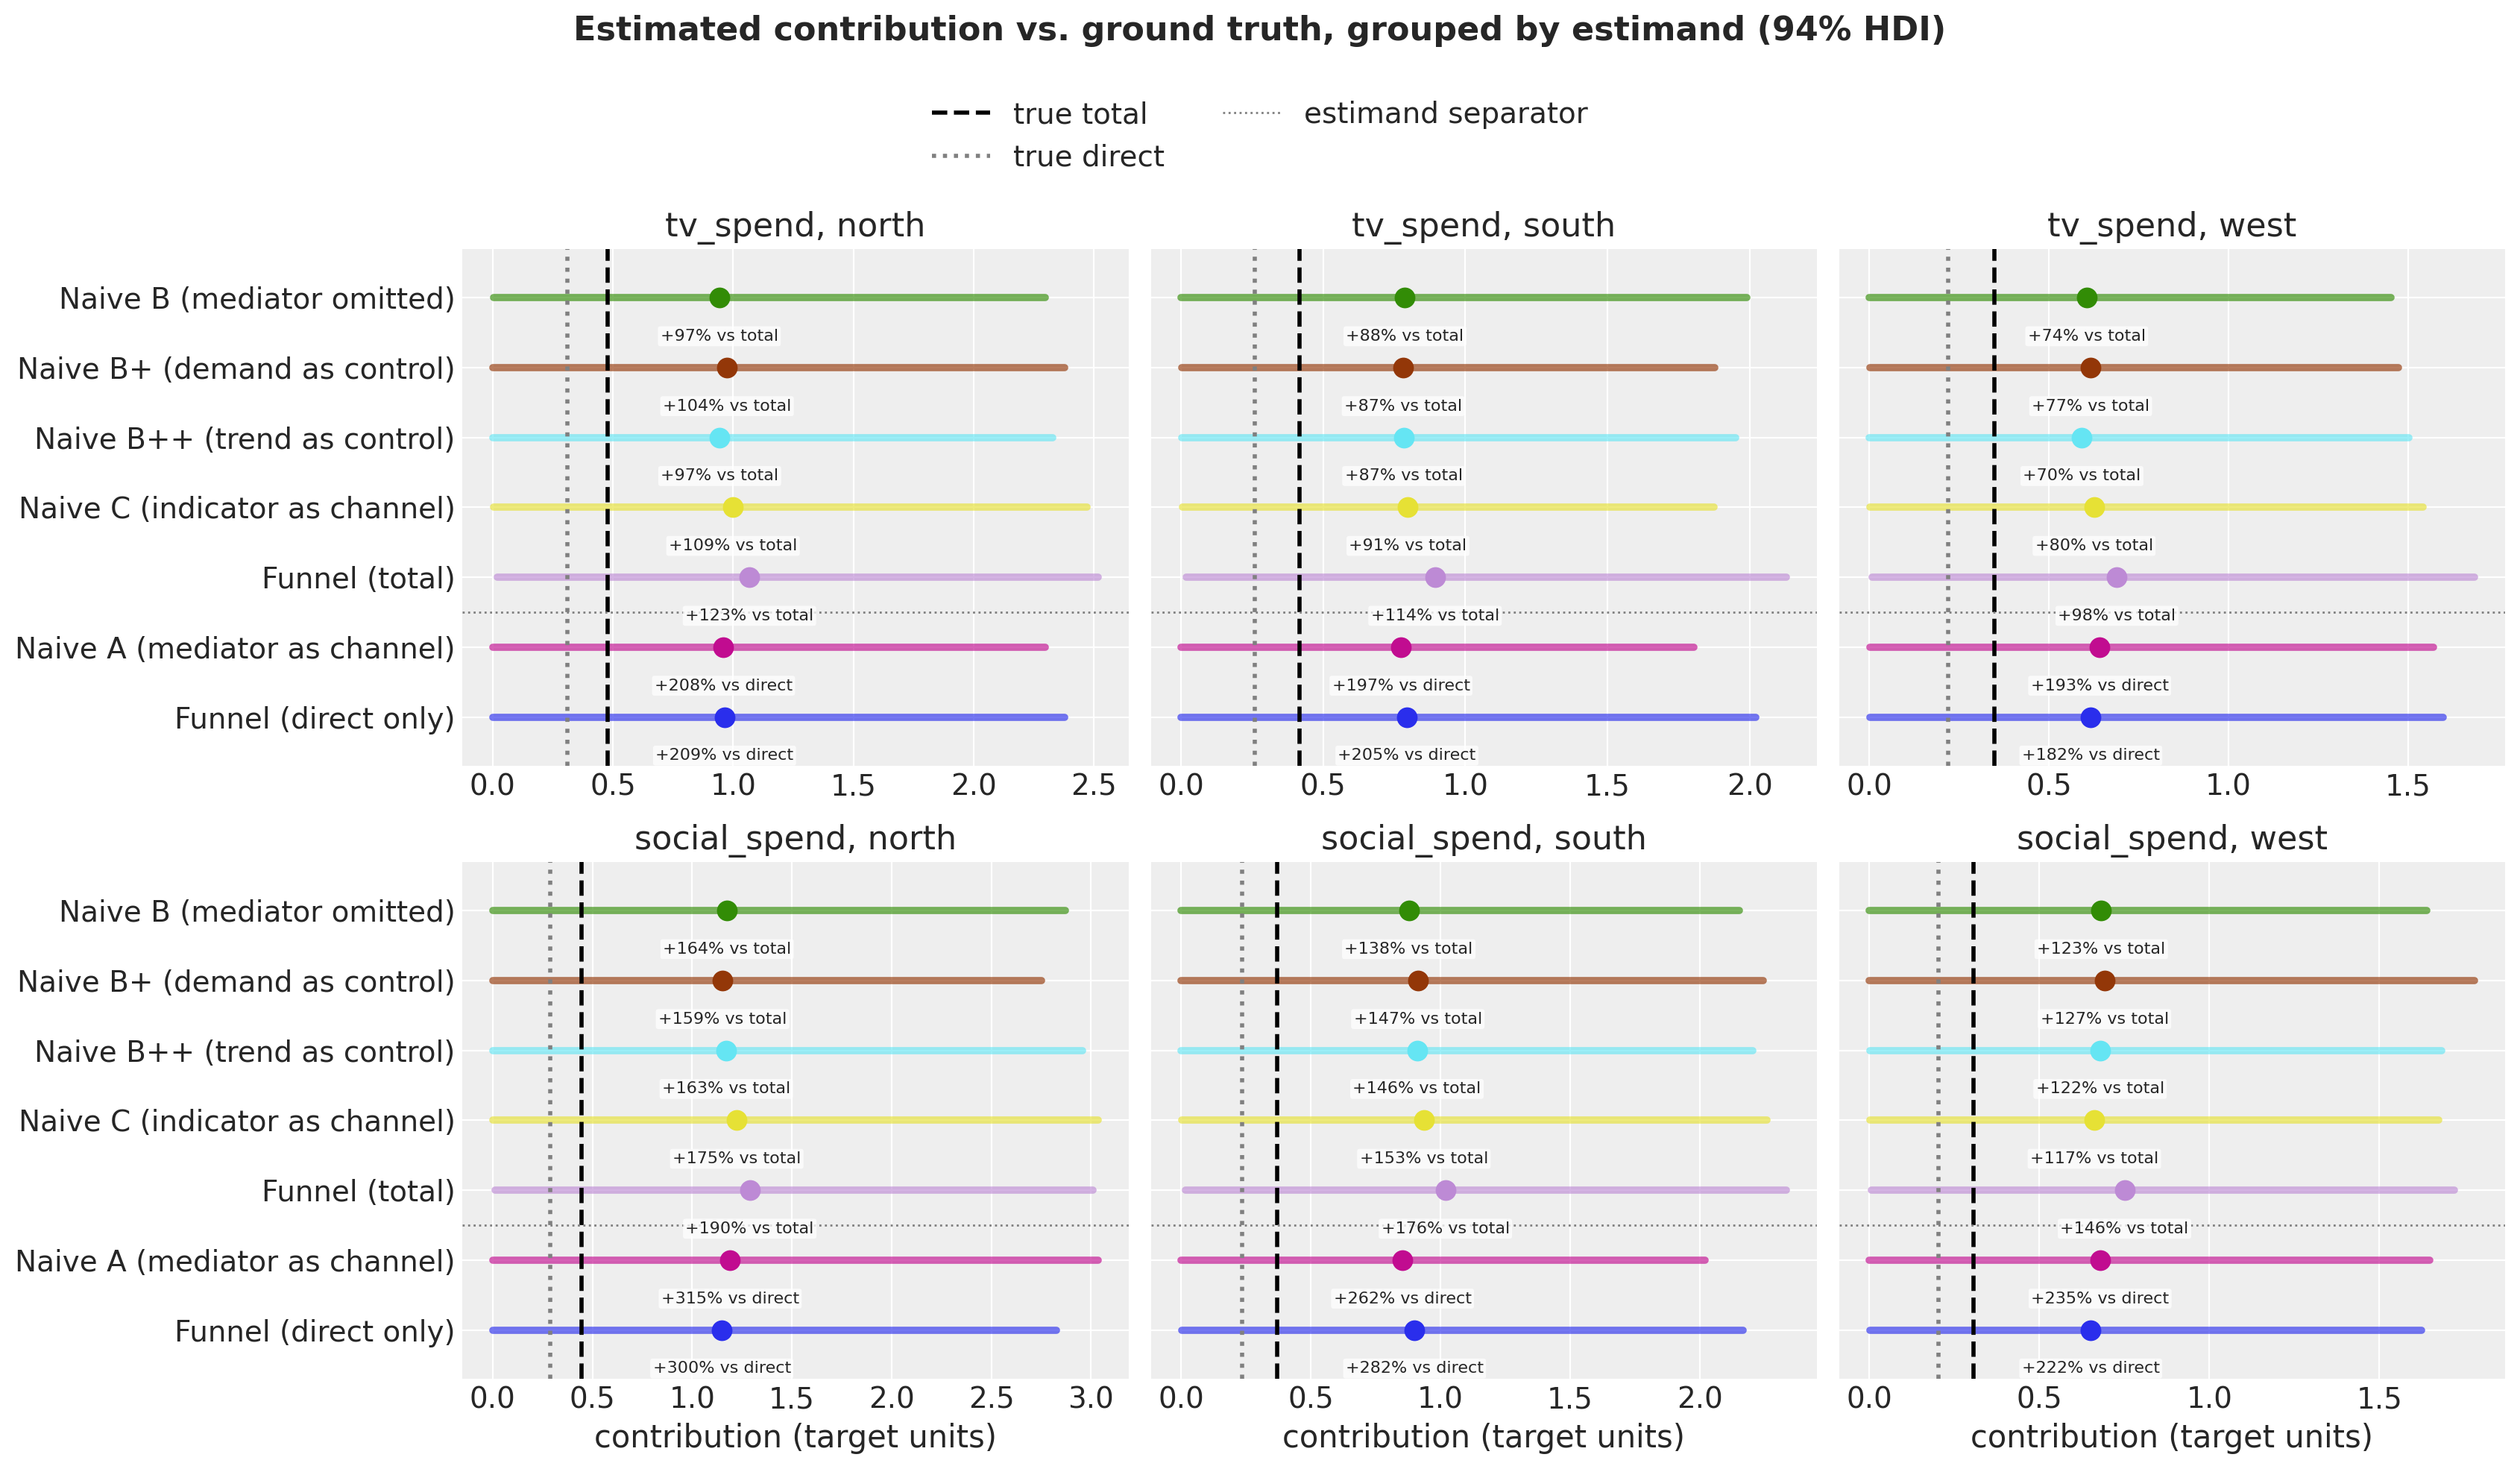

In [54]:
fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(17, 10))
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        forest_panel(
            ax,
            {label: est(channel).sel(geo=geo) for label, est in estimates.items()},
            reference={
                "total": (float(truth_mean.sel(sel)), TRUE_STYLE["total"]),
                "direct": (float(direct_truth_mean.sel(sel)), TRUE_STYLE["direct"]),
            },
            benchmarks=CONTRIBUTION_BENCHMARKS,
        )
        # Estimand separator, derived from the row count so adding a row
        # cannot silently leave the line in the wrong place.
        ax.axhline(
            len(estimates) - 2.5,
            color="gray",
            linestyle=":",
            lw=1,
            label="estimand separator",
        )
        ax.set_title(f"{channel}, {geo}")
        ax.tick_params(labelleft=col == 0)
        if row == len(channels) - 1:
            ax.set_xlabel("contribution (target units)")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=2)
fig.suptitle(
    "Estimated contribution vs. ground truth, grouped by estimand (94% HDI)",
    fontsize=16,
    fontweight="bold",
)
fig.set_layout_engine("tight", rect=(0, 0, 1, 0.9))

Each verdict from the d-separation table now has an empirical face, and the two channels put two different failure mechanisms on display.

**`Naive B (mediator omitted)` overstates TV, and the trend is why.** TV, the channel whose residual correlation with category demand survived the seasonal projection at +0.63 to +0.67, comes out overstated in every geo (+15.9% to +30.8%). This is textbook confounding: trending category demand, routed through the mediator into the target, credited to the one regressor that also trends.

**Both candidate fixes do repair TV, and the graph's ranking of them is inverted.** `Naive B++ (trend as control)` conditions on the trend itself, exactly where the graph put one of the two forks, and its TV estimates land within a few points of the truth, just past it on the other side (-7.4% to -2.5%). `Naive B+ (demand as control)` conditions downstream on the category index (the specification the graph nominated, because it blocks the noise fork too) and recovers only part of the same correction (TV at +7.7% to +19.9%, and in `west` it nudges TV slightly further out rather than back).

So the adjustment set with the *weaker* formal credential does the better empirical job here: its linear control competes with the flexible response curves for the same variance, and, as the arithmetic below shows, a trend the curves cannot mimic is won more decisively than a category index they can. Graph validity ranks specifications only up to functional form; it never promised more.

**Social is the twist: wildly overstated by Naive B in two geos (+91.0% in `south`, +35.9% in `west`) against a near-exact -2.4% in `north`, and both fixes make it *worse* on average (mean |error| 43.1% to 50.3% and 53.4%).** Social's backdoor is graphically open, exactly like TV's ($t \to U_2$ is in the graph, and the symmetry check above says the verdicts are identical with social as the treatment), but it is numerically immaterial: its residual correlation with demand was at noise level ($|r| \le 0.12$) before any fix was applied.

That is a statement about the two *observable* strands, and worth keeping separate from the third: on this draw the drivers' shared noise is essentially a social-side phenomenon (pooled -0.126 on social against +0.007 on TV, and `north` social, at -0.180, is the biggest entry in that table). "On this draw" is doing real work in that sentence: the claims around it are design properties, but which channel the unobservable strand lands harder on is exactly the kind of number the floor discussion said a redraw reshuffles, sign included. It cannot be what inflates social, because the sign is wrong (a negative confounding correlation does not manufacture a positive bias), but here the strand no regressor spans is, on this channel, the larger one.

So social's overstatement is not confounding in any quantitative sense. It is the **omitted mediated path**: the demand pool that upper-funnel spend fills is missing from every naive model, so its contribution has to land somewhere, and it lands disproportionately on social. *Why* it prefers social is a claim about where the likelihood puts the mass, so we price it in target units below rather than leave it as an assertion. No adjustment set can address the misallocation: no backdoor an adjustment set could reach is material here, and the one it cannot reach points the other way. What is left is the model family, which simply cannot represent one shared saturating pool as a sum of per-channel curves. D-separation speaks about which variables you need, never about how they must enter; and, being binary, it cannot tell you that one open backdoor is worth 0.65 and the other 0.1.

So the graph's guess from the correlation table was half right. The bias the graph could see *and* the measurement said was material (TV's open backdoor) did land on TV, and adjustment removed it. The larger bias landed on the channel whose backdoor was numerically empty, and adjustment could not touch it.

**Naive C sits between Naive A and Naive B, and inherits from both.** Branded search is a near-perfect proxy for latent demand, so conditioning on it blocks the mediated path the way `Naive A` does, but only partially, while leaving TV's backdoor as wide open as `Naive B` does. The two pull opposite ways, and on TV they settle into a near-uniform +11.1% to +13.3%, averaging almost exactly half of B's +23.3%: the partial block gives back about half of B's inflation and no more. That column is the tidy part. Social is where the leftover lands, and it swings from -19.2% in `north` through +24.5% in `west` to +69.9% in `south`, changing sign on the way. A model whose error is a constant on one channel and a sign-changing spread on the other is arguably more dangerous than one that is wrong the same way everywhere: the tidy column invites exactly the correction factor the other column would defeat.

**Naive A, read against its own estimand, is a different model.** Against the total effect it understates TV badly: the blocked indirect path. Against the true *direct* effect (the dotted line, its annotation benchmark below the separator) it covers five of six cells, though with a mean error near 34%: a *rough* direct-effect estimator, not a clean one; the d-separation analysis said as much, since it conditions on the noisy observation $M$ rather than the structural $M^{*}$. The lesson is not "Naive A is broken" but "Naive A answers a question nobody asked it, and answers it only approximately".

A third thing sits in the picture, not a separable contributor, as the absolute-bias section below shows, but with a structural half and a draw half: the direct-versus-mediated trade-off the recovery table found in the funnel model's own posterior. The structural half was named when that table was read: both paths originate at the same upper-funnel spend, so how the response splits between them is only weakly identified, and that weak identification is what leaves room for a sizeable per-cell residual on *any* draw. Which cells it lands on, and how hard, is the draw's half. It is not a specification failure, and no conditioning choice removes it; the funnel model has the right structure and still carries it.

Whether the naive models carry the *same* trade-off is a separate question, and the honest answer is that nothing here settles it. The absolute-bias section below reaches for the one ruler that could place a single model's carryover on a direct-to-mediated ladder, and finds the ladder narrower than the interval it would have to be read against, so neither a subtraction nor a floor is licensed. That is why the section keeps the funnel model's residual only as a reference point for what a right-structure model still carries.

None of these biases is a uniform shift you could correct with a fudge factor, and the two mechanisms respond to *different* remedies: one to a control column, the other only to modelling the funnel. We quantify all of it below, where a single number per model replaces eyeballing these intervals.

The claim that Naive B+'s control wins only part of the shared trend variance deserves its arithmetic:


**What should these coefficients be?** In the true DGP a sustained +1 in category demand raises latent demand by $\gamma_g$, hence $M^{*}$ by $\gamma_g$ (the geometric adstock is normalized, so a sustained shift passes through with total weight one), and the target by $\gamma_g$ times the slope of the true conversion curve at its operating point. `LogisticSaturation` is $\beta \tanh(\lambda x / 2)$, so that slope is $\beta\,(\lambda/2)/\cosh^{2}(\lambda x / 2)$, averaged pointwise over the adstocked $M^{*}$ series.

`Naive B++`'s control is the calendar trend itself, so its anchor runs one step further back: a sustained +1 in $t$ raises the category index by its trend loading times the softplus derivative, times the Jacobian of the index's rescaling. It then reaches the target through the identical demand $\to M^{*} \to$ conversion chain, under the same mean-of-slope convention, so the two anchors are comparable.

```{note}
Two caveats on the anchors. The normalized adstock passes a sustained shift through with total weight one only from week `l_max` on; the zero-padded start passes slightly less, worth under half a percent here. And averaging the pointwise slope gives the mean of the slope, not the slope at the mean (no Jensen gap), but it is still not the regression's own estimand, which weights the slope by where the variance sits: same order of magnitude, not the identical number.
```


In [55]:
adstock_weights = np.power(
    true["adstock_contribution_alpha"][None, :], np.arange(l_max)[:, None]
)
adstock_weights /= adstock_weights.sum(axis=0)
mstar = data["lf_spend_true"].transpose("date", "geo").to_numpy()
adstocked_mstar = np.stack(
    [
        np.convolve(mstar[:, g], adstock_weights[:, g])[: len(mstar)]
        for g in range(len(geos))
    ],
    axis=1,
)
lam_lf = float(true["sat_contribution_lam"])
pointwise_slope = (
    true["sat_contribution_beta"]
    * (lam_lf / 2)
    / np.cosh(lam_lf * adstocked_mstar / 2) ** 2
)
conversion_slope = pointwise_slope.mean(axis=0)

# The softplus derivative is recovered as 1 - exp(-softplus_output), on the
# index with the geo rescaling undone, the same division the noise cell
# applies before inverting.
softplus_out = x_data[..., 2] / geo_size[None, :]
softplus_slope = (1.0 - np.exp(-softplus_out)).mean(axis=0) * (
    geo_size / x_data[..., 2].max()
)
implied_slopes = {
    "Naive B+": true["budget_dual_parent_coef"] * conversion_slope,
    "Naive B++": true["budget_dual_parent_coef"]
    * trend[drivers.index("category_demand")]
    * softplus_slope
    * conversion_slope,
}
control_of = {
    "Naive B+": (naive_bplus, "category_demand"),
    "Naive B++": (naive_bpp, "t"),
}

In [56]:
# The default control prior is Normal(0, 2) on the *scaled* target, so its sd in
# the original units the implied slope lives in is 2 * target_scale.
control_blocks = {}
for control_label, (control_model, control_name) in control_of.items():
    control_scale = control_model.idata.constant_data["target_scale"]
    gamma_scaled = (
        control_model.idata.posterior["gamma_control"].sel(control=control_name)
        * control_scale
    )
    post_mean = gamma_scaled.mean(dim=["chain", "draw"]).to_series()
    post_sd = gamma_scaled.std(dim=["chain", "draw"]).to_series()
    implied = pd.Series(implied_slopes[control_label], index=pd.Index(geos, name="geo"))
    prior_sd = (2.0 * control_scale).to_series()
    control_blocks[control_label] = pd.DataFrame(
        {
            "posterior mean (target scale)": post_mean,
            "implied true slope": implied,
            "posterior sd (target scale)": post_sd,
            "sd from implied": (post_mean - implied).abs() / post_sd,
            "sd from zero": post_mean.abs() / post_sd,
            "prior sd (target scale)": prior_sd,
            "prior sd / implied": prior_sd / implied,
        }
    )
summary = pd.concat(control_blocks, names=["model"])
summary.style.format(
    {col: "{:.3f}" for col in summary.columns} | {"prior sd / implied": "{:.0f}x"}
)

The arithmetic explains why `Naive B+` recovers only part of TV's correction. The *correct* linear effect of a unit of category demand on the target is small (about a tenth of a unit, the implied-slope column) because a unit of demand converts through the saturating lower-funnel curve. The posterior means scatter around that implied slope rather than tracking it: above it in `north` and `south`, well below it in `west`, though each lands within about one posterior sd of the anchor. The sd-from-zero column is the honest one. Two of the three cells sit more than two posterior sds from zero, so the control is doing measurable work there, while `west`'s sits a fifth of an sd away, which is a control the data cannot tell apart from an omitted column. At this sample size the diagnostic cannot distinguish a control doing its full job from one doing half of it, or, in `west`, from one doing nothing.

(This is also why we do not read the posterior-to-prior shrinkage as strength here the way we did for $\lambda$. The default $\mathrm{Normal}(0, 2)$ control prior lives on the *scaled* target, so the comparison has to be made in one currency: in original units its sd is $2 \cdot \texttt{target\_scale}$, tens of times wider than the implied slope, `Naive B+`'s rows of the last column above. A posterior that has shrunk to a few percent of *that* is still wide relative to the number it is trying to measure.)

`Naive B++`'s rows tell the complementary story, and they are why the inversion has a mechanism rather than a moral. Its implied slope is smaller still (the anchor chains through the category index's trend loading, the softplus derivative, and the Jacobian of the index's rescaling), and its posterior means sit far *above* that anchor in all three geos (0.145, 0.095 and 0.058 against 0.031, 0.022 and 0.012: four to five times the demand-path prediction), with posterior sds between about two thirds and a quarter of `Naive B+`'s. A linear column in $t$ wins the trend strand outright (more than the demand-path anchor alone predicts, consistent with it also absorbing trend co-movement the response curves cannot bend to mimic), while the category index, competing with those same curves for shared variance, recovers only part of its own slope. That is the asymmetry the adjustment section promised as arithmetic.

The fit resolves what the coefficient alone cannot. The control and the flexible TV response curve compete for the same trend variance; the posterior splits it between them, and in `north` and `south` B+'s TV estimates land part of the way from Naive B's toward Naive B++'s (+30.8% to +19.9% to -5.4%, and +23.1% to +7.7% to -7.4%). In `west`, where the control's coefficient sits a fifth of a posterior sd from zero, B+ barely moves at all, and what movement there is goes the wrong way (+15.9% to +18.9%): the same story told in a single cell. The trend control in B++ wins the same contest more decisively (a curve has to *bend* to mimic a trend, while $t$ enters linearly), which is why the cheaper, only-conditionally-valid fix closes TV's gap more fully than the one the graph nominated. Both observations say the same thing: a formally valid control can be estimated about right and still be under-deployed, because validity says nothing about how strongly the likelihood will lean on a linear term when nonlinear alternatives can partially mimic it. What neither control touches, as the tables below quantify, is the social side, where the backdoor was open on the graph but empty in the measurement, so there was no material confounding for either of them to remove.


## ROAS, nationally and per geo

```{important}
**Where this lands.** The ROAS ordering reproduces the contribution ordering above; what is new here is the **denominator**. Upper-funnel activity induces lower-funnel spend that someone has to authorise, and only a model that sees the funnel can price it, so `Funnel (total)` and the induced-spend row answer two different budget questions.
```

Budget decisions key off return on ad spend, so let us express the same comparison that way. All estimates use the **same** definition (contribution summed over the observed weeks, divided by spend over those same weeks) so that any difference between them is structural rather than definitional.

One convention needs naming before any number is read. The standard rows below divide by **upper-funnel spend alone**: they report return per upper-funnel dollar, *treating the lower-funnel spend that upper-funnel activity induces as free*. That is not an innocent choice here: the coefficient on $D$ in the $M^{*}$ equation is exactly one, so every unit of demand a channel creates is a unit of incremental lower-funnel spend someone has to authorise, and with roughly a third of each channel's effect travelling that path it is not a rounding issue either. The funnel model is the only one that can *price* that induced spend, so alongside `Funnel (total)` we also report a row that adds it to the denominator: $\Delta y \,/\, (\text{channel spend} + \Delta M^{*})$.

One bookkeeping assumption underlies that row: all spend series are denominated in the **same currency**, so upper-funnel dollars and induced lower-funnel dollars can be added in one denominator. On real data that is automatic. In this synthetic DGP the "exchange rate" between a TV unit and a lower-funnel unit is set by each series' max-normalization (exactly as arbitrary as it sounds), so read the induced-spend row as a demonstration of the *accounting*, not of a meaningful price.


In [57]:
spend = data[channels].to_array("channel").sum("date")


def incrementality_roas(model: MMM) -> xr.DataArray:
    """All-time ROAS via the incrementality module's spend counterfactual.

    For a model whose effects opted in, this is the total effect.
    """
    return model.incrementality.contribution_over_spend(frequency="all_time").sel(
        channel=channels
    )


def roas_from(contribution: xr.DataArray) -> xr.DataArray:
    """All-time ROAS: summed contribution over summed spend, per channel and geo."""
    return contribution.sel(channel=channels).sum(dim="date") / spend


# Denominator including each channel's induced lower-funnel spend. The denominator
# is itself a posterior quantity: the model estimates how much M* the channel moved.
denom_incl = spend + induced_spend_post.sum(dim="date")

# `BudgetDualIndicatorEffect` opted in through `incrementality_spec`, so for the funnel model
# the built-in follows the spend counterfactual down both paths and returns the
# total (direct + mediated). The direct-only row is assembled from the posterior
# channel contributions instead, and only the induced-spend denominator still
# needs the manual counterfactual: the module's increment is in target units,
# while the induced spend is a spend series it does not report.
roas = {
    "Naive B (mediator omitted)": incrementality_roas(naive_b),
    "Naive B+ (demand as control)": incrementality_roas(naive_bplus),
    "Naive B++ (trend as control)": incrementality_roas(naive_bpp),
    "Naive C (indicator as channel)": incrementality_roas(naive_c),
    "Funnel (total)": incrementality_roas(funnel),
    "Funnel (total / all incremental spend)": (
        total_post.sel(channel=channels).sum(dim="date") / denom_incl
    ),
    "Naive A (mediator as channel)": incrementality_roas(naive_a),
    "Funnel (direct only)": roas_from(
        funnel.idata.posterior["channel_contribution_original_scale"]
    ),
}
ROAS_BENCHMARKS = {
    "Funnel (total / all incremental spend)": "total incl. LF",
    "Naive A (mediator as channel)": "direct",
    "Funnel (direct only)": "direct",
}

true_total_roas = data["total_true"].sum("date") / spend
true_direct_roas = data["direct_true"].sum("date") / spend
true_denom_incl = spend + data["induced_spend_true"].sum("date")
true_incl_roas = data["total_true"].sum("date") / true_denom_incl

```{note}
Every row above comes from the same built-in call, `mmm.incrementality.contribution_over_spend(frequency="all_time")`, which runs a per-channel on/off spend counterfactual. For the naive models that is simply their channel ROAS. For the funnel model, `BudgetDualIndicatorEffect` opted in through `incrementality_spec`, so the counterfactual is followed down **both** paths -- the change in `channel_contribution` and the change in `budget_dual_effect_contribution` are added together -- and `Funnel (total)` is the module's own number rather than a hand-assembled one. Had the effect not opted in, the call would *raise* instead of quietly reporting the direct path as if it were the whole thing. The `Funnel (direct only)` row is therefore the one assembled by hand now (summed `channel_contribution_original_scale` over summed spend), and only the induced-spend denominator still needs the posterior counterfactual from the previous section. (The module rescales internally, so the original-scale deterministics registered after `build_model` serve the manual side of the comparison, not the built-in.)

The check below compares the module's total against the direct-plus-indirect ROAS assembled by hand there, and the agreement to printed precision is **necessary, not lucky**: under the identity link no central-tendency reduction is applied, the default `num_samples=None` keeps every draw, and the built-in's `include_carryover=True` extension of each evaluation window -- the model's `l_max` plus the mediator lags the spec declared -- is intersected with the dates that exist, so with `frequency="all_time"` there is nothing to extend into: the windowed attribution and the whole-series zeroing compute the same difference, draw by draw, up to float roundoff between two differently compiled programs. The flag only bites when a window boundary falls *inside* the data, as the yearly breakdown below shows.
```


In [58]:
manual_total = roas_from(total_post)

pd.DataFrame(
    {
        "incrementality, all_time (direct + mediated)": roas["Funnel (total)"]
        .mean(dim=["chain", "draw"])
        .transpose("channel", "geo")
        .to_series(),
        "manual counterfactual (direct + indirect)": manual_total.mean(
            dim=["chain", "draw"]
        )
        .transpose("channel", "geo")
        .to_series(),
    }
).style.format("{:.4f}")

To see `include_carryover` actually doing something, ask for **yearly** windows. Now 2021 and 2022 end mid-data, and the carryover option credits each year with the response its spend leaves in flight afterwards: `l_max` weeks of direct adstock **plus** the further weeks the mediator's second adstock adds -- exactly the window the declared `additional_carryover_lags` sized. Since the effect opted in, these yearly figures are totals (direct + mediated), like the all-time rows above:

In [59]:
# The same integer seed for both calls, so they subsample the same posterior
# draws and the difference column is not polluted by Monte Carlo noise. A shared
# `rng` would not do here: the subsampling helper consumes the generator it is
# handed, so the second call would land on different draws.
yearly_with = funnel.incrementality.contribution_over_spend(
    frequency="yearly",
    num_samples=500,
    random_state=seed,
)
yearly_without = funnel.incrementality.contribution_over_spend(
    frequency="yearly",
    include_carryover=False,
    num_samples=500,
    random_state=seed,
)

yearly = pd.DataFrame(
    {
        "with carryover": yearly_with.mean(dim=["chain", "draw"])
        .sel(channel=channels)
        .to_series(),
        "without": yearly_without.mean(dim=["chain", "draw"])
        .sel(channel=channels)
        .to_series(),
    }
)
yearly["difference"] = yearly["with carryover"] - yearly["without"]
yearly.style.format("{:.4f}")

The interior years differ, as they should. Two footnotes stop this table from being misread. The **final, partial year's window ends at the calendar boundary** (past the last observation, not at it), so its two columns are identical for exactly the reason the `all_time` columns were: the extension is intersected with the dates that exist, and beyond the data there are none. And with carryover on, the yearly windows **overlap** (each year's carryout weeks lie inside the next year's window), so the yearly figures deliberately do not aggregate back to the all-time number.

### Nationally

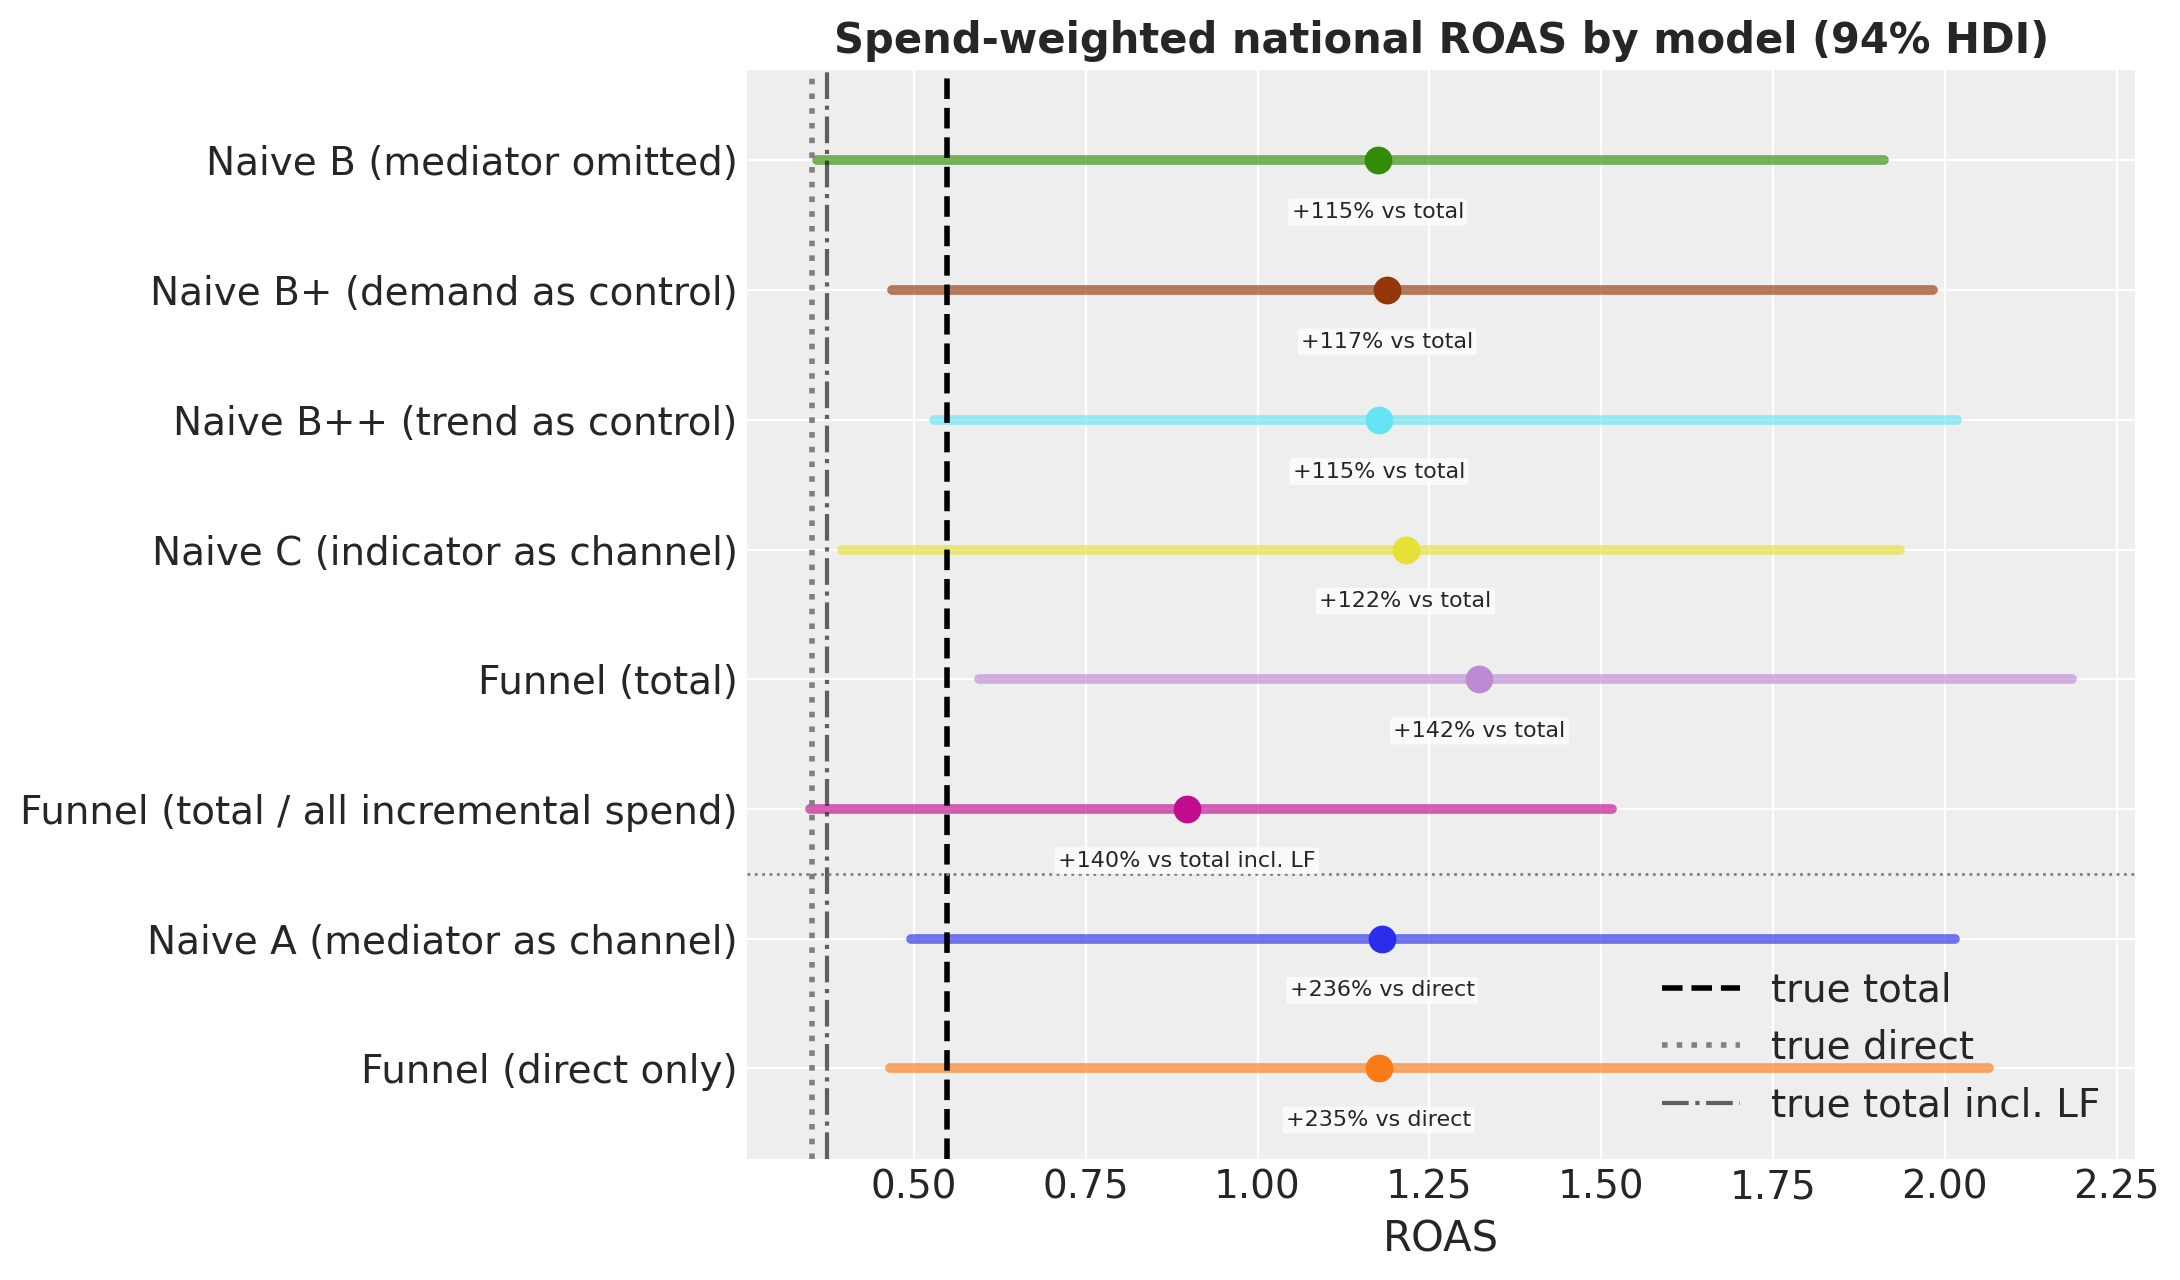

In [60]:
# National = total contribution over total spend; each row keeps its own
# denominator, so the induced-spend row is weighted by spend *plus* induced spend.
national = {
    label: (da * spend).sum("channel").sum("geo") / spend.sum()
    for label, da in roas.items()
    if label != "Funnel (total / all incremental spend)"
}
national["Funnel (total / all incremental spend)"] = (
    roas["Funnel (total / all incremental spend)"] * denom_incl
).sum(["channel", "geo"]) / denom_incl.sum(["channel", "geo"])
national = {label: national[label] for label in roas}  # restore row order

national_true_total = float((true_total_roas * spend).sum() / spend.sum())
national_true_direct = float((true_direct_roas * spend).sum() / spend.sum())
national_true_incl = float(
    (true_incl_roas * true_denom_incl).sum() / true_denom_incl.sum()
)

fig, ax = plt.subplots(figsize=(11, 6.5))
forest_panel(
    ax,
    national,
    reference={
        "total": (national_true_total, TRUE_STYLE["total"]),
        "direct": (national_true_direct, TRUE_STYLE["direct"]),
        "total incl. LF": (
            national_true_incl,
            {"color": "black", "linestyle": "-.", "linewidth": 1.5, "alpha": 0.6},
        ),
    },
    benchmarks=ROAS_BENCHMARKS,
)
# Estimand separator: total-effect rows above, direct-effect rows below.
ax.axhline(len(national) - 2.5, color="gray", linestyle=":", lw=1)
ax.set_xlabel("ROAS")
ax.legend(loc="lower right")
ax.set_title(
    "Spend-weighted national ROAS by model (94% HDI)",
    fontsize=15,
    fontweight="bold",
)
fig.set_layout_engine("tight")

The rows above the separator estimate a **total** effect. The first five are annotated against the true total (dashed black); the sixth divides the same total contribution by *all* the incremental money it took (channel spend plus the induced lower-funnel spend) and is annotated against its own benchmark (dash-dotted). The gap between the two funnel rows **is the price of the induced spend**: the return per upper-funnel dollar and the return per *incremental* dollar are different questions, and only a model that sees the funnel can answer the second one at all.

Below the separator sit the two **direct**-effect rows, annotated against the true direct ROAS (dotted grey), including `Naive A`, per the d-separation analysis: this is the question it actually answers. Neither direct row sits cleanly on the dotted line, and per cell their errors partly offset in the national average: the direct path inherits the same amplitude trade-off the recovery table found, and social in `south`, the widest seesaw cell there, is also the direct rows' largest single miss. A correct decomposition is not a magic wand against one dataset's noise; what it buys is the *right estimand* and honest uncertainty around it.

Read as a budget input: the naive models disagree with the truth in different directions, and nothing in the models themselves tells you which one you are looking at.


### Per geo and channel

The national number averages over exactly the heterogeneity a geo panel exists to expose, so it is worth breaking out. `contribution_over_spend` returns `(chain, draw, channel, geo)` -- as does the manual counterfactual feeding the induced-spend row -- so no extra computation is needed: only a different view of it.


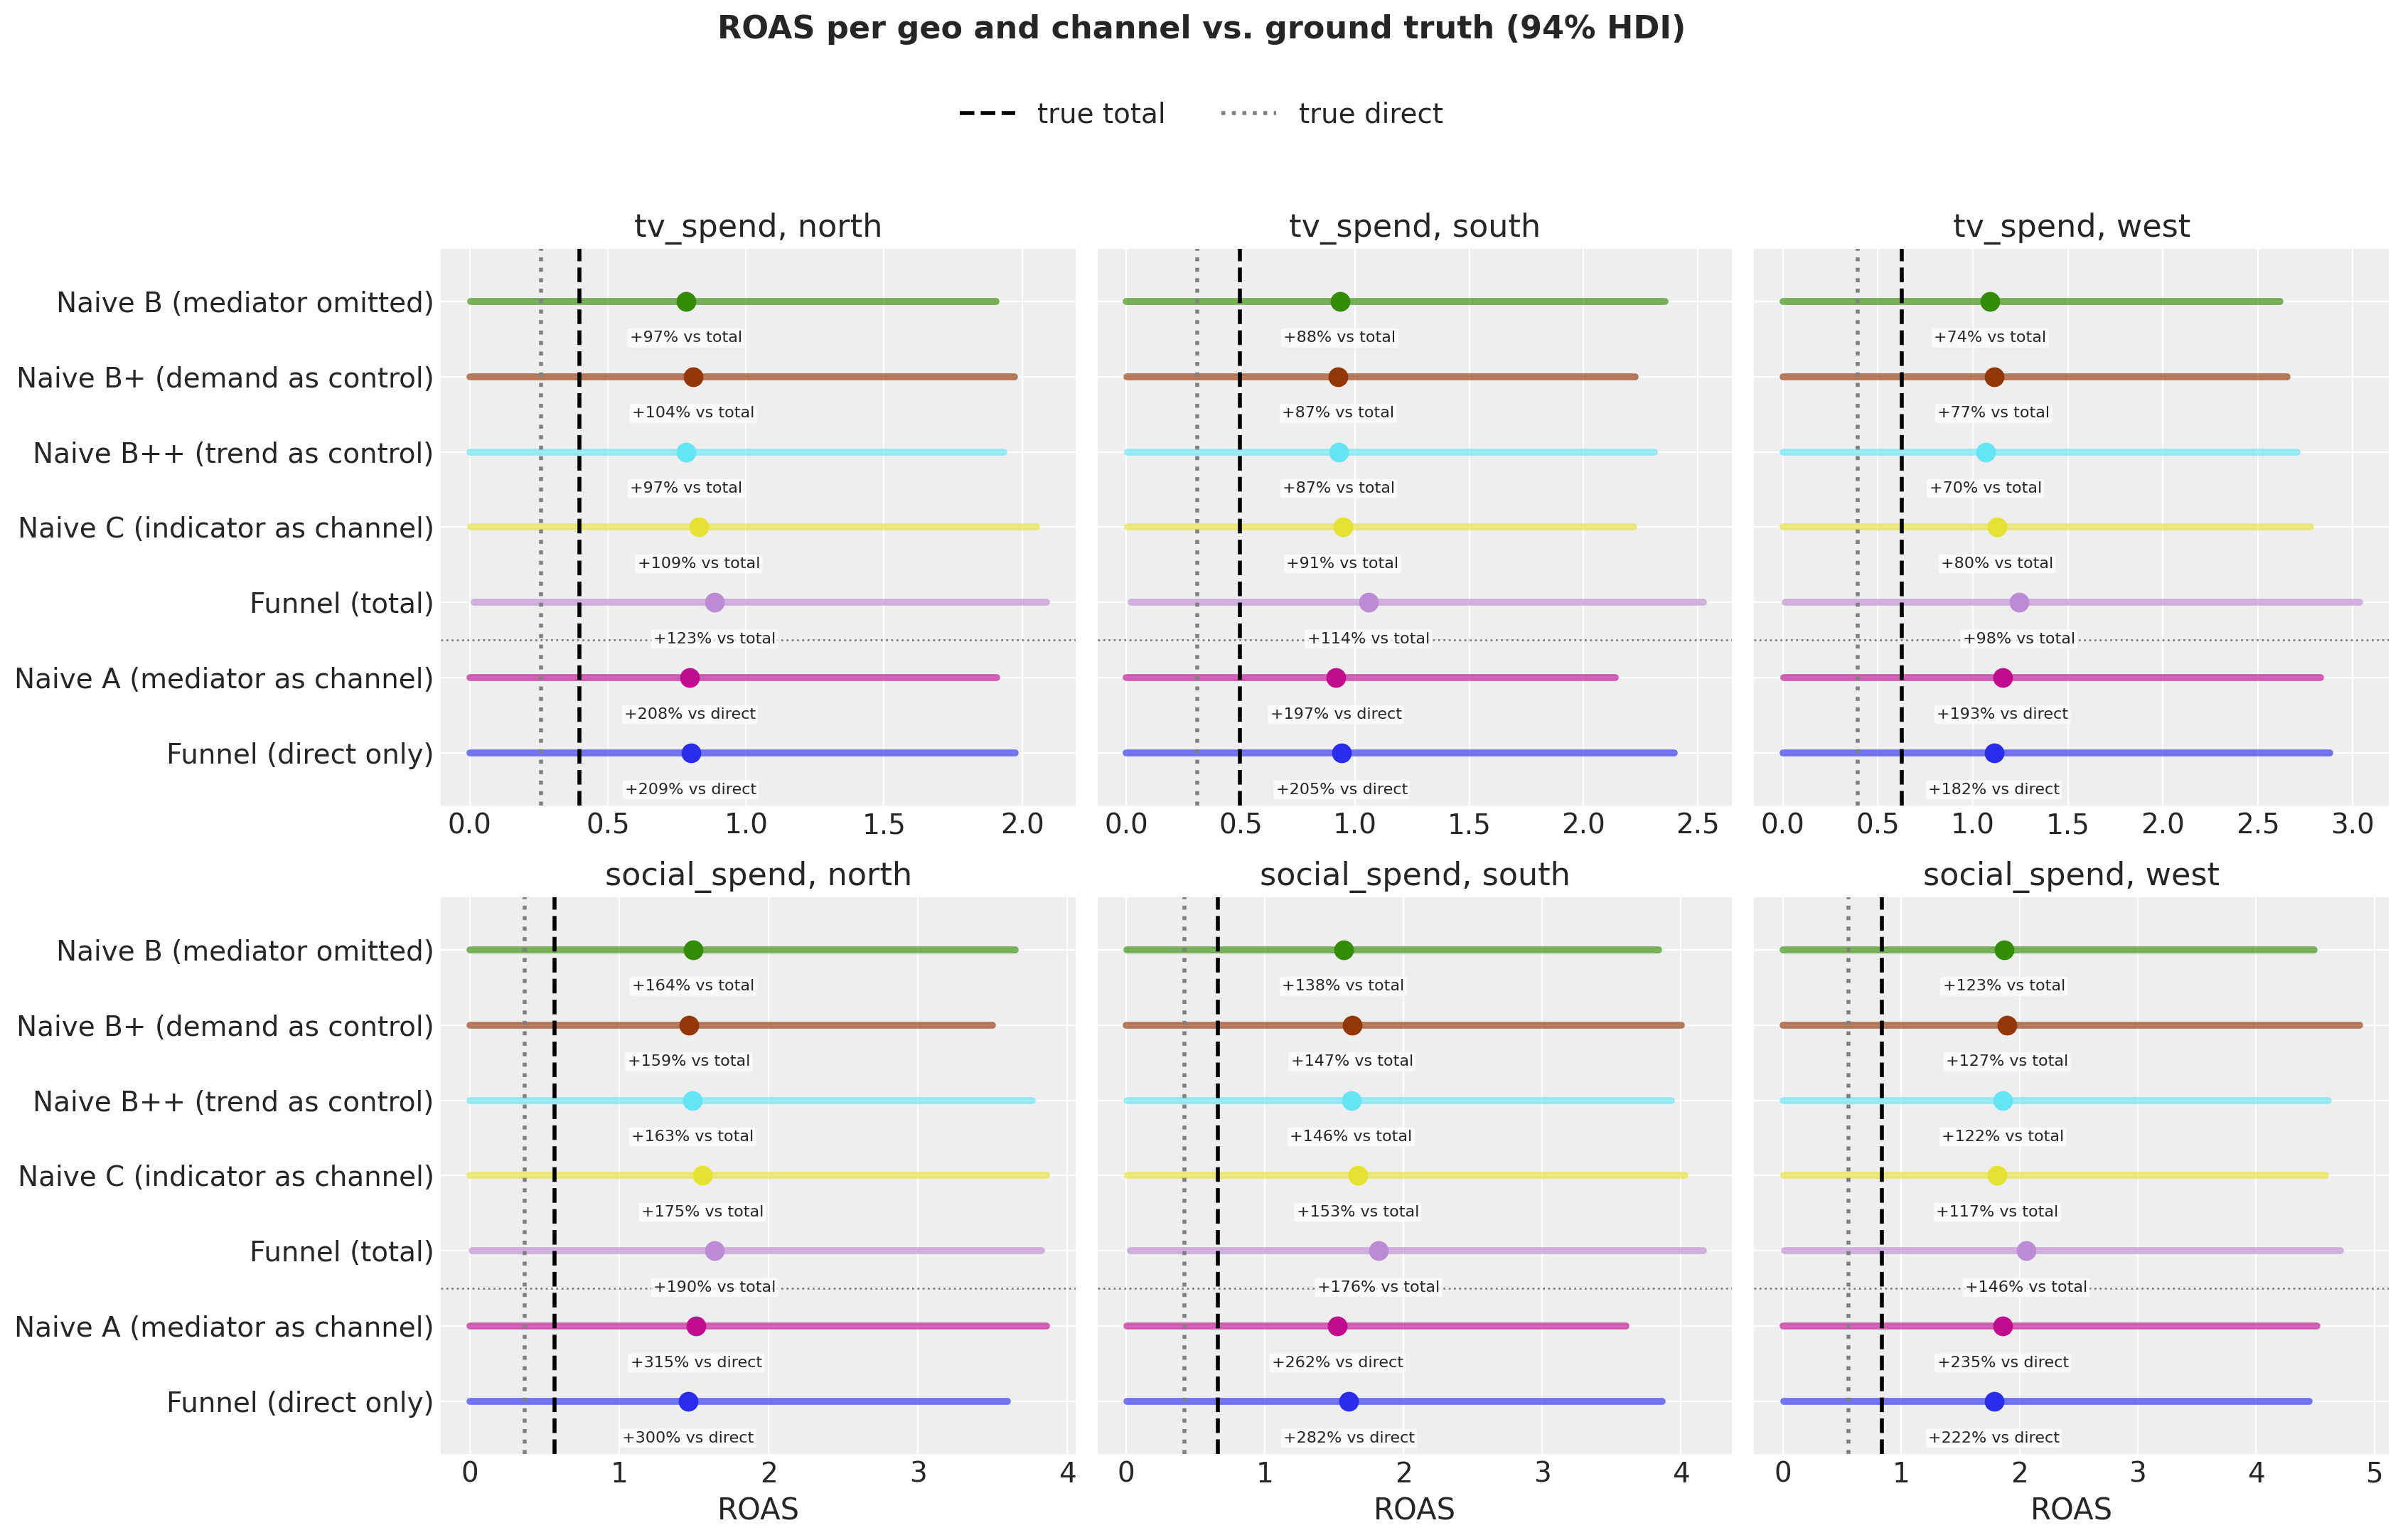

In [61]:
# The induced-spend row is national-only: per cell it would add yet another
# interval with its own benchmark line to eighteen already-busy panels.
geo_rows = {
    label: da
    for label, da in roas.items()
    if label != "Funnel (total / all incremental spend)"
}

fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(17, 11))
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        forest_panel(
            ax,
            {label: da.sel(sel) for label, da in geo_rows.items()},
            reference={
                "total": (float(true_total_roas.sel(sel)), TRUE_STYLE["total"]),
                "direct": (float(true_direct_roas.sel(sel)), TRUE_STYLE["direct"]),
            },
            benchmarks=ROAS_BENCHMARKS,
        )
        ax.axhline(len(geo_rows) - 2.5, color="gray", linestyle=":", lw=1)
        ax.set_title(f"{channel}, {geo}")
        ax.tick_params(labelleft=col == 0)
        if row == len(channels) - 1:
            ax.set_xlabel("ROAS")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=2)
fig.suptitle(
    "ROAS per geo and channel vs. ground truth (94% HDI)",
    fontsize=16,
    fontweight="bold",
)
fig.set_layout_engine("tight", rect=(0, 0, 1, 0.9))

The same comparison as a table of levels, then as bias against the true total:

In [62]:
roas_summary = pd.DataFrame(
    {
        label: da.mean(dim=["chain", "draw"]).transpose("channel", "geo").to_series()
        for label, da in roas.items()
    }
)
roas_summary["true direct"] = true_direct_roas.transpose("channel", "geo").to_series()
roas_summary["true total"] = true_total_roas.transpose("channel", "geo").to_series()
roas_summary["true total incl. LF"] = true_incl_roas.transpose(
    "channel", "geo"
).to_series()
roas_summary.style.format("{:.3f}")

The bias table judges every column against the **true total**. For five of the six that is their own estimand; `Naive A (mediator as channel)` is included on the same yardstick deliberately, because "mediator as a channel" is how it gets used in practice: its column shows the cost of *misreading* it as a total-effect estimate, and its own estimand is scored separately below.

Read `Naive A`'s summary row with one caution, though: a percentage bias divides by the estimand it is scored against, and the true direct effect is about two thirds of the true total (the indirect shares above run 33.7% to 37.7%). The same absolute error therefore prints *smaller* against the total than against the direct effect, which is most of the distance between A's mean |error| in this table and the roughly 34% it scores against its own estimand.

The absolute table below prices these errors without a denominator, and its uncancelled row reproduces this table's ordering exactly, so A's flattering rank is no denominator artifact. (On this draw the signed row happens to give that same order; what it distorts is the magnitudes, which is priced where that table is read.) The flattery lives entirely in which estimand the percentage is scored against.


In [63]:
total_estimates = [
    "Naive A (mediator as channel)",
    "Naive B (mediator omitted)",
    "Naive B+ (demand as control)",
    "Naive B++ (trend as control)",
    "Naive C (indicator as channel)",
    "Funnel (total)",
]
bias = roas_summary[total_estimates].div(roas_summary["true total"], axis=0) - 1
bias.loc[("mean |error|", ""), :] = bias.abs().mean()

# The summary row averages across both channels, while the comparison this
# notebook is organised around is per channel: one failure mechanism each.
by_channel_error = bias.loc[channels].abs().groupby(level="channel", sort=False).mean()
by_channel_error.T.style.format("{:.1%}").set_caption("Mean |error| by channel")

channel,tv_spend,social_spend
Naive A (mediator as channel),90.0%,140.5%
Naive B (mediator omitted),86.4%,141.8%
Naive B+ (demand as control),89.2%,144.3%
Naive B++ (trend as control),84.9%,144.0%
Naive C (indicator as channel),93.2%,148.5%
Funnel (total),111.6%,170.6%


In [64]:
bias.style.background_gradient(
    cmap="RdBu_r", vmin=-0.5, vmax=0.5, subset=pd.IndexSlice[channels, :]
).format("{:+.1%}")

A percentage bias is a ratio, and the two channels do not share a denominator. Before reading anything into the TV/social contrast, price the same errors in **target units**: estimated minus true *contribution*, which is what a budget conversation would actually get wrong:

In [65]:
spend_series = spend.transpose("channel", "geo").to_series()
true_contribution = (
    data["total_true"].sum("date").transpose("channel", "geo").to_series()
)

abs_bias = (
    roas_summary[total_estimates]
    .sub(roas_summary["true total"], axis=0)
    .mul(spend_series, axis=0)
)

by_channel = abs_bias.groupby(level="channel", sort=False).sum().loc[channels]
true_by_channel = (
    true_contribution.groupby(level="channel", sort=False).sum().loc[channels]
)

by_channel.T.style.format("{:+.1f}").set_caption(
    "Signed (estimated - true) contribution, summed over geos; true totals: "
    + ", ".join(f"{ch} {true_by_channel[ch]:.1f}" for ch in channels)
)

channel,tv_spend,social_spend
Naive A (mediator as channel),+146.9,+208.6
Naive B (mediator omitted),+141.8,+210.1
Naive B+ (demand as control),+146.6,+212.9
Naive B++ (trend as control),+139.7,+213.2
Naive C (indicator as channel),+153.2,+221.3
Funnel (total),+182.7,+252.2


```{note}
Summing *signed* biases over geos lets a model's cells cancel: a column that is wrong in both directions nets to something small. The uncancelled sum below (how much contribution is misstated per cell, regardless of direction) cannot be gamed by a lucky sign. In both tables, totals are summed at full precision and *then* rounded, so a total can differ from the sum of the printed cells by 0.1.
```


In [66]:
uncancelled = abs_bias.abs().groupby(level="channel", sort=False).sum().loc[channels]
uncancelled_table = uncancelled.T
uncancelled_table["both channels"] = abs_bias[total_estimates].abs().sum()
uncancelled_table.style.format("{:.1f}").set_caption(
    "Misstated contribution, summed as |bias| per cell over geos"
)

channel,tv_spend,social_spend,both channels
Naive A (mediator as channel),146.9,208.6,355.5
Naive B (mediator omitted),141.8,210.1,351.9
Naive B+ (demand as control),146.6,212.9,359.5
Naive B++ (trend as control),139.7,213.2,352.9
Naive C (indicator as channel),153.2,221.3,374.6
Funnel (total),182.7,252.2,434.9


In [67]:
abs_bias.style.background_gradient(cmap="RdBu_r", vmin=-30, vmax=30).format("{:+.1f}")

The denominators are not the story. In truth the two channels contribute almost the same amount (162 against 146: social buys less spend but converts it better), so a percentage comparison between them was close to fair already, and the absolute table repeats the percentage table's verdict without the escape hatch. `Naive B (mediator omitted)` misallocates about **half again** as much contribution onto social as onto TV (+56.5 against +38.9); `Naive B++ (trend as control)`, the model that *fixes* TV, misallocates about **nine times** as much, 72.9 against 8.5 on the uncancelled row. (Here the two readings agree for B++: its three TV cells run -3.3, -4.0 and -1.1, all the same sign, so nothing cancels.) The likelihood really does prefer social; it is not an artifact of dividing by a smaller number.

One caution about the by-channel row itself, before reading it: summing signed biases over geos lets a model's cells cancel. The funnel model is the clearest case here. Its social column nets to +2.0, close enough to zero to look like a model that gets social exactly right, while its three social cells (-6.2, +9.4 and -1.3) misstate 16.9 units between them. `Naive C`'s social column tells the same story more loudly: +32.2 signed against 54.4 uncancelled, because its cells run -11.1, +33.6 and +9.7. Neither reading changes the ranking on this draw, but the signed row understates both models, and by different amounts.

That is the same warning the coverage discussion below gives about C's flattering mean *percentage*, printed here in the one table where the cancellation actually happens. `Naive B++` is sign-consistent in every cell (TV all negative, social all positive), so its "nine times" above reads the same either way; `Naive B` has one small opposite-sign cell in social (`north`, -1.4), which is the whole gap between its +56.5 and its 59.3.

Two things follow that percentages could not show.

**A valid adjustment does not only remove bias, it moves some.** Going from `Naive B` to `Naive B+`, the set the d-separation table scores valid, takes about 14 units of contribution off TV and puts 13 of them back onto social: very nearly all of it. Going to `Naive B++`, the conditionally-valid trend control, takes 47 units off TV (overshooting the truth into a small understatement) and hands 16 to social, about a third of what it removed. Either way a large share of what the control takes off the confounded channel reappears on the unconfounded one. With the mediated pool still missing from the model, the contribution it represents has to be attributed *somewhere*; closing the backdoor changes where, not whether.


In [68]:
tilt_params = ["adstock_alpha", "saturation_lam"]
social_index = channels.index("social_spend")

tilt_cols = pd.MultiIndex.from_product([tilt_params, ["mean", "sd"]])
tilt_rows = {
    "true": [
        float(true["adstock_alpha"][social_index]),
        np.nan,
        float(true["saturation_lam"][social_index]),
        np.nan,
    ]
}
for label, model in models.items():
    posterior = model.idata.posterior
    row = []
    for param in tilt_params:
        draws = posterior[param].sel(channel="social_spend")
        row += [float(draws.mean()), float(draws.std())]
    tilt_rows[label] = row

pd.DataFrame.from_dict(tilt_rows, orient="index", columns=tilt_cols).style.format(
    "{:.3f}", na_rep=""
).set_caption("Pooled direct-path parameters on social_spend")

The mean-lag ruler below is computed from the true kernels rather than asserted. Mean-lag matching asks what single geometric `alpha` carries the same average delay as (i) the direct path alone and (ii) a curve forced to also absorb the mediated response, whose carryover is the upper-funnel adstock composed with the lower-funnel one.

```{note}
The ruler is a kernel-shape yardstick: an order-of-size prediction, not a likelihood fit. Only in the funnel model is `adstock_alpha` purely a direct-path parameter; in a naive model it measures whatever the curve was asked to absorb.
```


In [69]:
kernel_lags = np.arange(l_max)
alpha_true = float(true["adstock_alpha"][social_index])


def normalized_kernel(alpha):
    weights = alpha**kernel_lags
    return weights / weights.sum()


def kernel_mean_lag(kernel):
    return float((kernel_lags[: len(kernel)] * kernel).sum())


def alpha_with_mean_lag(target_lag):
    low, high = 0.001, 0.999
    for _ in range(60):
        mid = (low + high) / 2
        if kernel_mean_lag(normalized_kernel(mid)) < target_lag:
            low = mid
        else:
            high = mid
    return (low + high) / 2


direct_lag = kernel_mean_lag(normalized_kernel(alpha_true))
indirect_share = (
    (data["indirect_true"].mean("date") / data["total_true"].mean("date"))
    .sel(channel="social_spend")
    .to_numpy()
)
uf_kernel = normalized_kernel(float(true["adstock_hub_input_alpha"][social_index]))
mediated_lags = []
for lf_alpha in true["adstock_contribution_alpha"]:
    mediated_kernel = np.convolve(uf_kernel, normalized_kernel(lf_alpha))[:l_max]
    mediated_lags.append(kernel_mean_lag(mediated_kernel / mediated_kernel.sum()))

blend_lags = [
    (1 - s) * direct_lag + s * m
    for s, m in zip(indirect_share, mediated_lags, strict=True)
]

pd.DataFrame(
    [
        [alpha_true] * len(geos),
        [alpha_with_mean_lag(lag) for lag in blend_lags],
        [alpha_with_mean_lag(lag) for lag in mediated_lags],
    ],
    index=[
        "direct path alone",
        "blend at the true indirect share",
        "mediated path alone",
    ],
    columns=pd.Index(geos, name="geo"),
).style.format("{:.3f}").set_caption(
    "Mean-lag ruler for the carryover column (alpha equivalents; "
    "the direct row is geo-independent)"
)

geo,north,south,west
direct path alone,0.300,0.300,0.300
blend at the true indirect share,0.397,0.384,0.367
mediated path alone,0.527,0.498,0.470


**The funnel model's 16.9 is a reference point: not a floor, and not a share.** It is the smallest social error in the comparison on either reading (+2.0 signed, 16.9 uncancelled), and the signed figure flatters it for the reason the caution above gives: its three social cells run -6.2, +9.4 and -1.3. `Naive A` is next at -11.4 signed and 25.3 uncancelled, and it does not get there by being closer to right: A blocks the mediated path outright, so it nets an omitted-pool overshoot against a blocked-path undershoot. What makes 16.9 worth staring at is structure, not rank: it is what the one *correctly specified* model in the comparison still carries on this draw.

The tempting next step is to subtract it from the naive models' errors and call the remainder misallocation. The cell above is there to say why that has no license, and the reason is sharper than a caveat. Read the carryover column against the ruler printed under it. The mediated path carries its *own*, longer carryover (an upper-funnel adstock composed with a lower-funnel one), so a single channel curve forced to stand in for both paths should inherit a longer blend, and the ruler prices that pull, from 0.300 for the direct path alone, through 0.397/0.384/0.367 for a blend at the true indirect share, to 0.470-0.527 for the mediated path alone, with the caveat the cell states: a kernel-shape yardstick, an order of size rather than a fit.

```{important}
Three ruler rows span about a fifth of an alpha, and the recovery table above prints the funnel model's `adstock_alpha[social_spend]` with a 94% interval of 0.171 to 0.473: wider than the whole ruler, covering the direct row, both blend rows and the bottom of the mediated one. **No single model can be placed on a row of this ruler.** There is no "the funnel model sits at the direct row, therefore the excess above it is absorption" reading available, in either direction: the quantity a subtraction would need is the one quantity this notebook cannot measure.
```

What the ruler can still do is *order* models, which needs the gaps and not the levels. The order it prints is, end to end, the one the mechanism predicts. The funnel model represents the mediated response explicitly, so its channel curve carries the direct path only, and it is lowest at 0.318. `Naive A` blocks the mediated path by conditioning on the mediator itself and comes next at 0.342, a little above the funnel model because what it conditions on is the noisy observation $M$, and because $M^{*} = D + \lambda B$ drags the budget wedge in with it. `Naive C` blocks only *part* of the path through the demand proxy, so it retains some mediated response to absorb and sits above both at 0.387. The three that omit the mediator outright sit above all of them: `Naive B` at 0.406, `Naive B+` at 0.423 and `Naive B++` at 0.460.

That ordering is a second readout of the misallocation, in kernel shape rather than in target units, and nothing printed licenses treating the increment above the funnel model as a shared tilt waiting to be netted out, which is all the refusal of the subtraction needs. And one gap in the ordering is not absorption at all. The B-family's internal 0.406 to 0.423 to 0.460 cannot be, since all three omit the mediator identically: it tracks how much of the trend strand each specification closes, the same variance migration the adjustment section describes, and it runs in the same direction as their 56.5 to 69.5 to 72.9 in target units.

The curvature column sorts the six into exactly the same order (3.981, 4.130 and 4.336 against 4.484, 4.548 and 4.673), which is worth taking as corroboration rather than as a second measurement. Its levels are unplaceable for exactly the reason above, and the B-family is one specification plus a control column, near-forced to cluster, so part of the partition is three models being siblings.

One honesty note carries both columns: the printed sds price each model's uncertainty *about the truth*, which is the comparison that defeats placing a model on a row; they do not price the model-to-model differences, which on a single dataset are fixed numbers rather than draws from anyone's posterior. The ordering claims lean on the second, the refusal to place leans on the first, and neither borrows the other's ruler.

What survives is a caution about the ceiling rather than a bound above a floor: a model with the right structure still misstates social by 16.9 units here, so `Naive B`'s 59.3 and `Naive B++`'s 72.9 must not be read as pure misallocation, but nothing printed licenses splitting either number into a draw part and a specification part. What *is* printed cuts the other way. The coverage table below has the funnel model covering all three of its social cells, at interval widths 0.408, 0.662 and 0.726, despite errors the bias table above prices at -10.6%, +19.7% and -3.4%, so those 16.9 units are posterior-mean offsets lying entirely inside the model's own reported intervals, not a residual with a magnitude waiting to be netted out.


A point estimate being off is one thing; being *confidently* off is worse. The tables below ask, for every geo and channel, whether each model's 94% HDI actually contains the true total ROAS, and how wide those intervals had to be. One caveat before reading it: these are six *correlated* cells from a *single* simulated dataset, so treat the counts as a sanity check, not a calibration study: actual interval calibration needs replicate datasets, which is out of scope for a docs example.

In [70]:
coverage_rows = []
for c in channels:
    for g in geos:
        truth = float(true_total_roas.sel(channel=c, geo=g))
        row = {}
        for label in total_estimates:
            lo, hi = hdi_bounds(roas[label].sel(channel=c, geo=g))
            row[(label, "covers")] = bool(float(lo) <= truth <= float(hi))
            row[(label, "width")] = float(hi) - float(lo)
        coverage_rows.append(row)

coverage = pd.DataFrame(
    coverage_rows,
    index=pd.MultiIndex.from_product([channels, geos], names=["channel", "geo"]),
)
coverage.columns = pd.MultiIndex.from_tuples(coverage.columns)

pd.DataFrame(
    {
        "covers (of 6)": {
            label: int(coverage[(label, "covers")].sum()) for label in total_estimates
        },
        "mean 94% HDI width": {
            label: coverage[(label, "width")].mean() for label in total_estimates
        },
    }
).style.format({"mean 94% HDI width": "{:.3f}"}).set_caption(
    "Coverage of the true total ROAS, per model"
)

,covers (of 6),mean 94% HDI width
Naive A (mediator as channel),6,3.142
Naive B (mediator omitted),6,3.142
Naive B+ (demand as control),6,3.204
Naive B++ (trend as control),6,3.208
Naive C (indicator as channel),6,3.251
Funnel (total),6,3.374


In [71]:
# Naive A, scored against the quantity the d-separation analysis says it
# actually estimates, the true *direct* ROAS:
label = "Naive A (mediator as channel)"
a_bias = (roas_summary[label] / roas_summary["true direct"] - 1).loc[channels]
a_covers = sum(
    bool(float(lo) <= float(true_direct_roas.sel(channel=c, geo=g)) <= float(hi))
    for c in channels
    for g in geos
    for lo, hi in [hdi_bounds(roas[label].sel(channel=c, geo=g))]
)

pd.DataFrame(
    {"mean |error|": [a_bias.abs().mean()], "covers (of 6)": [a_covers]},
    index=["Naive A vs its own estimand (true direct)"],
).style.format({"mean |error|": "{:.1%}"})

,mean |error|,covers (of 6)
Naive A vs its own estimand (true direct),235.0%,6


In [72]:
coverage.style.format({(m, "width"): "{:.3f}" for m in total_estimates}).map(
    lambda v: (
        f"background-color: {'#c8e6c9' if v else '#ffcdd2'}"
        if isinstance(v, bool)
        else ""
    )
)

```{warning}
Read the two tables together, because separately each one misleads.
```

**Naive A, misread as a total-effect model, is confidently wrong where it is tightest.** Its two narrowest cells are both TV, and both are badly off: TV in `south` (width 0.240) is the one cell it fails to cover at all, understating the true total by 32.0%, and TV in `north` covers on a width of just 0.165 while understating by 20.5%. A precise answer to a question nobody asked. Scored against its *own* estimand, the direct effect, it covers 5 of 6 cells with a mean error of about 34%: a *rough* direct-effect estimator, exactly as the d-separation analysis predicted for conditioning on the noisy $M$ rather than the structural $M^{*}$.

**Naive B carries both biases at once.** Its TV cells hold the open-backdoor bias (+15.9% to +30.8%, and it loses coverage of TV in `north`), its social cells hold the omitted-mediator bias (up to +91.0% in `south`, where it also loses coverage), and its intervals (about a third wider than the funnel model's) still cover only 4 of 6: the worst coverage in the table.

**Both fixes repair exactly what the graph diagnosed as material, and nothing else.** `Naive B++` brings TV to within -7.4% and -2.5%; `Naive B+`, the specification the graph actually nominated, gets part of the way (+7.7% to +19.9%). Both restore coverage on all three TV cells, where B had lost `north`, and both go on missing social in `south`, so each covers 5 of 6 against B's 4. What separates them is how much of TV's bias each removes, which turns on functional form rather than on d-separation.

But both leave social *worse* (mean |error| 50.3% and 53.4% against B's 43.1%): the confounding they removed was real and measured (the residual-correlation table sized it) while social's backdoor, open on the graph in exactly the same way, was worth $|r| \le 0.12$ on the strands a control column can span and had nothing in it to remove. What fails there is the **response surface**: one shared saturating pool cannot be represented as a sum of per-channel curves under *any* conditioning set. Adjustment fixes the materially confounded channel; nothing in the adjustment vocabulary even addresses the mediation channel, and in target units the trade is explicit: `Naive B++` takes 47 units of contribution off TV and hands 16 of them to social.

Follow that one step further, because per channel it is sharper than it looks. On TV, the channel that carries the material backdoor, the calendar column does not merely repair the bias, it **beats the structural model**: 5.1% mean
|error| against the funnel model's 6.1%, and 8.5 target units against 9.1, both
printed above. `west` is what does it, where B++ lands about nine points closer. The funnel model's win over `Naive B++` overall (8.7% against 29.2%) is a social-side win.

That is not a dent in the thesis but its sharpest form: adjustment is the right tool for the mechanism adjustment can reach, and where it reaches it wins outright, while the funnel machinery earns its keep on the mechanism no conditioning set can touch. Measuring both fixes, watching them work where the graph said they would and fail where no graph could help, is what justifies the heavier machinery in the funnel rows.

**Naive C's mean error is the most misleading number in the table.** At 24.9% it sits third, behind the funnel model and behind `Naive A`, which is scored here on an estimand it never claimed. But C's cells range from -19.2% to +69.9% with no consistent sign, so their average understates how wrong any individual cell can be, and unlike the funnel model it offers no decomposition, no induced-spend accounting, and no warning about which cells to distrust.

**The funnel model pairs full coverage with intervals 30% narrower than the only other model that also covers all six** (0.397 against `Naive C`'s 0.571): precise *and* covering, the combination no naive specification achieves. Read that width gap with the caveat stated when the models were introduced: the funnel model also *sees* two likelihood series the others do not, and those series sharpen the shared upper-funnel parameters directly, so part of that 30% is information rather than structure. It also posts the smallest mean error by a clear margin: 8.7%, against 18.7% for `Naive A`, which is scored here on an estimand it never claimed, and 24.9% for the best of the genuine total-effect rivals.

It is not uniformly best cell by cell: its weakest cells are `social_spend` in `south` (+19.7%) and `north` (-10.6%) and `tv_spend` in `west` (+11.8%). Two of those the recovery table anticipated: social in `south` is where the direct/mediated amplitude seesaw was widest (-1.6% on the demand path against +45.3% on the direct one), and `west` runs the worst signal-to-noise in the panel (flat `y_sigma` against the smallest `geo_size`). *Within TV*, the widest interval sits on exactly the worst cell (`west`, 0.247), the model telling you it knows less there, which is the correct response. Within social it does not line up: `west` gets the widest interval of all (0.726) and is its *best* social cell, while `north`, its second-worst, gets the narrowest (0.408). Across channels the width ordering is about the channel rather than the accuracy: every social interval is wider than every TV interval, whatever the error in the cell.


### The bias barely shows up in predictive fit

Here is the punchline, and it survives the move to a geo panel, with one refinement the table itself supplies. The six models span less than a point of in-sample $R^2$ while their ROAS conclusions differ by tens of percent.

But look at the *structure* of the spread. The four mediator-blind models are statistically identical (0.9791-0.9802, a spread of 0.0011): conditioning on $C$ or $t$ buys essentially nothing in fit, even though one of those controls demonstrably repairs TV's estimate. (This is a *fit* grouping, and it cuts differently from the parameter grouping earlier: by likelihood `Naive C` sits with the mediator-blind four, while its carryover ranks below every one of them, on the mediator-aware side of the ordering: predicting the target and absorbing the mediated response are different questions.) The two models that observe the mediator sit a small but clear step higher (0.9861 and 0.9872).

So fit does carry some information: it can tell you the mediator predicts the target. What it cannot do is separate `Naive A` from the funnel model, 0.0011 apart in $R^2$ and tens of percent apart in what they say TV is worth, because fit rewards the mediator's predictive content and is indifferent to the causal story wrapped around it. Two honesty notes: this is in-sample $R^2$, and the funnel model carries two extra likelihood terms, so it is not a like-for-like model-selection comparison in any case, which is itself part of the point.


In [73]:
r2 = {}
for label, model in models.items():
    pp = (
        model.idata.posterior_predictive["y"]
        * model.idata.constant_data["target_scale"]
    )
    y_hat = pp.mean(dim=["chain", "draw"])
    y_true, y_hat = xr.align(data["y"], y_hat, join="exact")
    ss_res = float(((y_true - y_hat) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    r2[label] = 1 - ss_res / ss_tot

pd.Series(r2, name="in-sample $R^2$").to_frame().style.format("{:.4f}")

,in-sample $R^2$
Naive A,-22.3510
Naive B,-2.8080
Naive B+,-3.7072
Naive B++,-2.7340
Naive C,-25.0271
Funnel,-24.2582


### What the built-in decomposition shows, and what it cannot

Almost everything causal in this notebook was post-processing -- the exception is the incrementality module which, once the effect opted in, ran the per-channel spend counterfactual for us. It is worth seeing what the library's own decomposition reports for the same fitted model, because the gap is the entire point.

`decomposition.contributions_over_time` and `decomposition.waterfall` recognise a fixed set of components: channels, baseline, controls, seasonality. A custom `MuEffect` is none of those. (That is a property of the data-layer decomposition the plot suite reads (`mmm.summary.contributions` reads the same one, and does not accept a custom component; its signature admits only the fixed set), not of the library: the counterfactual decomposition on `MMM` *does* include a registered effect as its own part; the caveats at the end say why that does not settle the attribution either.)


/Users/benjamv/.cursor/worktrees/pymc-marketing/zg8m/pymc_marketing/mmm/plotting/decomposition.py:402: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


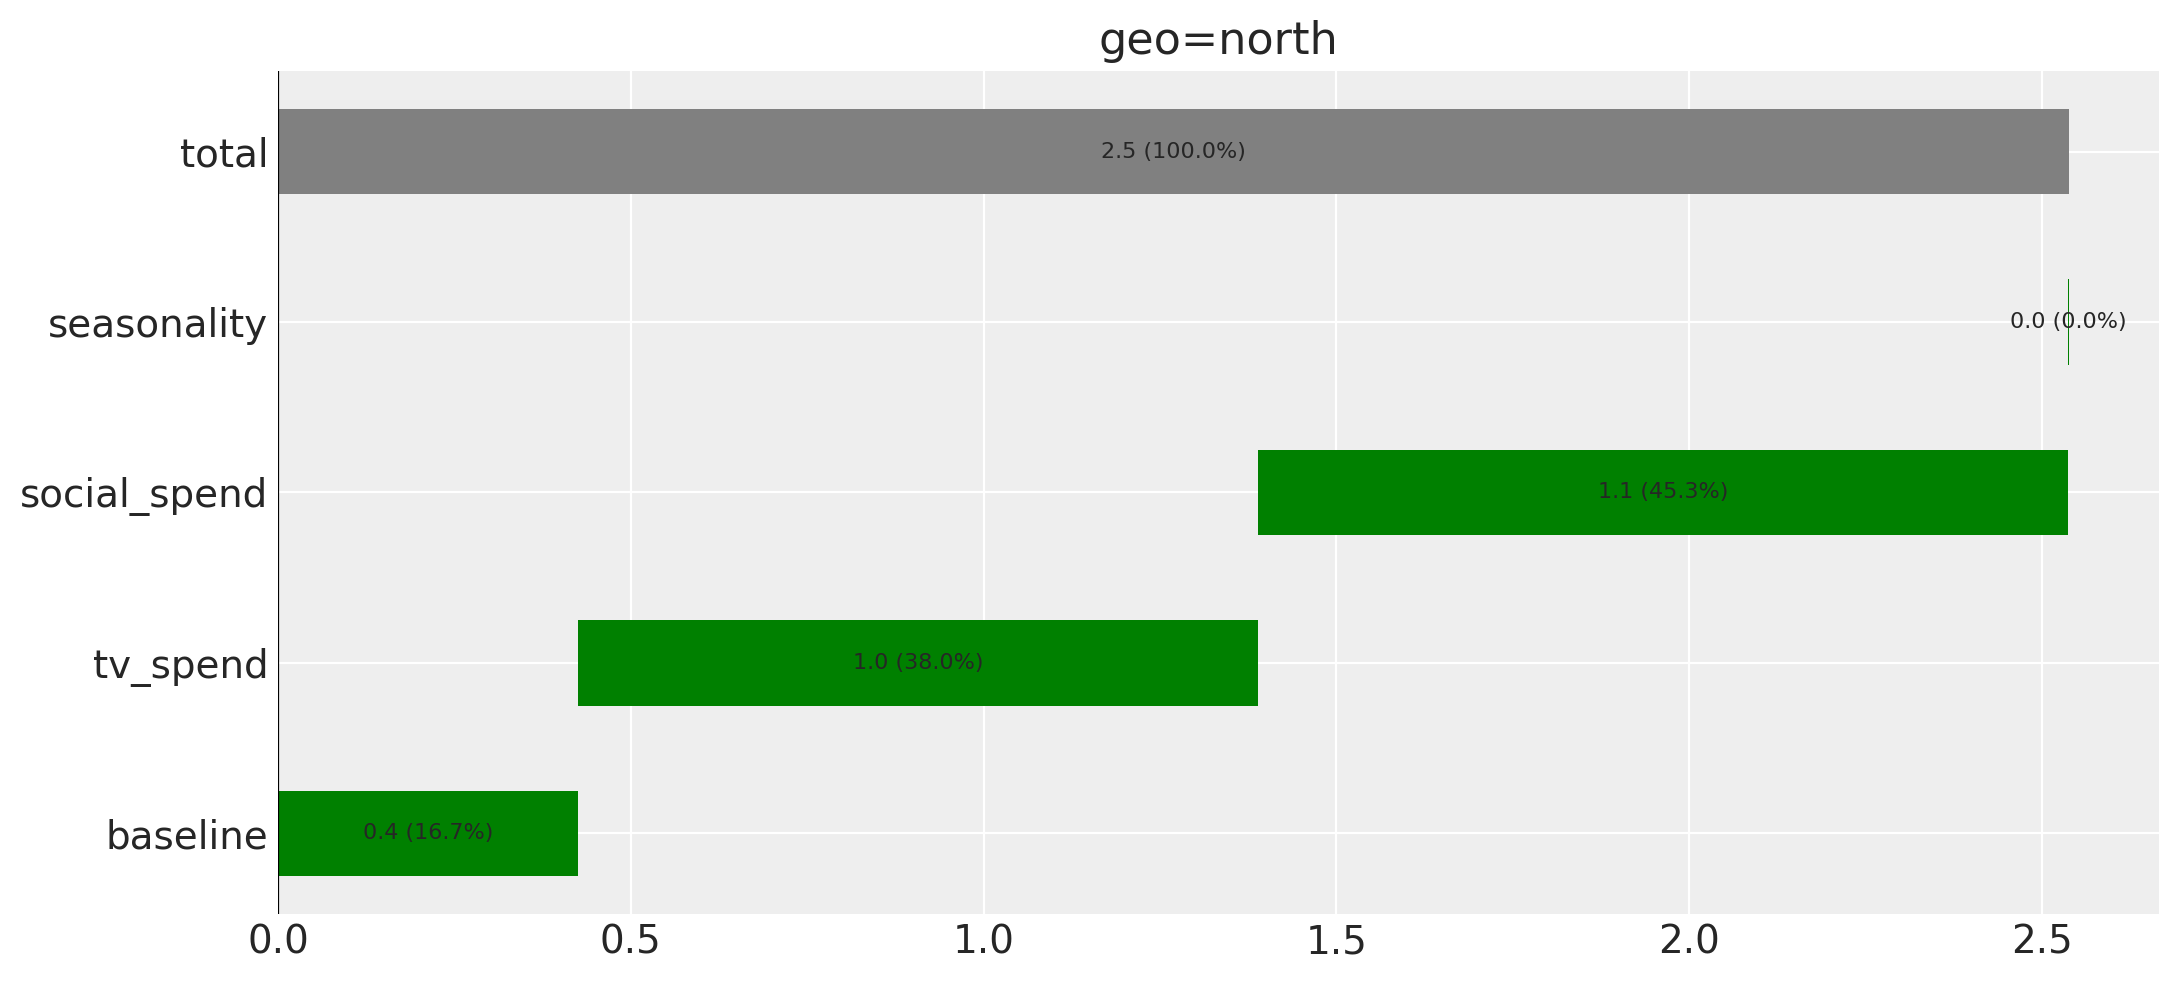

In [74]:
funnel.plot.decomposition.waterfall(dims={"geo": ["north"]}, figsize=(11, 5));

The `channels` bars are the **direct** paths only, and the mediated contribution is not redistributed into the baseline either: it is simply absent. The bars do not add up to the target:

In [75]:
scale = funnel.idata.constant_data["target_scale"]
post = funnel.idata.posterior
components = {
    "intercept": post["intercept_contribution"] * scale,
    "channels (direct)": post["channel_contribution_original_scale"].sum("channel"),
    "seasonality": post["yearly_seasonality_contribution"] * scale,
}
# Bars are rounded for display and summed after rounding, so the printed column
# adds up exactly.
bars = {
    name: round(float(da.sel(geo="north").mean()), 3) for name, da in components.items()
}
mediated = float(
    post["budget_dual_effect_contribution_original_scale"].sel(geo="north").mean()
)

two_dp_rows = ["mediated, missing from the bars", "observed target mean"]
waterfall_summary = pd.DataFrame(
    {
        "value": [
            *bars.values(),
            sum(bars.values()),
            mediated,
            float(data["y"].sel(geo="north").mean()),
        ]
    },
    index=[*bars, "sum of the waterfall bars", *two_dp_rows],
)
waterfall_summary.style.format("{:.3f}").format(
    "{:.2f}", subset=pd.IndexSlice[two_dp_rows, :]
).set_caption("Waterfall completion (geo=north, original scale)")

,value
intercept,0.425
channels (direct),2.113
seasonality,0.001
sum of the waterfall bars,2.539
"mediated, missing from the bars",1.39
observed target mean,1.74


How much of that mediated term is the channels' due? The two tables below come from the *generative model* (north only, like every number above), so they are like-for-like with each other, and not with the posterior figure above.

In [76]:
north = geos.index("north")

pd.DataFrame(
    {
        "target units": [
            float(indirect_raw[:, north].mean()),
            float(indirect_both[:, north].mean()),
        ]
    },
    index=["true mediated term (north)", "of which the channels created"],
).style.format("{:.2f}")

,target units
true mediated term (north),0.79
of which the channels created,0.40


In [77]:
mstar_parts = {
    "demand baseline": float(true["budget_dual_baseline"][north]),
    "category demand (gamma C)": float(
        true["budget_dual_parent_coef"][north] * category_demand[:, north].mean()
    ),
    "lf budget (lambda B)": float(
        true["budget_dual_budget_coef"][north] * lf_budget[:, north].mean()
    ),
}
mstar_mean = float(data["lf_spend_true"].sel(geo="north").mean())
mstar_parts["demand the channels created"] = mstar_mean - sum(mstar_parts.values())

pd.DataFrame(
    {
        "value (demand units)": list(mstar_parts.values()),
        "share of M*": [v / mstar_mean for v in mstar_parts.values()],
    },
    index=list(mstar_parts),
).style.format({"value (demand units)": "{:.3f}", "share of M*": "{:.1%}"}).set_caption(
    "Mean structural lower-funnel spend M* (north)"
)

,value (demand units),share of M*
demand baseline,0.200,14.9%
category demand (gamma C),0.171,12.7%
lf budget (lambda B),0.164,12.2%
demand the channels created,0.811,60.2%


More than a third of the target is unaccounted for. Be precise about whose it is: the missing 0.61 is the *entire* mediated term, and lower-funnel spend is built from **four** things: the demand baseline, the category-demand contribution $\gamma C$, the exogenous lower-funnel budget $\lambda B$, and the demand the channels created. Only the last is media's due.

Compare like with like when sizing it. The 0.61 is a **posterior** quantity, while the two figures in the mediated-term table are **generative truth**: on the true model the channels created 0.40 per week in `north` out of a mediated term of 0.79 (about half), and the demand baseline, the category index and the budget term split the rest. And the $M^{*}$ percentages above are a third currency: they are shares of **demand units**, and the conversion from demand to target is concave, so the channels' 60.2% of $M^{*}$ is not their share of the missing 0.61. The joint indirect effect is.

A reader taking these bars as an attribution would therefore be wrong twice over: under-crediting both channels by their mediated contributions, and dropping the demand baseline, the category index and the budget term altogether, which between them are the rest of the missing mass.

This is a boundary to know rather than a bug to route around: the DAG lives in your `create_effect` code, and only you can tell the library that a particular additive term means "demand this channel created". Nearly everything causal in this notebook came from post-processing the posterior; the one built-in that follows the funnel -- the incrementality module, via the effect's opt-in -- answers the per-channel *spend* counterfactual, not this attribution question.


## Caveats and extensions

- **The framework does not "see" the DAG.** The funnel structure lives in the `BudgetDualIndicatorEffect` code, and no built-in decomposition knows what is upstream of what. (The incrementality module is the partial exception: an effect that opts in via `incrementality_spec` has its mediated response included in the per-channel spend counterfactual -- but even it does not split the mediated mass among its four sources, which is the attribution at issue here.) The consequences differ by tool, and the second is the sharper trap: the *data-layer* decomposition (`MMMIDataWrapper.get_contributions`, which the plot suite and `mmm.summary.contributions` both read) recognises a fixed set of components and, under this model's identity link, omits a custom `MuEffect` entirely, as the waterfall above shows (under `link="log"` the conserving decomposition folds the effect into the baseline instead: absorbed rather than dropped, and still not its own part), while the *counterfactual* decomposition (`MMM.compute_counterfactual_contributions_dataset`) includes each registered effect as its own labelled part via `contribution_var_name`: a rescaled read of `budget_dual_effect_contribution`, while the `M*` accounting above reads the separately registered `budget_dual_effect_contribution_original_scale`: numerically identical under this identity link, but two different posterior variables. That hands you the whole mediated mass as one `budget_dual_effect` bar, not the channels' causal due. Splitting the bar is the post-processing done above, and anything causal has to come from there.
- **Pass a `Dataset`, not a `DataFrame`.** Extra columns in a DataFrame are dropped during conversion, so a `DataVarMuEffect` would not find its variables. Build the model from an `xarray.Dataset`; `fit` still takes the long frame for its bookkeeping, which is also why `fit_data` carries no funnel columns, and why a `save` / `build_from_idata` round-trip would not reconstruct this model.
- **Pooling choices are identification choices.** We pooled carryover and curvature across geos and left amplitudes free. Freeing everything per geo with ~130 weeks each will widen the posteriors considerably and can introduce divergences; hierarchical (partially pooled) priors are the natural next step.
- **Latent variables need an anchor.** Fixing at one the coefficient on $D$ in the lower-funnel spend equation is what gives $D$ a scale: latent demand is expressed in units of the spend it induces. Leave that coefficient free as well as $\kappa$ and the model is unidentified. Which relationship you anchor to is a substantive choice, because it decides what "one unit of demand" means.
- **The two exclusion restrictions are not equally load-bearing.** The budget's ($B$ enters the spend equation but not the search equation) is genuinely identifying: it is what separates $\lambda B$ from $D$, it has a testable implication ($B \perp S$ on the raw data, which we verified both on the graph and empirically), and dropping it, or giving the budget no independent variation, merges $\lambda$ into the demand baseline. Category demand's ($C$ absent from the target equation) is a modelling convenience: $C$ is observed, so a $C \to Y$ path could be absorbed by adding it as a control column, exactly as `Naive B+` does.
- **Only one downstream variable is a cause.** Lower-funnel spend belongs in the target equation; branded search does not. Getting that backwards is not a modelling nicety, it is the difference between `Naive C` and the funnel model.
- **Graph verdicts are conditional on the graph, including the parts you almost did not draw.** The d-separation table split the market driver into three strands: a seasonal basis, a growth trend, and the drivers' shared noise. Only the first two are observed. That third strand is easy to leave out of a drawing (it came from one `LKJCholeskyCov` line in the DGP), and leaving it out certifies `Naive B++` as a valid total-effect estimator, which on the full graph it is not: a trend control blocks the fork it names and nothing else. A reader who believed the Fourier basis captured the *entire* driver would have gone further and scored `Naive B` as valid. On real data the analogous question (what is the market driver, which strands of it do your regressors span, and what is left over) cannot be checked against a known truth, and a genuinely latent residue (taste shifts, competitor activity) puts even the trend fix out of reach. Controlling for a *measured* demand index helps exactly as far as the problem is confounding: here it repaired the trend-confounded channel and did nothing for the bias that was never materially confounded. Making the index part of a correctly specified structural equation, as the funnel model does, is what addresses the rest. The same caution applies to the drawing's *shape*: it collapses time, so every verdict above is a statement about one time slice of a system whose adstocks are lagged. That reading is right for an MMM, whose control columns condition on whole series, but a confounder that acted only with a lag would need a graph that shows time.
- **The funnel model is handed the true functional form.** In this synthetic exercise the funnel model *is* the DGP: right response families, right pooling structure, right anchoring, right exclusion restrictions. That is the strongest possible version of the comparison, and it is also the point: the notebook's thesis is that structure, not adjustment, is what separates the specifications, so the model given the correct structure should win, and by how much is worth knowing. On real data nobody hands you the functional form; the parameter-recovery and proxy-predictive checks above are the tools for arguing your structural equations are close enough, and misspecifying them would erode the funnel model's advantage exactly where the naive models lose theirs.
- **The funnel model's advantage mixes structure with information.** It observes two likelihood series and two inputs the naive models never see, so its narrower intervals are not attributable to structure alone. The clean way to separate the two is a specification that *sees* the extra series without *modelling* the system (`Naive B++` with `lower_spend` and `search_volume` added as control columns), which we leave as an exercise; note that conditioning on either one is conditioning on a descendant of the treatment, so it answers a different causal question, which is rather the point.
- **Distinguish a mediator from an organic path.** We route the entire mediated effect through lower-funnel spend. A model with *both* $M^{*} \to Y$ and a direct organic $D \to Y$ is more realistic still, but the two differ only by $\lambda B$ and would be weakly separated at this sample size: a good reason to add such a path only with data (or priors) that can support it.
- **Per-channel indirect effects are not additive.** With a shared saturating mediator, leave-one-out attribution understates the joint effect, here by about 13%. Report the convention alongside the number; [Mediation Analysis and (In)Direct Effects with PyMC](https://juanitorduz.github.io/mediation/) works through the general decomposition, where the pieces that leave-one-out drops appear as explicit interaction and dependence terms.
- **Mind the scales.** The base `MMM` scales its channel and target data, but a `DataVarMuEffect` reads its variables **unscaled**. Here the data is generated in-model at roughly unit scale, so the `HalfNormal(1)` priors in the demand equation are sensible. On real data, scale those inputs (or the priors) yourself.
- **Budget optimization.** Funnel-aware optimization is out of scope, but not for the reason one might guess: `BudgetOptimizer` replaces `channel_data` with `do(...)`, a graph-level intervention that *does* propagate into **this** effect's subgraph, because `create_effect` reads `mmm.channel_data_scaled`, which is downstream of the intervened node. An effect that read only its own `pm.Data` variables would be untouched by it, which is the other half of this bullet seen from the other side. What stops it here is the objective and the shapes. The default `response_variable="total_media_contribution_original_scale"` is built from `channel_contribution` alone, so the mediated term is not in the function being maximised; and the effect's own date-length `pm.Data` variables are not resized to the optimizer's `num_periods + l_max` window: not because the hook is missing (the optimizer calls each effect's `set_data`) but because its zero dataset carries only channel, control and target variables, so a `DataVarMuEffect` finds none of its own and silently no-ops. Both would have to be addressed for the optimizer to price the funnel.

Natural extensions: hierarchical priors across geos, **censored** lower-funnel spend for budget-capped channels, more than one latent demand pool (for example separate branded and non-branded demand), and time-varying mediator baselines.


## References

The Nürnberger Versicherung case-study series from PyMC Labs, which works through the same funnel problem in a production setting:

- [Cracking the Funnel: How Nürnberger Quantified Cross-Channel Synergies](https://www.pymc-labs.com/blog-posts/funnel-aware-mmm) (Part I)
- [Building a Funnel-Aware Bayesian Marketing Mix Model](https://www.pymc-labs.com/blog-posts/full-funnel-mmm-optimization) (Part II)
- [A PyMC-Marketing Case Study: Campaign Dynamics, Influencer Effectiveness, and Time-Slice CV](https://www.pymc-labs.com/blog-posts/extending-funnel-aware-bayesian-marketing-mix-model) (Part III)

On the graphical machinery used in **What the graph already says**:

- Pearl, J., Glymour, M., and Jewell, N. P. (2016). [*Causal Inference in Statistics: A Primer*](http://bayes.cs.ucla.edu/PRIMER/). Wiley. Chapters 2 and 3 cover d-separation and the backdoor criterion.
- Pearl, J., and Mackenzie, D. (2018). *The Book of Why: The New Science of Cause and Effect*. Basic Books.


In [78]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 18 Aug 2026

Python implementation: CPython
Python version       : 3.12.10
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
networkx      : 3.6.1
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

